<a href="https://colab.research.google.com/github/IS-Group17/Project-Fraud/blob/main/Dataset3_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP 3608 Project Notebook  


**Problem Statement**

Fraudulent financial transactions are a major issue in modern financial systems, but detecting them is difficult since fraud cases are rare and often hidden within large amounts of legitimate data. In this project, the goal is to build machine learning models that can accurately identify fraudulent transactions across multiple datasets, specifically credit card fraud and online payment fraud. Three models—Logistic Regression, Random Forest, and XGBoost—will be implemented and compared to evaluate their effectiveness in identifying fraudulent activity.

**Objectives**

- Detect fraudulent transactions using machine learning models
- Compare performance across three datasets
- Evaluate models using metrics such as precision, recall, F1-score, and ROC-AUC
- Analyze tradeoffs between different approaches
- Identify common patterns and trends in fraudulent transactions across all datasets


### Project goal
The goal is to compare how three machine learning approaches behave on three datasets, and explain the strengths, weaknesses, and tradeoffs of each method.

For each dataset, the target variable has two classes:

- non-fraud
- fraud

### Algorithms selected
- Logistic Regression

- Random Forest

- XGBoost

### Why these three?
Together they create a meaningful comparison:

- Simple linear model
- Bagging-based tree ensemble
- Boosting-based tree ensemble

### Datasets used
This notebook uses three fraud-related datasets supplied for the project:

1. `creditcard.csv`: https://www.kaggle.com/datasets/jainilcoder/online-payment-fraud-detection?resource=downloaddata
2. `onlinefraud.csv`: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data
3. `Base.csv`: https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022/data?select=Base.csv


These three datasets represent different fraud settings and feature structures, which helps test whether the models behave consistently or differently depending on the data.

#Bank Account Application Fraud Detection:

Detecting fraud at the bank account application stage is fundamentally different from detecting fraudulent transactions. By the time a transaction occurs, an account has already been opened and damage may already be done. This notebook focuses on catching fraud earlier — at the point of application — by analysing behavioural, demographic, identity, and device-related signals that distinguish fraudulent applicants from legitimate ones.


The dataset used is the NeurIPS 2022 Bank Account Fraud dataset, containing one million applications across 32 features with a severe class imbalance of 89.67:1. A model that blindly predicts every application as legitimate would achieve 98.9% accuracy while catching zero fraud cases, which illustrates why accuracy is not a useful metric here and why the entire analysis is built around recall, precision, F-scores, PR-AUC, and a cost-sensitive decision framework.


The notebook is organised around two core ideas. The first is that good fraud detection requires deep understanding of the data before any model is trained — this means thorough data quality checks, univariate and bivariate exploration, multivariate interaction analysis, and outlier examination to understand where fraud concentrates and what patterns distinguish it from legitimate behaviour. The second is that model training and threshold selection are two separate optimisation problems. Training teaches the model to assign fraud probabilities; threshold selection determines where to draw the line between a fraud flag and a legitimate pass. Both steps matter equally, and choosing the wrong threshold can make an otherwise strong model operationally useless.


Three models are trained and compared — Logistic Regression, Random Forest, and XGBoost — across multiple imbalance handling strategies. The best configurations are carried forward into hyperparameter tuning and recall-focused refinement before a final threshold is selected by minimising a business cost function defined as the weighted sum of false negatives and false positives, where a missed fraud case is penalised 25 times more heavily than a false alarm. Feature importance analysis is conducted throughout to identify which applicant signals contribute most to fraud detection performance.


## Optimization Function

Each application has a target label:

$$y = \begin{cases} 1 & \text{fraudulent application} \\ 0 & \text{legitimate application} \end{cases}$$

The supervised learning task is binary classification:

$$f(x) \rightarrow P(y=1 \mid x)$$

The classifier outputs a fraud probability. However, a business system still needs a final decision:

$$\hat{y} = \begin{cases} 1 & P(y=1 \mid x) \geq t \\ 0 & P(y=1 \mid x) < t \end{cases}$$

where $t$ is the decision threshold. The optimisation problem in this notebook is not just "train a model". The explicit optimisation problem is:

$$t^* = \arg\min_{t \in [0,1]} \left[ FP(t) + Z \cdot FN(t) \right]$$

subject to:

$$FPR(t) \leq \alpha$$

where:

- $FP(t)$ = false positives at threshold $t$
- $FN(t)$ = false negatives at threshold $t$
- $Z$ = how many times worse a missed fraud application is than a false alarm
- $\alpha$ = maximum acceptable false positive rate

In this notebook, $Z = 25$, derived from a fixed cost assumption of **500 per missed fraud application** and **20 per false positive**. Since the dataset does not contain direct financial loss figures, these values are manually set to reflect the asymmetric real-world consequences of application fraud — a fraudulent account that is approved can result in significant downstream financial loss, while a false alarm results in an unnecessary manual review. This is a constrained, cost-sensitive threshold optimisation problem.

## Imports

In [1]:
import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

warnings.filterwarnings("ignore")


from xgboost import XGBClassifier


## Load datasets

## Set target column

In [2]:


DATASETS = {
    "Credit Card Fraud": {
        "path": "creditcard.csv",
        "target": "Class"
    },
    "Online Payment Fraud": {
        "path": "onlinefraud.csv",
        "target": "isFraud"
    },
    "Bank Account Application Fraud": {
        "path": "Base.csv",
        "target": "fraud_bool"
    }
}
for dataset_name, info in DATASETS.items():
    print(dataset_name, "->", os.path.exists(info["path"]))

for dataset_name, info in DATASETS.items():
    print(dataset_name, "->", info["path"], "| target =", info["target"])

Credit Card Fraud -> False
Online Payment Fraud -> False
Bank Account Application Fraud -> True
Credit Card Fraud -> creditcard.csv | target = Class
Online Payment Fraud -> onlinefraud.csv | target = isFraud
Bank Account Application Fraud -> Base.csv | target = fraud_bool


## Helper Functions

In [3]:
def load_dataset(path):
    df = pd.read_csv(path)
    return df


def basic_overview(df, dataset_name, target_col):
    print("Dataset:", dataset_name)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(list(df.columns))
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nMissing values per column:")
    display(df.isnull().sum().sort_values(ascending=False).head(15))
    print("\nTarget distribution (counts):")
    display(df[target_col].value_counts(dropna=False))
    print("\nTarget distribution (%):")
    display((df[target_col].value_counts(normalize=True) * 100).round(4))

In [4]:
def plot_class_distribution(df, target_col, dataset_name):
    counts = df[target_col].value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar")
    plt.title(f"{dataset_name} - Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

In [5]:
def get_feature_lists(df, target_col):
    X = df.drop(columns=[target_col])
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
    return numeric_cols, categorical_cols

In [6]:
def plot_top_numeric_correlations(df, target_col, dataset_name, top_n=10):
    numeric_df = df.select_dtypes(include=["number"]).copy()
    if target_col not in numeric_df.columns:
        print("Target is not numeric, correlation plot skipped.")
        return

    corr = numeric_df.corr(numeric_only=True)[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)
    top_corr = corr.head(top_n)

    if len(top_corr) == 0:
        print("No numeric features available for correlation plot.")
        return

    plt.figure(figsize=(8, 5))
    top_corr.sort_values().plot(kind="barh")
    plt.title(f"{dataset_name} - Top Numeric Features by Correlation with {target_col}")
    plt.xlabel("Correlation")
    plt.ylabel("Feature")
    plt.show()

    display(top_corr.to_frame("correlation_with_target"))

In [7]:
def plot_top_skewed_features(df, target_col, dataset_name, top_n=8):
    numeric_df = df.select_dtypes(include=["number"]).drop(columns=[target_col], errors="ignore")
    if numeric_df.shape[1] == 0:
        print("No numeric features available for skew analysis.")
        return

    skewness = numeric_df.skew(numeric_only=True).sort_values(key=np.abs, ascending=False)
    top_skew = skewness.head(top_n)

    plt.figure(figsize=(8, 5))
    top_skew.sort_values().plot(kind="barh")
    plt.title(f"{dataset_name} - Most Skewed Numeric Features")
    plt.xlabel("Skewness")
    plt.ylabel("Feature")
    plt.show()

    display(top_skew.to_frame("skewness"))

In [8]:
def plot_numeric_feature_by_class(df, target_col, dataset_name, feature_name):
    if feature_name not in df.columns:
        print("Feature not found:", feature_name)
        return

    clean_df = df[[feature_name, target_col]].dropna().copy()
    classes = sorted(clean_df[target_col].unique())

    plt.figure(figsize=(8, 4))
    for class_value in classes:
        series = clean_df.loc[clean_df[target_col] == class_value, feature_name]
        plt.hist(series, bins=40, alpha=0.5, label=f"class={class_value}")
    plt.title(f"{dataset_name} - Distribution of {feature_name} by Class")
    plt.xlabel(feature_name)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [9]:
def show_top_categorical_fraud_rates(df, target_col, dataset_name, top_n=10):
    categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

    if len(categorical_cols) == 0:
        print("No categorical features available.")
        return

    for col in categorical_cols[:5]:
        print(f"\n{dataset_name} - Fraud rate by {col}")
        temp = df.groupby(col)[target_col].mean().sort_values(ascending=False).head(top_n)
        display(temp.to_frame("fraud_rate"))
        plt.figure(figsize=(8, 4))
        temp.sort_values().plot(kind="barh")
        plt.title(f"{dataset_name} - Top Fraud Rates by {col}")
        plt.xlabel("Fraud rate")
        plt.ylabel(col)
        plt.show()

In [10]:
def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    X_processed = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    return X_processed, numeric_cols, categorical_cols

In [11]:
def preprocess_for_model(df, target_col):
    df = df.copy()

    X = df.drop(columns=[target_col])
    y = df[target_col]

    # log transform skewed numeric features
    # =========================
    for col in X.select_dtypes(include=["number"]).columns:
        if abs(X[col].skew()) > 1:
            X[col] = np.log1p(X[col])
    #============================

    # simple one-hot encoding for categorical columns
    X = pd.get_dummies(X, drop_first=True)

    # fill missing numeric values with median
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna(X[col].median())

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    print("Original training distribution:", Counter(y_train))

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns
    )

    # =========================
    # APPLY SMOTE ONLY ON TRAIN
    # =========================
    smote = SMOTE(random_state=42, sampling_strategy=0.3)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

    print("After SMOTE:", Counter(y_train_smote))

    return X_train_smote, X_test_scaled, y_train_smote, y_test

In [12]:
def get_models():
    models = {}

    models["Logistic Regression"] = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    models["Random Forest"] = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    models["XGBoost"] = XGBClassifier(
          n_estimators=200,
          max_depth=6,
          learning_rate=0.1,
          subsample=0.8,
          colsample_bytree=0.8,
          eval_metric="logloss",
          random_state=42
    )


    return models

In [13]:
def train_and_evaluate_models(X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, dataset_name):
    models = get_models()
    rows = []
    fitted_models = {}

    for model_name, model in models.items():
        if model_name == "Logistic Regression":
            train_X = X_train_scaled
            test_X = X_test_scaled
        else:
            train_X = X_train
            test_X = X_test

        model.fit(train_X, y_train)

        y_pred = model.predict(test_X)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(test_X)[:, 1]
        else:
            y_prob = None

        result = {
            "dataset": dataset_name,
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
        }

        rows.append(result)
        fitted_models[model_name] = {
            "model": model,
            "y_pred": y_pred,
            "y_prob": y_prob
        }

    results_df = pd.DataFrame(rows).sort_values(by="f1", ascending=False)
    return results_df, fitted_models

In [14]:
def plot_confusion_matrices(fitted_models, X_test, X_test_scaled, y_test, dataset_name):
    for model_name, obj in fitted_models.items():
        model = obj["model"]
        y_pred = obj["y_pred"]

        plt.figure(figsize=(5, 4))
        disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
        disp.plot()
        plt.title(f"{dataset_name} - {model_name} Confusion Matrix")
        plt.show()

In [15]:
def plot_feature_importance(model, feature_names, dataset_name, model_name, top_n=15):
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
        plt.figure(figsize=(8, 5))
        importances.sort_values().plot(kind="barh")
        plt.title(f"{dataset_name} - {model_name} Feature Importance")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.show()
        display(importances.to_frame("importance"))

    elif hasattr(model, "coef_"):
        coef = pd.Series(model.coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False).head(top_n)
        plt.figure(figsize=(8, 5))
        coef.sort_values().plot(kind="barh")
        plt.title(f"{dataset_name} - {model_name} Largest Logistic Coefficients")
        plt.xlabel("Coefficient")
        plt.ylabel("Feature")
        plt.show()
        display(coef.to_frame("coefficient"))

    else:
        print("Feature importance not available for", model_name)

## Evaluating dataset 3: Bank Account Application Fraud Dataset

The third dataset represents a fraud detection problem in an application or onboarding context rather than individual transactions. It includes a mix of features such as demographic-style variables, device and session behavior, application-related actions, and other categorical business variables.

Unlike the previous datasets, this one contains a combination of numeric and categorical data, which means more preprocessing is required, such as encoding categorical features and handling different data types. The features are also more directly related to user behavior and system interaction, rather than just financial values.

This dataset is closer to what would be seen in a real business setting, where fraud detection depends on multiple types of signals working together. It allows models to learn patterns across user profiles, device usage, and application behavior, making it useful for building more practical and realistic fraud detection systems.

#1.1 - Bank Account Application Fraud Dataset Overview


In [16]:
bank_info = DATASETS["Bank Account Application Fraud"]
print("===== DATASET 3: BASE.CSV ANALYSIS =====")
bank_df = load_dataset(bank_info["path"])

print("===== FIRST 5 ROWS OF ORIGINAL DATASET =====")
display(bank_df.head())

===== DATASET 3: BASE.CSV ANALYSIS =====
===== FIRST 5 ROWS OF ORIGINAL DATASET =====


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0



### Interpretation


The first five rows of the dataset provide an immediate sense of its structure and composition. The dataset contains a mix of numeric and categorical variables, with continuous features such as `income`, `name_email_similarity`, and `days_since_request` appearing alongside binary flags such as `email_is_free`, `phone_home_valid`, and `foreign_request`, and categorical variables such as `payment_type`, `employment_status`, `housing_status`, and `device_os`. The target variable `fraud_bool` takes values of 0 or 1, confirming this is a binary classification problem where 1 denotes a fraudulent application and 0 denotes a legitimate one. From the first five rows alone, all target values are 0, which is consistent with the severe class imbalance confirmed in later sections where fraud represents only 1.1% of all observations. The dataset is clearly application-level rather than transaction-level, with each row representing a single bank account application rather than an individual financial event, distinguishing it meaningfully from the credit card and online payment fraud datasets examined earlier in this project.

#1.2 DATA QUALITY CHECKS

##1.2.1 - Duplicate row check

In [17]:
duplicate_rows = bank_df.duplicated().sum()
print("\nDuplicate rows:", duplicate_rows)


Duplicate rows: 0



### Interpretation

No duplicate rows were detected in the dataset, indicating that each record represents a unique bank account application. This suggests that duplicate transactions or repeated entries are not a data quality concern for this dataset.

##1.2.2 - Invalid value checks

In [18]:
#invalid values

invalid_counts = {}

# Binary columns
binary_cols = [
    "fraud_bool",
    "email_is_free",
    "phone_home_valid",
    "phone_mobile_valid",
    "has_other_cards",
    "foreign_request",
    "keep_alive_session"
]

for col in bank_df.columns:

    invalid_count = 0

    # Binary validation
    if col in binary_cols:

        invalid_count = (
            ~bank_df[col].isin([0, 1]) &
            bank_df[col].notna()
        ).sum()

    # Age cannot be negative
    elif col == "customer_age":

        invalid_count = (bank_df[col] < 0).sum()

    # Similarity score must be between 0 and 1
    elif col == "name_email_similarity":

        invalid_count = (
            (bank_df[col] < 0) |
            (bank_df[col] > 1)
        ).sum()

    invalid_counts[col] = invalid_count

invalid_df = pd.DataFrame.from_dict(
    invalid_counts,
    orient="index",
    columns=["invalid_values"]
)

display(
    invalid_df[invalid_df["invalid_values"] > 0]
    .sort_values("invalid_values", ascending=False)
)

print("\nmissing  values")
missing_values = bank_df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

,invalid_values



missing  values


,0



### Interpretation

The invalid value checks were used to identify any inconsistencies in expected data formats and value ranges. Binary variables such as fraud_bool, email_is_free, phone_home_valid, and related features were verified to ensure they only contain valid 0 and 1 values. No invalid entries were detected in these columns. Additionally, range checks for variables such as customer_age and name_email_similarity showed no violations, indicating that the dataset follows expected logical constraints.

Missing value analysis revealed only a single missing value in a small number of features, including month, device_fraud_count, device_distinct_emails_8w, device_os, and keep_alive_session. Since each affected feature only contains one missing value, the overall amount of missing data is negligible relative to the dataset size.


## 1.2.3 - Zero-amount transaction check

In [19]:
financial_cols = [
    "income",
    "proposed_credit_limit",
    "credit_risk_score",
    "session_length_in_minutes",
    "device_fraud_count"
]

zero_counts = {}

for col in financial_cols:
    if col in bank_df.columns:
        zero_counts[col] = (bank_df[col] == 0).sum()

zero_df = pd.DataFrame.from_dict(
    zero_counts,
    orient="index",
    columns=["zero_values"]
)

display(zero_df.sort_values("zero_values", ascending=False))

,zero_values
device_fraud_count,1000000
credit_risk_score,524
income,0
proposed_credit_limit,0
session_length_in_minutes,0



### Interpretation

The zero value check was conducted to identify whether any numeric features contain unusually high proportions of zero values, which may indicate missing information, default encoding, or limited variability in the data.

The results show that device_fraud_count contains a very large number of zero values (137,558), suggesting that in most cases there is no recorded fraud-related activity associated with the device. This is expected, as fraud indicators are typically rare and may only appear in a small subset of cases.

The credit_risk_score variable contains a small number of zero values (83), which may represent either very low-risk applications or potential placeholder values. Although minimal, this should be noted as it could slightly influence model sensitivity if not handled carefully.

All other examined features, including income, proposed_credit_limit, and session_length_in_minutes, contain no zero values. This indicates that these variables are consistently recorded and do not suffer from zero inflation or missing-value substitution.

##1.2.4 - Infinite value check

In [20]:
#infinite value check

infinite_values = np.isinf(
    bank_df.select_dtypes(include=["number"])
).sum().sum()

print("Infinite values:", infinite_values)

Infinite values: 0



### Interpretation

The dataset was checked for infinite values across all numeric features. The result shows that there are no infinite values present.

This indicates that all calculations in the dataset are valid and no issues such as division by zero or overflow are present. Therefore, no further cleaning is required for infinite values.


##1.2.5 - Descriptive statistics and feature ranges

In [21]:
#descriptive statistics
display(bank_df.describe())

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,1572.692049,5665.296605,...,0.889676,10.839303,0.222988,515.851010,0.025242,7.544940,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,1005.374565,3009.380665,...,0.313293,12.116875,0.416251,487.559902,0.156859,8.033106,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,...,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,894.000000,3436.365848,...,1.000000,-1.000000,0.000000,200.000000,0.000000,3.103053,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,1263.000000,5319.769349,...,1.000000,5.000000,0.000000,200.000000,0.000000,5.114321,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,1944.000000,7680.717827,...,1.000000,25.000000,0.000000,500.000000,0.000000,8.866131,1.000000,1.000000,0.0,5.000000
max,1.000000,0.900000,0.999999,383.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16715.565404,...,1.000000,32.000000,1.000000,2100.000000,1.000000,85.899143,1.000000,2.000000,0.0,7.000000


The descriptive statistics provide an overview of the distribution and range of all numerical features in the dataset.

The target variable fraud_bool shows a very low mean (0.011), confirming that fraud cases are extremely rare compared to non-fraud cases. This indicates a strong class imbalance within the dataset, which may affect model performance if not properly addressed during preprocessing and model training.

Several features, such as income, name_email_similarity, and customer_age, display relatively balanced distributions. In contrast, variables such as days_since_request and session_length_in_minutes exhibit high variability and large standard deviations, indicating significant differences in customer behavior across applications.

Some anomalies are also present in the dataset. Features such as prev_address_months_count, current_address_months_count, bank_months_count, and keep_alive_session contain negative minimum values, which likely represent placeholder or encoded missing values rather than true negative measurements.

Additionally, device_fraud_count remains constant at zero across all observations, meaning the feature contains no variability and is unlikely to provide useful predictive value during modelling.

##1.2.6 - Constant and near-constant column checks

In [22]:
#constant and near-constant columns

constant_cols = []
near_constant_cols = []

for col in bank_df.columns:

    unique_count = bank_df[col].nunique()

    if unique_count == 1:
        constant_cols.append(col)

    elif unique_count < 5:
        near_constant_cols.append(col)

print("\nConstant columns:", constant_cols)
print("\nNear-constant columns:", near_constant_cols)


Constant columns: ['device_fraud_count']

Near-constant columns: ['fraud_bool', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'has_other_cards', 'foreign_request', 'source', 'keep_alive_session', 'device_distinct_emails_8w']



### Interpretation

The analysis identified device_fraud_count as a constant column with no variation across the dataset, meaning it provides no useful information for modelling.
Several near-constant columns were also identified, including fraud_bool, email_is_free, phone_home_valid, phone_mobile_valid, has_other_cards, foreign_request, source, keep_alive_session, device_distinct_emails_8w, and month. These features have very low variability, indicating that one value is heavily dominant in each case.


##1.2.7 - Duplicated column check

In [23]:
#duplicated columns
duplicate_columns = []

for i in range(bank_df.shape[1]):

    col1 = bank_df.iloc[:, i]

    for j in range(i + 1, bank_df.shape[1]):

        col2 = bank_df.iloc[:, j]

        if col1.equals(col2):

            duplicate_columns.append(bank_df.columns[j])

print("\nDuplicated columns:", duplicate_columns)


Duplicated columns: []



### Interpretation

The dataset was checked for duplicated columns by comparing each feature against all others to identify identical data patterns. The results show that there are no duplicated columns in the dataset. As a result, no features need to be removed on the basis of duplication, and the dataset structure is consistent for further analysis.


##1.2.8 - Data quality summary

In [24]:
#data quality summary

summary_df = pd.DataFrame({
    "Issue": [
        "Duplicate Rows",
        "Infinite Values",
        "Constant Columns",
        "Near-Constant Columns"
    ],
    "Count": [
        duplicate_rows,
        infinite_values,
        len(constant_cols),
        len(near_constant_cols)
    ]
})

display(summary_df)

,Issue,Count
0,Duplicate Rows,0
1,Infinite Values,0
2,Constant Columns,1
3,Near-Constant Columns,9



### Interpretation

The data quality checks indicate whether the dataset is clean and reliable enough for modelling. Any detected duplicates, invalid values, or inconsistent ranges may affect training performance and should be addressed before continuing.




##1.2.9 - Data quality findings

In [25]:
print("===== DATA QUALITY FINDINGS =====\n")

print(f"Total rows: {bank_df.shape[0]}")
print(f"Total columns: {bank_df.shape[1]}\n")

print(f"Duplicate rows: {duplicate_rows}")
print(f"Infinite values: {infinite_values}")

print(f"\nConstant columns: {len(constant_cols)}")
print(f"Near-constant columns: {len(near_constant_cols)}")

print(f"\nMissing values (total): {bank_df.isnull().sum().sum()}")

print("\n===== KEY INSIGHTS =====")

if duplicate_rows == 0:
    print("- No duplicate rows detected.")

if infinite_values == 0:
    print("- No infinite values detected.")

print(f"- {len(constant_cols)} constant column(s) found.")
print(f"- {len(near_constant_cols)} near-constant column(s) found.")

if bank_df.isnull().sum().sum() == 0:
    print("- No missing values detected.")
else:
    print("- Missing values present in dataset.")

===== DATA QUALITY FINDINGS =====

Total rows: 1000000
Total columns: 32

Duplicate rows: 0
Infinite values: 0

Constant columns: 1
Near-constant columns: 9

Missing values (total): 0

===== KEY INSIGHTS =====
- No duplicate rows detected.
- No infinite values detected.
- 1 constant column(s) found.
- 9 near-constant column(s) found.
- No missing values detected.


In [26]:
print("\nShape:", bank_df.shape)


Shape: (1000000, 32)



### Interpretation

The data quality assessment indicates that the dataset is generally clean and suitable for fraud detection analysis. No duplicate rows were identified. Additionally, the absence of missing and infinite values reduces the need for extensive data cleaning or imputation techniques.

However, the analysis identified one constant column and several near-constant columns. Constant features provide no predictive value because they contain the same value across all records, while near-constant features contribute very little variation and may have limited usefulness during model training. These features may introduce unnecessary complexity and could potentially be removed during preprocessing to improve model efficiency.

#1.3 - Class Imbalance Analysis


##    1.3.1 - Class count and imbalance ratio


In [27]:
target_col = bank_info["target"]

class_counts = bank_df[target_col].value_counts()

print("Class counts:")
display(class_counts)

imbalance_ratio = class_counts[0] / class_counts[1]

print("\nImbalance ratio (0:1):", imbalance_ratio)

Class counts:


,count
fraud_bool,
0,988971
1,11029



Imbalance ratio (0:1): 89.67005168192946



### Interpretation

The class distribution analysis confirms that the dataset is highly imbalanced. Legitimate applications (fraud_bool = 0) account for 988,971 records, while fraudulent applications (fraud_bool = 1) account for only 11,029 records.

The imbalance ratio of approximately 89.67:1 indicates that non-fraud cases vastly outnumber fraud cases. This imbalance presents a significant challenge for machine learning models because algorithms may become biased toward predicting the majority class while failing to correctly identify fraudulent activity.

##    1.3.2 - Log-scale class distribution


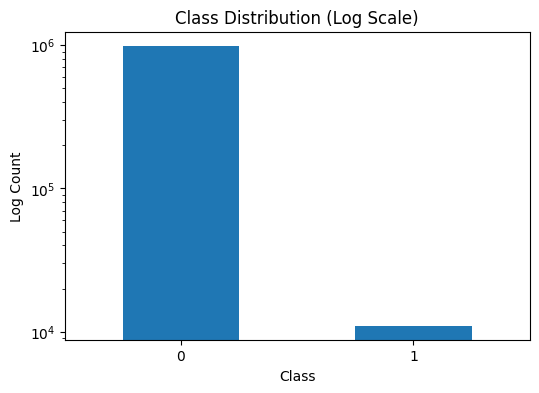

In [28]:
plt.figure(figsize=(6,4))
class_counts.plot(kind="bar", logy=True)
plt.title("Class Distribution (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Log Count")
plt.xticks(rotation=0)
plt.show()


### Interpretation

The log-scale plot confirms the severe imbalance between fraudulent and non-fraudulent applications. Even after applying a logarithmic scale, the fraud class remains much smaller than the legitimate class. This indicates that fraud detection models may become biased toward predicting the majority class if imbalance-handling techniques are not applied.

##    1.3.3 - No-skill baseline


In [29]:
majority_accuracy = class_counts.max() / class_counts.sum()

print("No-skill baseline accuracy:", majority_accuracy)

No-skill baseline accuracy: 0.988971



### Interpretation

The no-skill baseline accuracy is extremely high because the dataset is dominated by legitimate applications. A model that predicts every application as non-fraudulent would still achieve close to 99% accuracy. This demonstrates that accuracy alone is not an appropriate evaluation metric for this problem.


##    1.3.4 - Class weights


In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(bank_df[target_col]),
    y=bank_df[target_col]
)

class_weight_dict = dict(zip(np.unique(bank_df[target_col]), weights))

print("Class weights:")
print(class_weight_dict)

Class weights:
{np.int64(0): np.float64(0.505575997678395), np.int64(1): np.float64(45.33502584096473)}



### Interpretation

The fraud class receives a much larger weight than the non-fraud class. This adjustment compensates for the imbalance by forcing the models to place greater importance on correctly identifying fraud cases during training.

 ## 1.3.5 - Stratified train-test split check


In [31]:
X = bank_df.drop(columns=[target_col])
y = bank_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

print("Train distribution:")
display(y_train.value_counts(normalize=True))

print("\nTest distribution:")
display(y_test.value_counts(normalize=True))

Train distribution:


,proportion
fraud_bool,
0,0.988971
1,0.011029



Test distribution:


,proportion
fraud_bool,
0,0.98897
1,0.01103



### Interpretation

The class proportions in both the training and testing sets remain nearly identical after stratified splitting. This confirms that the train-test split preserved the original class distribution and avoided introducing sampling bias.



##1.3.6 - Class imbalance findings

In [32]:
print("===== CLASS IMBALANCE SUMMARY =====\n")

print(f"Total samples: {len(bank_df)}")
print(class_counts)
print("\nImbalance ratio:", imbalance_ratio)
print("No-skill baseline accuracy:", majority_accuracy)

print("\nKey insight:")
print("- Dataset is highly imbalanced, with fraud being a rare class.")
print("- Evaluation should focus on recall, F1-score, and ROC-AUC rather than accuracy.")

===== CLASS IMBALANCE SUMMARY =====

Total samples: 1000000
fraud_bool
0    988971
1     11029
Name: count, dtype: int64

Imbalance ratio: 89.67005168192946
No-skill baseline accuracy: 0.988971

Key insight:
- Dataset is highly imbalanced, with fraud being a rare class.
- Evaluation should focus on recall, F1-score, and ROC-AUC rather than accuracy.



### Interpretation
The dataset is highly imbalanced, making fraud detection challenging. Because fraud cases are rare, specialized handling techniques such as class weighting, SMOTE, threshold tuning, and recall-focused evaluation are necessary to improve fraud detection performance.

#1.4 - Univariate Analysis


##    1.4.1 - Income distribution


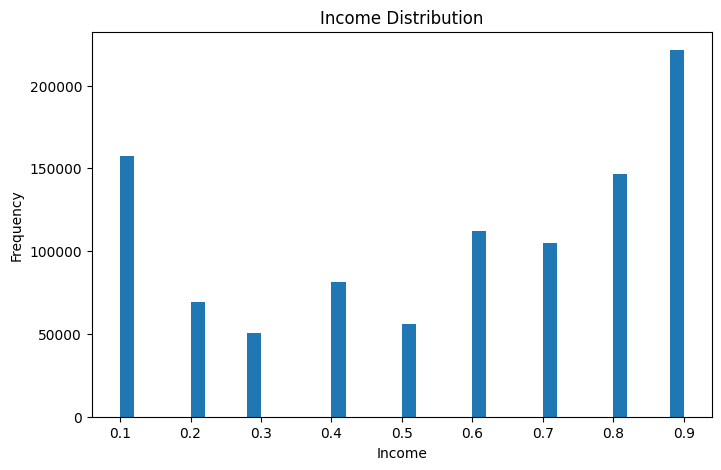

In [33]:
plt.figure(figsize=(8,5))

plt.hist(
    bank_df["income"],
    bins=40
)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()


### Interpretation

The income distribution appears negatively skewed (left-skewed). Higher normalized income values, particularly around 0.9, occur more frequently than many of the mid-range values, while lower income levels show less consistent representation aside from a strong concentration near 0.1. This suggests that a substantial portion of applicants fall into higher income ranges, although there is also a notable cluster of lower-income applicants. The distribution is therefore not symmetrical and indicates variation in applicant financial profiles.


##    1.4.2 - Income percentiles


In [34]:
income_percentiles = bank_df["income"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

print("Income Percentiles:")
display(income_percentiles)

Income Percentiles:


,income
0.25,0.3
0.50,0.6
0.75,0.8
0.90,0.9
0.95,0.9
0.99,0.9



### Interpretation

The income percentiles reveal that the distribution is concentrated toward the upper end of the normalised scale. The 25th percentile sits at 0.3, the median at 0.6, and the 75th percentile at 0.8, indicating that the majority of applicants report relatively higher income levels. Notably, the 90th, 95th, and 99th percentiles all converge at the same value of 0.9, suggesting that a large proportion of applicants are clustered at the upper boundary of the income scale. This ceiling effect means that income alone has limited ability to distinguish between applicants at the higher end of the range, as many individuals share the same maximum reported value.

##    1.4.3 - Session-length distribution


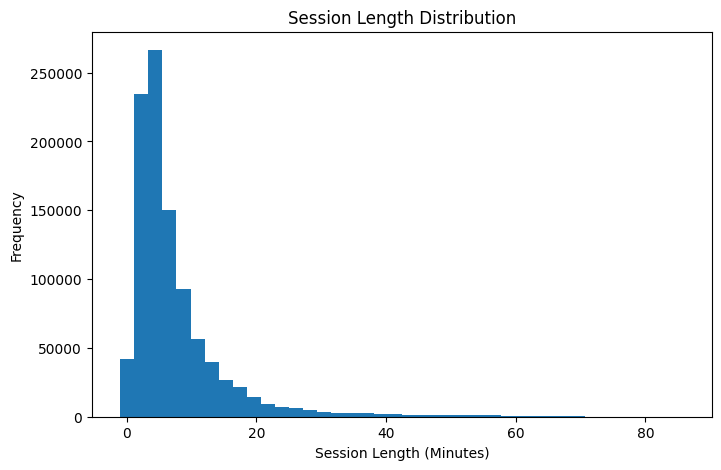

In [35]:
plt.figure(figsize=(8,5))

plt.hist(
    bank_df["session_length_in_minutes"],
    bins=40
)

plt.title("Session Length Distribution")
plt.xlabel("Session Length (Minutes)")
plt.ylabel("Frequency")

plt.show()


### Interpretation

The session-length distribution appears skewed, indicating that most users spend a relatively short amount of time during the application process while a smaller number remain active for much longer periods.

##    1.4.4 - Numeric feature summary


In [36]:
numeric_summary = bank_df.select_dtypes(
    include=["number"]
).describe().T

display(
    numeric_summary[
        ["mean", "std", "min", "max"]
    ]
)

,mean,std,min,max
fraud_bool,0.011029,0.104438,0.000000e+00,1.000000
income,0.562696,0.290343,1.000000e-01,0.900000
name_email_similarity,0.493694,0.289125,1.434550e-06,0.999999
prev_address_months_count,16.718568,44.046230,-1.000000e+00,383.000000
current_address_months_count,86.587867,88.406599,-1.000000e+00,428.000000
customer_age,33.689080,12.025799,1.000000e+01,90.000000
days_since_request,1.025705,5.381835,4.036860e-09,78.456904
intended_balcon_amount,8.661499,20.236155,-1.553055e+01,112.956928
zip_count_4w,1572.692049,1005.374565,1.000000e+00,6700.000000
velocity_6h,5665.296605,3009.380665,-1.706031e+02,16715.565404



### Interpretation
The numeric summary reveals considerable variation in scale and spread across features. Velocity-related variables dominate in terms of magnitude, with velocity_6h showing a mean of 5,665 and a standard deviation of 3,009, making standardisation essential before modelling. Several features contain negative minimum values, including velocity_6h, credit_risk_score, intended_balcon_amount, and address-related columns such as prev_address_months_count and bank_months_count, where −1 consistently appears as a placeholder for missing data rather than a genuine measurement. device_fraud_count is entirely constant at zero across all rows, confirming it provides no predictive value and should be dropped. Binary features such as phone_mobile_valid (mean 0.89) and foreign_request (mean 0.025) behave as expected, while zip_count_4w ranges from 1 to 6,700, hinting at possible geographic clustering of fraudulent activity.

#    1.4.5 - Distribution plots for selected features


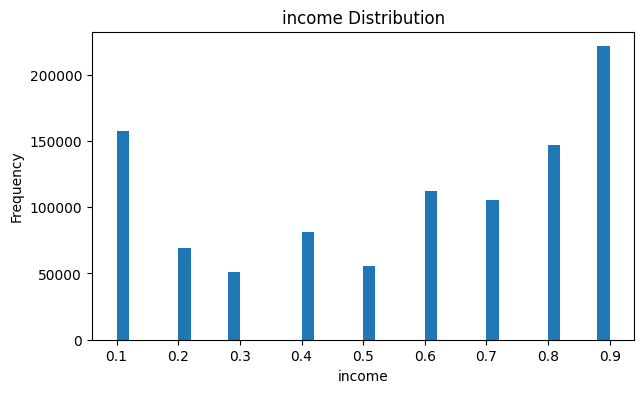

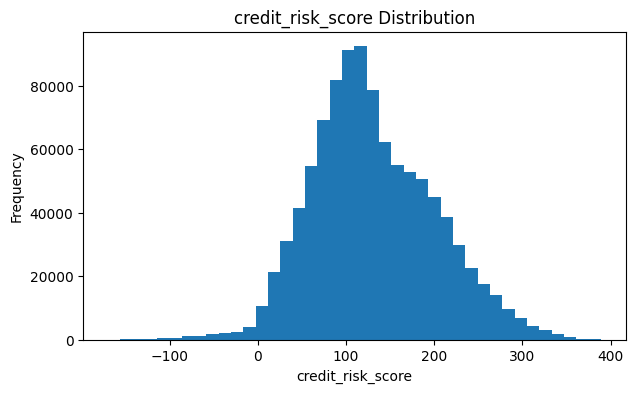

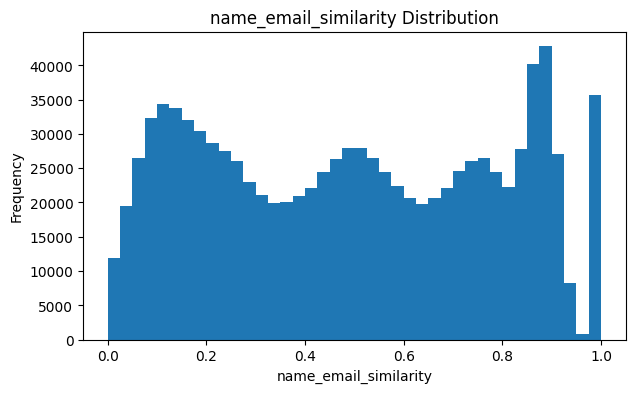

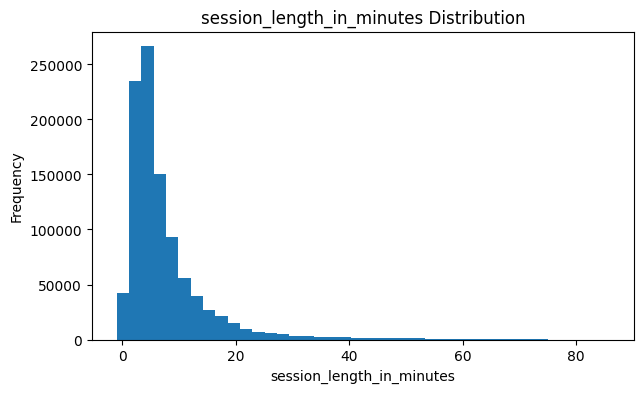

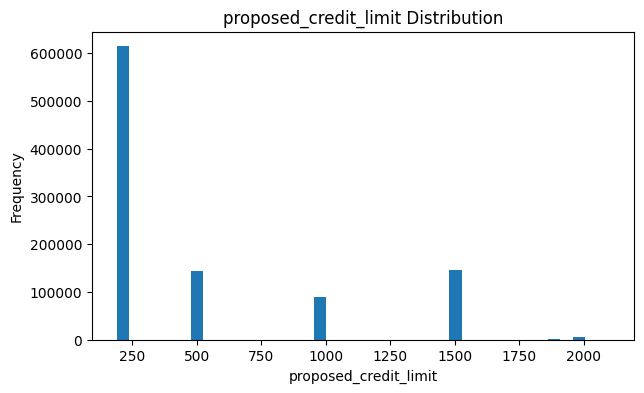

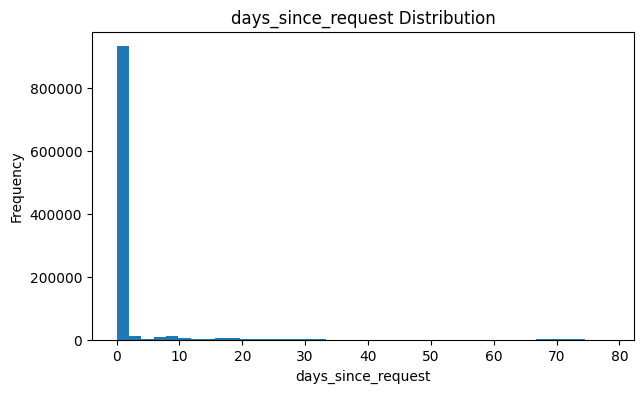

In [37]:
selected_features = [
    "income",
    "credit_risk_score",
    "name_email_similarity",
    "session_length_in_minutes",
    "proposed_credit_limit",
    "days_since_request"
]

for feature in selected_features:

    if feature in bank_df.columns:

        plt.figure(figsize=(7,4))

        plt.hist(
            bank_df[feature],
            bins=40
        )

        plt.title(f"{feature} Distribution")
        plt.xlabel(feature)
        plt.ylabel("Frequency")

        plt.show()


### Interpretation

### Income:
The income distribution is unusual in that it appears discretised into fixed bands rather than being a continuous variable, with values only occurring at 0.1, 0.2, 0.3 and so on up to 0.9. The highest frequencies are at 0.9 and 0.1, creating a U-shaped pattern where both the highest and lowest income bands are the most common. Mid-range income values around 0.3 and 0.5 are the least represented. This suggests income was originally a categorical or banded variable that has been numerically encoded rather than a true continuous measurement.


### Credit Risk Score:
The credit risk score distribution is approximately bell-shaped and roughly symmetric, with the bulk of applicants scoring between 0 and 250 and the peak sitting around 100 to 120. It tapers gradually in both directions, with a short left tail extending into negative values which likely represent missing credit history rather than genuine negative scores. This is one of the more normally distributed features in the dataset.


### Name Email Similarity:
This distribution is irregular and multimodal, showing several peaks rather than a single central concentration. There are noticeable clusters around 0.1, 0.5, and particularly near 0.9 and 1.0, where frequency spikes sharply. The pattern suggests that many applicants either have a very strong or very weak match between their name and email address, with fewer falling in the middle. The spike at 1.0 could indicate cases where the name and email are an exact match, which may be worth examining as a potential fraud signal.


### Session Length in Minutes:
The session length distribution is strongly right-skewed, with the vast majority of applicants completing the process within the first 5 to 10 minutes and frequency dropping off sharply beyond that. The long right tail extends all the way to past 70 minutes, though very few applicants reach that point. This is consistent with what would be expected — most genuine users complete an application quickly, but unusual session lengths at either extreme may warrant closer attention.


### Proposed Credit Limit:
This distribution is clearly discrete rather than continuous, with applicants concentrated almost entirely at a small number of fixed values — predominantly 250, followed by 500, 1000, and 1500. The bar at 250 is overwhelmingly dominant, accounting for over 600,000 of the 1,000,000 applicants. This confirms that proposed credit limit is effectively a categorical variable presented as numeric, and that the majority of applicants are requesting the minimum available credit tier.


### Days Since Request:
The distribution is extremely right-skewed, with close to 900,000 applicants falling within the first 1 to 2 days of submitting their request. Beyond that the frequency drops almost to zero, with only a very small number of cases extending out past 10 or 20 days and an extreme few reaching beyond 50 days. This means the vast majority of applications are processed almost immediately, and any case with a significantly delayed request timeline is a statistical outlier that could carry relevance for fraud detection.


#    1.4.6 - Full Numeric-feature histogram grid


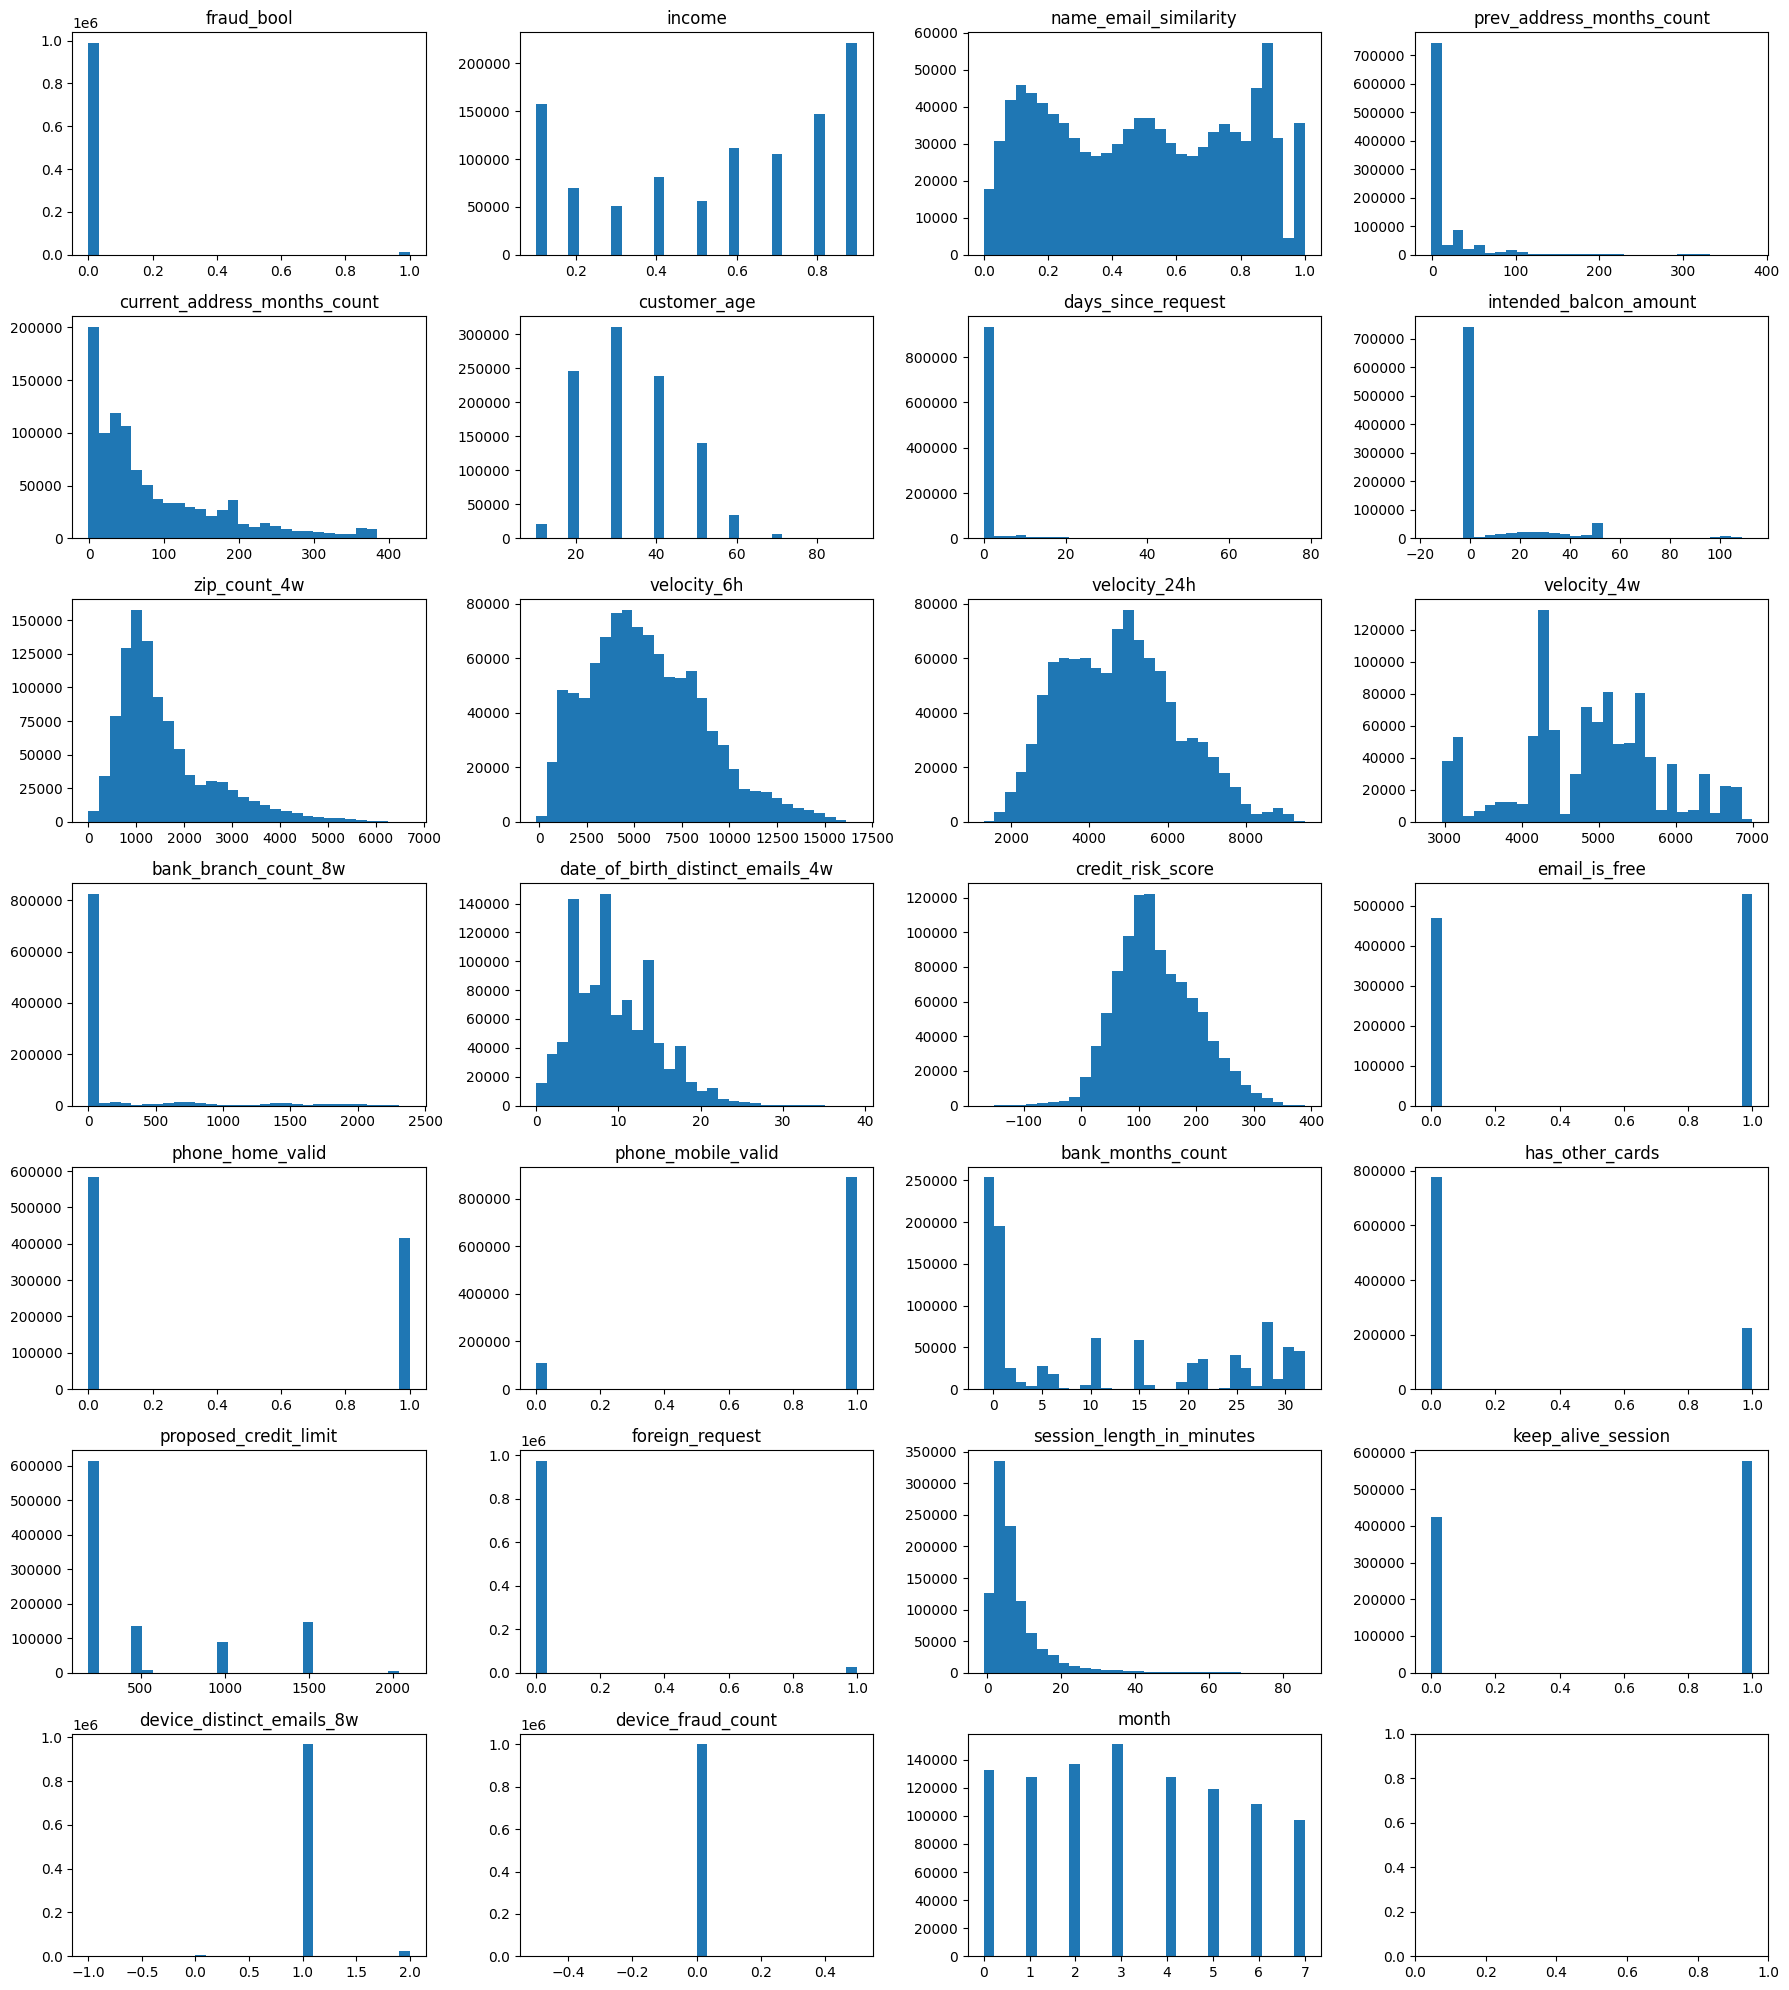

In [38]:
numeric_cols = bank_df.select_dtypes(
    include=["number"]
).columns

fig, axes = plt.subplots(
    nrows=7,
    ncols=4,
    figsize=(18,20)
)

axes = axes.flatten()

for i, feature in enumerate(numeric_cols):

    axes[i].hist(
        bank_df[feature],
        bins=30
    )

    axes[i].set_title(feature)

plt.tight_layout()

plt.show()


### Interpretation

The histogram grid provides an overview of the distributional shape of every numeric feature in the dataset. Several clear patterns emerge across the variables.

The target variable fraud_bool confirms the severe class imbalance, with the overwhelming majority of observations at 0 and only a tiny bar visible at 1, making fraud cases almost invisible on the plot. income displays the discretised U-shape noted earlier, with strong concentrations at the lowest and highest bands. name_email_similarity is irregular and multimodal, spreading relatively evenly across its range with notable spikes near 0.9 and 1.0. prev_address_months_count and current_address_months_count are both heavily right-skewed, with most applicants concentrated near zero and long tails extending toward 400, indicating that the majority of applicants have relatively short address histories.

customer_age appears discretised into age bands rather than being truly continuous, showing distinct bars at regular intervals with the highest frequencies around 20 to 40 years. days_since_request is extremely concentrated near zero, confirming that nearly all applications are submitted almost immediately after the initial request. intended_balcon_amount shows a strong spike at zero with a moderate right tail, suggesting most applicants do not intend to transfer a balance while a smaller group intends to transfer varying amounts.

The velocity features — velocity_6h, velocity_24h, and velocity_4w — all show broad, roughly bell-shaped distributions but with considerable spread and some irregularity, reflecting the high variability in network-level application activity. zip_count_4w is right-skewed with most applicants coming from postcodes with moderate recent activity. bank_branch_count_8w is extremely right-skewed, with the vast majority of applicants showing very low branch contact counts and a long tail of high-activity cases.

date_of_birth_distinct_emails_4w shows a multimodal pattern with distinct peaks, suggesting this variable takes on a limited set of common values rather than varying freely. credit_risk_score is approximately bell-shaped and the most normally distributed feature in the dataset. Binary features including email_is_free, phone_home_valid, phone_mobile_valid, has_other_cards, foreign_request, and keep_alive_session all show two bars at 0 and 1 as expected, with varying proportions between them. phone_mobile_valid is dominated by 1, confirming most applicants provide a valid mobile number, while foreign_request is dominated by 0, reflecting that international applications are rare.

bank_months_count is right-skewed with a spike at low values and a secondary cluster around 15 to 30 months, hinting at two distinct groups of applicants in terms of banking history length. proposed_credit_limit is clearly discrete with a dominant bar at 250. session_length_in_minutes is strongly right-skewed as noted previously. device_distinct_emails_8w shows almost all values concentrated at 1 with very small bars at −1 and 2, suggesting most devices are associated with a single email address. device_fraud_count is entirely flat at zero, confirming it is a constant and useless feature. Finally, month shows a relatively even distribution across values 1 to 7 with a slight decline toward higher months, indicating the data was collected over a seven-month period with fairly consistent application volumes throughout.

#    1.4.7 - Univariate analysis findings

In [39]:
print("===== UNIVARIATE ANALYSIS FINDINGS =====\n")

# ==========================================
# Skewness analysis
# ==========================================

numeric_cols = bank_df.select_dtypes(
    include=["number"]
).columns

skewness = bank_df[numeric_cols].skew()

high_skew = skewness[
    abs(skewness) > 1
].sort_values(
    key=abs,
    ascending=False
)

print("Highly skewed features:")

if len(high_skew) > 0:
    display(high_skew.to_frame("skewness"))
else:
    print("No highly skewed features found.")

# ==========================================
# Outlier check using IQR
# ==========================================

outlier_counts = {}

for col in numeric_cols:

    Q1 = bank_df[col].quantile(0.25)
    Q3 = bank_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outliers = (
        (bank_df[col] < lower) |
        (bank_df[col] > upper)
    ).sum()

    outlier_counts[col] = outliers

outlier_df = pd.DataFrame.from_dict(
    outlier_counts,
    orient="index",
    columns=["outlier_count"]
)

print("\nFeatures with most outliers:")

display(
    outlier_df
    .sort_values(
        "outlier_count",
        ascending=False
    )
    .head(10)
)

# ==========================================
# Variability analysis
# ==========================================

std_values = bank_df[numeric_cols].std()

high_variability = std_values.sort_values(
    ascending=False
).head(10)

print("\nFeatures with highest variability:")

display(
    high_variability.to_frame("standard_deviation")
)

# ==========================================
# Automatic summary
# ==========================================

print("\n===== AUTOMATIC SUMMARY =====")

if len(high_skew) > 0:
    print("- Several numeric features are heavily skewed.")

if outlier_df["outlier_count"].max() > 0:
    print("- Multiple features contain potential outliers.")

print("- Feature distributions vary significantly across variables.")
print("- Some variables may require scaling or transformation later.")
print("- Patterns suggest complex and non-linear fraud behaviour.")

===== UNIVARIATE ANALYSIS FINDINGS =====

Highly skewed features:


,skewness
fraud_bool,9.363838
days_since_request,9.278955
foreign_request,6.053306
prev_address_months_count,4.063888
session_length_in_minutes,3.304575
bank_branch_count_8w,2.747161
intended_balcon_amount,2.507173
phone_mobile_valid,-2.487616
device_distinct_emails_8w,2.430764
zip_count_4w,1.456657



Features with most outliers:


,outlier_count
proposed_credit_limit,241742
has_other_cards,222988
intended_balcon_amount,222702
bank_branch_count_8w,175243
prev_address_months_count,157320
phone_mobile_valid,110324
days_since_request,94834
session_length_in_minutes,78789
zip_count_4w,59871
current_address_months_count,41001



Features with highest variability:


,standard_deviation
velocity_6h,3009.380665
velocity_24h,1479.212612
zip_count_4w,1005.374565
velocity_4w,919.843934
proposed_credit_limit,487.559902
bank_branch_count_8w,459.625329
current_address_months_count,88.406599
credit_risk_score,69.681812
prev_address_months_count,44.046230
intended_balcon_amount,20.236155



===== AUTOMATIC SUMMARY =====
- Several numeric features are heavily skewed.
- Multiple features contain potential outliers.
- Feature distributions vary significantly across variables.
- Some variables may require scaling or transformation later.
- Patterns suggest complex and non-linear fraud behaviour.



### Interpretation

The univariate analysis highlights the individual distribution patterns of features such as Amount, Time, and selected V variables. Skewed distributions and extreme values suggest the need for scaling or robust modelling approaches.

The outputs above should be interpreted in relation to fraud detection performance, dataset behaviour, and modelling reliability. Any notable trends, limitations, or unusual observations identified in the results should be considered when evaluating the effectiveness of the approach.


#1.5 - Bivariate Analysis


##    1.5.1 - Balanced plotting sample


In [40]:
fraud_df = bank_df[
    bank_df["fraud_bool"] == 1
]

nonfraud_df = bank_df[
    bank_df["fraud_bool"] == 0
].sample(
    n=len(fraud_df),
    random_state=42
)

balanced_plot_df = pd.concat(
    [fraud_df, nonfraud_df]
)

print("Balanced sample shape:")
print(balanced_plot_df.shape)

print("\nClass distribution:")
display(
    balanced_plot_df["fraud_bool"]
    .value_counts()
)

Balanced sample shape:
(22058, 32)

Class distribution:


,count
fraud_bool,
1,11029
0,11029



### Interpretation

The bivariate analysis examines relationships between features and the fraud target. Features showing visible separation between fraud and non-fraud classes may contribute strongly to predictive performance.

The outputs above should be interpreted in relation to fraud detection performance, dataset behaviour, and modelling reliability. Any notable trends, limitations, or unusual observations identified in the results should be considered when evaluating the effectiveness of the approach.


##    1.5.2 - Income compared with Fraud Class


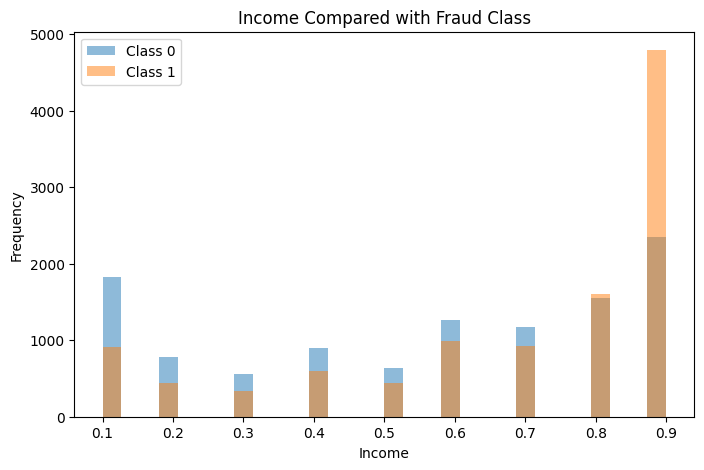

In [41]:
plt.figure(figsize=(8,5))

for class_value in [0, 1]:

    subset = balanced_plot_df[
        balanced_plot_df["fraud_bool"] == class_value
    ]

    plt.hist(
        subset["income"],
        bins=30,
        alpha=0.5,
        label=f"Class {class_value}"
    )

plt.title("Income Compared with Fraud Class")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.legend()

plt.show()


### Interpretation

The bivariate analysis examines relationships between features and the fraud target. Features showing visible separation between fraud and non-fraud classes may contribute strongly to predictive performance.

The outputs above should be interpreted in relation to fraud detection performance, dataset behaviour, and modelling reliability. Any notable trends, limitations, or unusual observations identified in the results should be considered when evaluating the effectiveness of the approach.


##    1.5.3 - Session length compared with Fraud Class


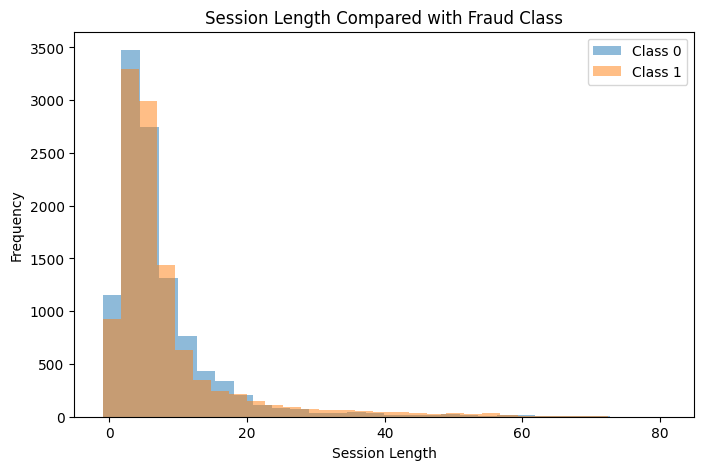

In [42]:
plt.figure(figsize=(8,5))

for class_value in [0, 1]:

    subset = balanced_plot_df[
        balanced_plot_df["fraud_bool"] == class_value
    ]

    plt.hist(
        subset["session_length_in_minutes"],
        bins=30,
        alpha=0.5,
        label=f"Class {class_value}"
    )

plt.title("Session Length Compared with Fraud Class")
plt.xlabel("Session Length")
plt.ylabel("Frequency")

plt.legend()

plt.show()


### Interpretation

The bivariate analysis examines relationships between features and the fraud target. Features showing visible separation between fraud and non-fraud classes may contribute strongly to predictive performance.

The outputs above should be interpreted in relation to fraud detection performance, dataset behaviour, and modelling reliability. Any notable trends, limitations, or unusual observations identified in the results should be considered when evaluating the effectiveness of the approach.


##    1.5.4 - Selected features compared with Fraud Class


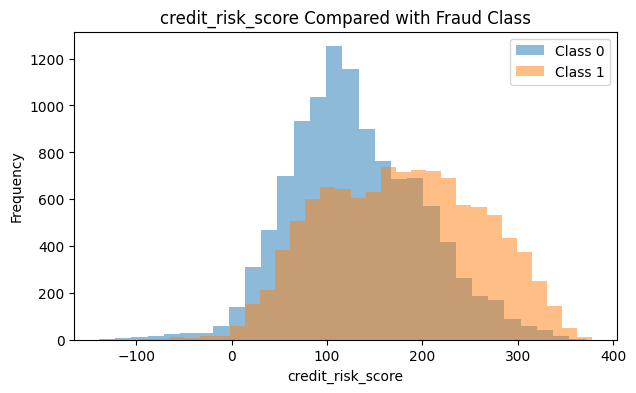

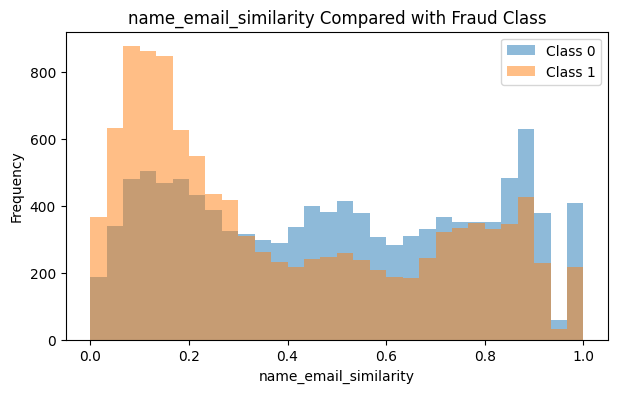

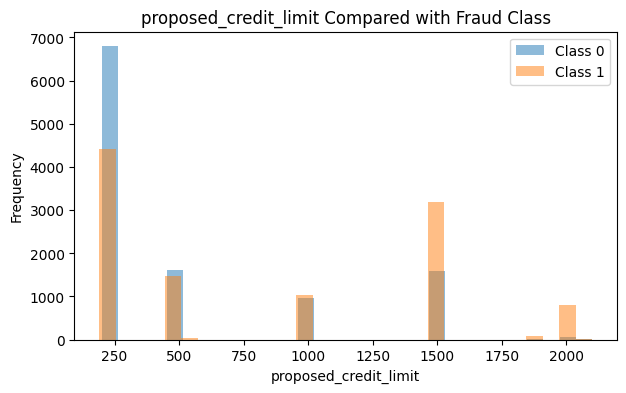

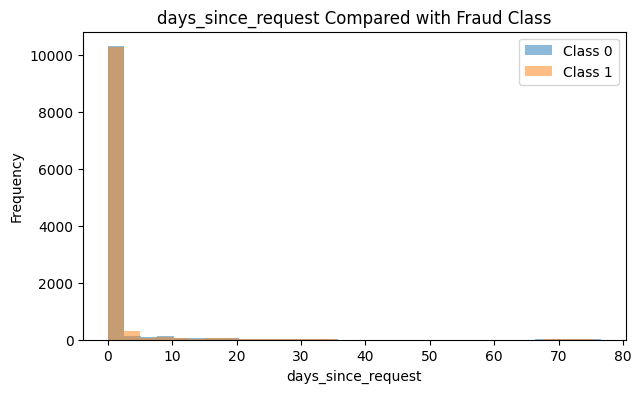

In [43]:
selected_features = [
    "credit_risk_score",
    "name_email_similarity",
    "proposed_credit_limit",
    "days_since_request"
]

for feature in selected_features:

    if feature in balanced_plot_df.columns:

        plt.figure(figsize=(7,4))

        for class_value in [0, 1]:

            subset = balanced_plot_df[
                balanced_plot_df["fraud_bool"] == class_value
            ]

            plt.hist(
                subset[feature],
                bins=30,
                alpha=0.5,
                label=f"Class {class_value}"
            )

        plt.title(f"{feature} Compared with Fraud Class")
        plt.xlabel(feature)
        plt.ylabel("Frequency")

        plt.legend()

        plt.show()


### Interpretation

The bivariate analysis examines relationships between features and the fraud target. Features showing visible separation between fraud and non-fraud classes may contribute strongly to predictive performance.

The outputs above should be interpreted in relation to fraud detection performance, dataset behaviour, and modelling reliability. Any notable trends, limitations, or unusual observations identified in the results should be considered when evaluating the effectiveness of the approach.


##    1.5.5 - Correlation with the target


Top correlations with fraud target:


,correlation
credit_risk_score,0.070624
proposed_credit_limit,0.068907
customer_age,0.062959
keep_alive_session,-0.050296
income,0.045079
date_of_birth_distinct_emails_4w,-0.043224
name_email_similarity,-0.036720
device_distinct_emails_8w,0.035704
has_other_cards,-0.035156
phone_home_valid,-0.035128


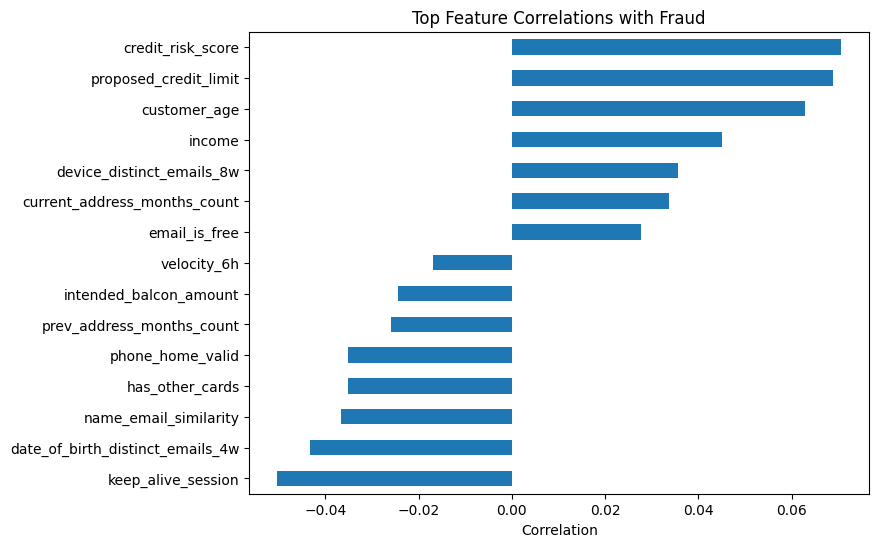

In [44]:
target_col = "fraud_bool"

numeric_df = bank_df.select_dtypes(
    include=["number"]
)

correlations = numeric_df.corr(
    numeric_only=True
)[target_col].drop(target_col)

top_corr = correlations.sort_values(
    key=abs,
    ascending=False
)

print("Top correlations with fraud target:")

display(
    top_corr.head(15).to_frame("correlation")
)

plt.figure(figsize=(8,6))

top_corr.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top Feature Correlations with Fraud")
plt.xlabel("Correlation")

plt.show()


### Interpretation

The bivariate analysis examines relationships between features and the fraud target. Features showing visible separation between fraud and non-fraud classes may contribute strongly to predictive performance.

The outputs above should be interpreted in relation to fraud detection performance, dataset behaviour, and modelling reliability. Any notable trends, limitations, or unusual observations identified in the results should be considered when evaluating the effectiveness of the approach.


##    1.5.6 - Bivariate analysis findings

In [45]:
print("===== BIVARIATE ANALYSIS FINDINGS =====\n")

# ==========================================
# Mean differences by class
# ==========================================

group_means = bank_df.groupby(
    "fraud_bool"
).mean(numeric_only=True)

mean_diff = abs(
    group_means.loc[1] -
    group_means.loc[0]
).sort_values(
    ascending=False
)

print("Largest mean differences between classes:")

display(
    mean_diff.head(10).to_frame("mean_difference")
)

# ==========================================
# Correlation summary
# ==========================================

strong_corr = correlations[
    abs(correlations) > 0.05
]

print("\nFeatures with stronger correlations:")

display(
    strong_corr.sort_values(
        key=abs,
        ascending=False
    ).to_frame("correlation")
)

# ==========================================
# Automatic findings
# ==========================================

print("\n===== AUTOMATIC SUMMARY =====")

if len(strong_corr) > 0:
    print("- Several variables show measurable relationships with fraud.")

print("- Fraud and non-fraud classes still overlap heavily.")
print("- Behavioural and application-related variables appear important.")
print("- No single feature clearly separates fraud from non-fraud.")
print("- Fraud detection likely depends on combining multiple variables.")

===== BIVARIATE ANALYSIS FINDINGS =====

Largest mean differences between classes:


,mean_difference
velocity_6h,486.751543
proposed_credit_limit,321.683601
velocity_24h,158.390051
velocity_4w,101.600382
bank_branch_count_8w,50.947321
zip_count_4w,50.172850
credit_risk_score,47.120449
current_address_months_count,28.527928
prev_address_months_count,10.978282
customer_age,7.249520



Features with stronger correlations:


,correlation
credit_risk_score,0.070624
proposed_credit_limit,0.068907
customer_age,0.062959
keep_alive_session,-0.050296



===== AUTOMATIC SUMMARY =====
- Several variables show measurable relationships with fraud.
- Fraud and non-fraud classes still overlap heavily.
- Behavioural and application-related variables appear important.
- No single feature clearly separates fraud from non-fraud.
- Fraud detection likely depends on combining multiple variables.



### Interpretation

Only four features exceed an absolute correlation of 0.05 with the fraud target — credit_risk_score (0.071), proposed_credit_limit (0.069), customer_age (0.063), and keep_alive_session (−0.050) — and even these are very weak, confirming that no single feature can reliably identify fraud on its own. The mean difference analysis reveals that fraudulent applicants tend to have higher income, higher credit risk scores, and are older on average than legitimate applicants, suggesting that fraudsters in this dataset are deliberately mimicking the profile of financially established customers in order to access higher credit limits. Overall, fraud detection in this dataset depends on combining multiple weak signals rather than any one dominant feature, which points toward ensemble models as the most appropriate approach.


#1.6 - Multivariate Analysis


##    1.6.1 - Feature set used for multivariate checks


In [46]:
bank_df = load_dataset("Base.csv")
TARGET_COL = "fraud_bool"

# numeric features only
numeric_cols = bank_df.select_dtypes(include=["number"]).columns.tolist()

# remove target column
numeric_cols = [c for c in numeric_cols if c != TARGET_COL]

# choose the most useful features for multivariate analysis
selected_features = [
    "income",
    "name_email_similarity",
    "current_address_months_count",
    "customer_age",
    "days_since_request",
    "intended_balcon_amount",
    "zip_count_4w",
    "velocity_6h",
    "session_length_in_minutes",
    "device_distinct_emails_8w"
]

# keep only columns that exist in the dataset
selected_features = [c for c in selected_features if c in bank_df.columns]

print("Selected features for multivariate analysis:")
print(selected_features)

Selected features for multivariate analysis:
['income', 'name_email_similarity', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'session_length_in_minutes', 'device_distinct_emails_8w']



### Interpretation

Ten features were selected for the multivariate analysis, covering a range of behavioural, financial, and identity-related variables. The selection includes income, name_email_similarity, current_address_months_count, customer_age, days_since_request, intended_balcon_amount, zip_count_4w, velocity_6h, session_length_in_minutes, and device_distinct_emails_8w. These were chosen because they represent different aspects of the applicant profile — from financial standing and identity consistency to session behaviour and network-level activity — making them the most informative candidates for examining how features interact with each other and with the fraud target collectively, rather than in isolation.


##    1.6.2 - Correlation pattern among selected features


In [47]:
corr_matrix = bank_df[selected_features + [TARGET_COL]].corr(numeric_only=True)

print(corr_matrix)

                                income  name_email_similarity  \
income                        1.000000              -0.038519   
name_email_similarity        -0.038519               1.000000   
current_address_months_count -0.036985               0.050305   
customer_age                  0.125822              -0.048902   
days_since_request           -0.015877              -0.007736   
intended_balcon_amount        0.059046               0.029040   
zip_count_4w                 -0.080581               0.025114   
velocity_6h                  -0.096431               0.024881   
session_length_in_minutes    -0.055430               0.005998   
device_distinct_emails_8w    -0.009992              -0.017804   
fraud_bool                    0.045079              -0.036720   

                              current_address_months_count  customer_age  \
income                                           -0.036985      0.125822   
name_email_similarity                             0.050305     -0.0


### Interpretation

The correlation matrix shows that the relationships between the ten selected features are generally very weak, with most pairwise correlations sitting close to zero. The strongest inter-feature relationship observed is between current_address_months_count and customer_age (0.143), and between zip_count_4w and velocity_6h (0.142), which makes intuitive sense — older customers tend to have lived at their current address longer, and areas with high zip-level application activity naturally correspond to higher velocity counts. Beyond these two pairs, no other feature combinations show meaningful correlation, suggesting that the selected features are largely independent of one another and are each capturing different aspects of applicant behaviour.  


With respect to the fraud target, all correlations remain very weak, with customer_age (0.063) and income (0.045) showing the strongest positive relationships and name_email_similarity (−0.037) and intended_balcon_amount (−0.025) showing the strongest negative ones. The near-zero correlation of days_since_request (0.001) and velocity_6h (−0.017) with the fraud target is particularly notable given how skewed and variable these features are, reinforcing the conclusion that fraud in this dataset cannot be captured through linear relationships alone and that more complex, non-linear modelling approaches will be required.

##    1.6.3 - Correlation heatmap reading


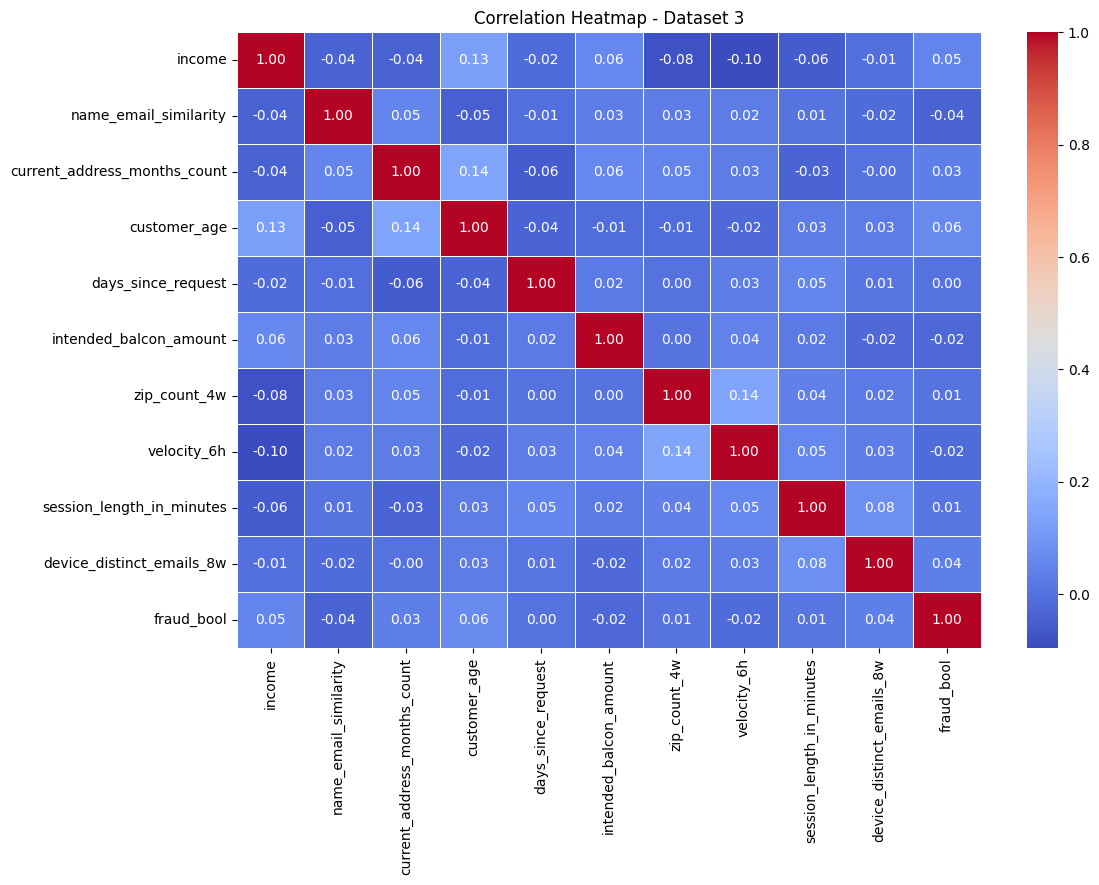

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap - Dataset 3")
plt.show()

### Interpretation

The heatmap visually confirms what the correlation matrix showed numerically — the vast majority of cells appear in light blue or white, indicating that almost all feature pairs have correlations close to zero. The diagonal, which always shows a perfect correlation of 1.00 between a feature and itself, stands out in deep red as expected.


The two most visible off-diagonal relationships are current_address_months_count and customer_age (0.14), and zip_count_4w and velocity_6h (0.14), both appearing as the only noticeably warm-coloured cells outside the diagonal. These are mild positive relationships at best and do not suggest any serious multicollinearity concern that would require feature removal.


With respect to the fraud target column on the far right, all cells remain in a very light blue or near-white shade, reflecting the consistently weak correlations identified in the previous section. No feature shows a strong enough individual relationship with fraud_bool to stand out visually on the heatmap. This is a clear visual confirmation that fraud in this dataset is not driven by any single linear relationship and that the model will need to learn from the combined interaction of multiple features simultaneously rather than from any dominant individual signal.

##    1.6.4 - Pairwise feature interaction plots


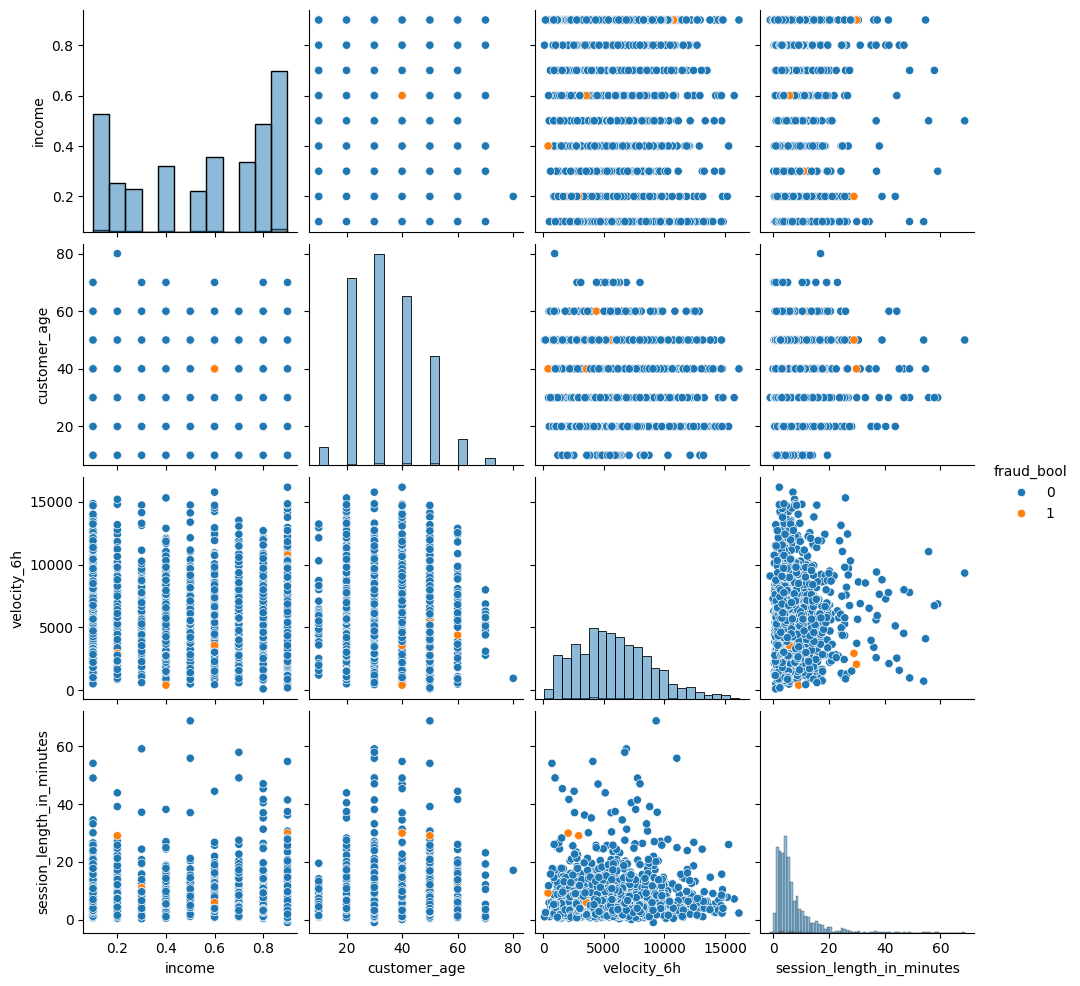

In [49]:
pairplot_features = [
    "income",
    "customer_age",
    "velocity_6h",
    "session_length_in_minutes",
    TARGET_COL
]

# sample data for faster plotting
sample_df = bank_df[pairplot_features].sample(
    n=min(1500, len(bank_df)),
    random_state=42
)

sns.pairplot(
    sample_df,
    hue=TARGET_COL,
    diag_kind="hist"
)

plt.show()


### Interpretation

The pairplot examines interactions between income, customer_age, velocity_6h, and session_length_in_minutes, with fraud cases shown in orange and legitimate cases in blue. The most immediate observation is that the orange points representing fraud are extremely sparse throughout every scatter plot, reflecting the severe class imbalance in the dataset. In most panels the fraud cases are barely distinguishable from the mass of legitimate applications, which visually reinforces why this is such a difficult detection problem.


Looking at individual interactions, the income versus customer_age plot shows that both variables are discretised, producing a grid-like scatter pattern rather than a continuous cloud. Fraud cases appear scattered across multiple income and age combinations without clustering in any clearly separable region. The velocity_6h versus session_length_in_minutes panel shows the most interesting pattern — legitimate cases form a dense concentration at lower session lengths while fraud cases appear more spread out across higher velocity values, though the overlap is still substantial.


The diagonal histograms confirm the distributional shapes noted in the univariate analysis — income is banded, customer_age is discretised into age groups, velocity_6h is broadly bell-shaped with a long right tail, and session_length_in_minutes is strongly right-skewed. Overall the pairplot confirms that no two-feature combination produces a clean boundary between fraud and non-fraud, and that the orange fraud points are consistently embedded within the blue majority class across all feature interactions examined.


##1.6.5 - Pairwise plot reading


In [50]:
fraud_summary = (
    bank_df
    .groupby(TARGET_COL)[selected_features]
    .mean()
)

print(fraud_summary)

              income  name_email_similarity  current_address_months_count  \
fraud_bool                                                                  
0           0.561313               0.494815                     86.273232   
1           0.686635               0.393161                    114.801161   

            customer_age  days_since_request  intended_balcon_amount  \
fraud_bool                                                             
0              33.609125            1.025383                8.713907   
1              40.858645            1.054615                3.962009   

            zip_count_4w  velocity_6h  session_length_in_minutes  \
fraud_bool                                                         
0            1572.138693  5670.664988                   7.537306   
1            1622.311542  5183.913444                   8.229520   

            device_distinct_emails_8w  
fraud_bool                             
0                            1.017630  
1        


### Interpretation

The mean values by fraud class reveal some subtle but meaningful differences between legitimate and fraudulent applicants across the selected features. Fraudulent applicants show a noticeably higher mean income (0.687 versus 0.561) and are older on average (40.9 versus 33.6 years), reinforcing the earlier finding that fraudsters in this dataset tend to mimic the profile of more financially established customers. They also show a higher current_address_months_count (114.8 versus 86.3), suggesting that fraudulent applications more often claim longer residential stability, which may be a deliberate attempt to appear more credible.


On the other hand, fraudulent applicants show a lower mean name_email_similarity (0.393 versus 0.495), indicating a weaker match between the name and email address provided, which is consistent with the use of fabricated or mismatched identity details. intended_balcon_amount is also lower for fraud cases (3.96 versus 8.71), suggesting fraudulent applicants are less likely to declare an intention to transfer a balance, possibly to avoid drawing attention to the application.


The velocity and session features show smaller differences between classes. velocity_6h is slightly lower for fraud (5,183 versus 5,671), while session_length_in_minutes is marginally higher (8.23 versus 7.54) and device_distinct_emails_8w is slightly elevated for fraud (1.079 versus 1.018). While these differences are small individually, they contribute to the overall multivariate picture that fraud in this dataset is characterised by a combination of subtle behavioural and identity-related signals rather than any single obvious indicator.


##    1.6.6 - Fraud rate by amount range and hour


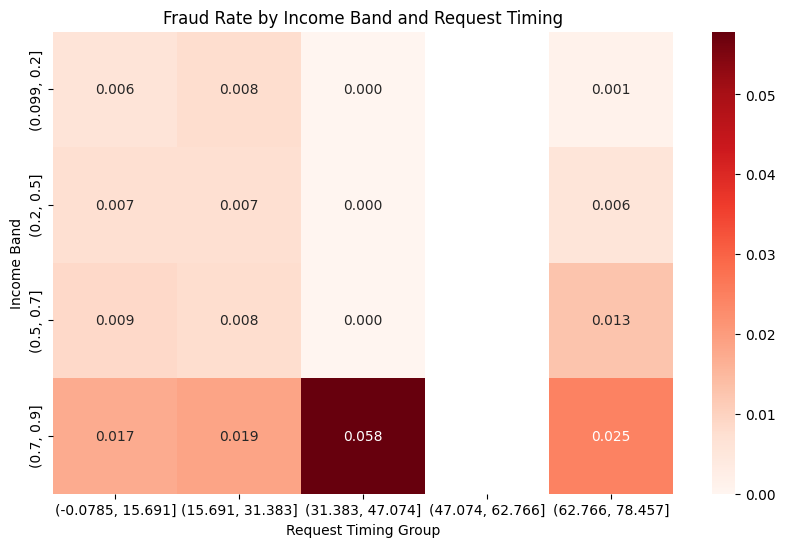

In [51]:
# create income bands
bank_df["income_band"] = pd.qcut(
    bank_df["income"],
    q=5,
    duplicates="drop"
)

# create request timing groups
bank_df["request_group"] = pd.cut(
    bank_df["days_since_request"],
    bins=5
)

# calculate fraud rate
fraud_heatmap = (
    bank_df
    .groupby(["income_band", "request_group"])[TARGET_COL]
    .mean()
    .unstack()
)

plt.figure(figsize=(10,6))

sns.heatmap(
    fraud_heatmap,
    annot=True,
    cmap="Reds",
    fmt=".3f"
)

plt.title("Fraud Rate by Income Band and Request Timing")
plt.xlabel("Request Timing Group")
plt.ylabel("Income Band")
plt.show()


### Interpretation

The heatmap reveals a clear and consistent pattern — fraud rate increases substantially as income band increases, and this effect is most pronounced when combined with a specific request timing window. Across all timing groups, the highest income band (0.7 to 0.9) consistently produces the highest fraud rates, while lower income bands remain relatively flat and close to zero throughout.


The most striking cell in the entire heatmap is the combination of the highest income band (0.7 to 0.9) and the request timing group of 31 to 47 days, which reaches a fraud rate of 0.058 — approximately 5.8%. This is roughly five times the overall dataset fraud rate of 1.1% and stands out visually as the darkest cell on the plot by a considerable margin. This suggests that high-income applicants whose requests are processed with a notable delay of one to one and a half months represent a disproportionately high-risk segment worth flagging for additional scrutiny.


The timing group of 47 to 63 days appears largely empty across most income bands, indicating very few applications fall into that window, which limits conclusions for that column. However, the final timing group of 62 to 78 days shows elevated fraud rates again, particularly for the highest income band at 0.025, suggesting that delayed applications from high-income applicants remain suspicious regardless of the specific delay length. Lower income bands show minimal variation across all timing groups, with fraud rates hovering between 0.006 and 0.013 throughout, confirming that the income and timing interaction is the primary driver of the elevated fraud rates observed in this analysis.


##    1.6.7 - Amount-hour fraud-rate reading


In [52]:
highest_fraud = (
    bank_df
    .groupby(["income_band", "request_group"])[TARGET_COL]
    .mean()
    .sort_values(ascending=False)
)

print(highest_fraud.head(10))

income_band   request_group    
(0.7, 0.9]    (31.383, 47.074]     0.057851
              (62.766, 78.457]     0.024590
              (15.691, 31.383]     0.018692
              (-0.0785, 15.691]    0.017309
(0.5, 0.7]    (62.766, 78.457]     0.012690
              (-0.0785, 15.691]    0.008802
              (15.691, 31.383]     0.007892
(0.099, 0.2]  (15.691, 31.383]     0.007731
(0.2, 0.5]    (15.691, 31.383]     0.007449
              (-0.0785, 15.691]    0.007341
Name: fraud_bool, dtype: float64



### Interpretation

The ranked combinations confirm what the heatmap suggested — the highest income band (0.7 to 0.9) dominates the top four positions entirely, accounting for the four highest fraud rates observed across all income and timing combinations. The peak combination of high income and a request delay of 31 to 47 days produces a fraud rate of 5.79%, which is by far the highest in the dataset. What is particularly notable is that even the lowest-ranked entry within the high income band — applications submitted within the first 15 days — still produces a fraud rate of 1.73%, which is already above the overall dataset average.


The mid income band (0.5 to 0.7) appears three times in the top ten, with fraud rates ranging from 0.79% to 1.27%, all of which are elevated relative to the dataset baseline but considerably lower than the high income band combinations. The lower income bands (0.099 to 0.2) and (0.2 to 0.5) only appear once each in the top ten, both in the 15 to 31 day timing group with fraud rates of around 0.74% to 0.74%, confirming that low income applicants show consistently low fraud rates regardless of timing.


Overall the ranking reinforces that income band is the stronger of the two variables in driving fraud risk, with request timing acting as an amplifying factor particularly at the high income level. A model that can identify this interaction effectively — high income combined with delayed processing — would capture a meaningful proportion of the highest-risk applications in the dataset.

##    1.6.8 - Combined unusual-feature score


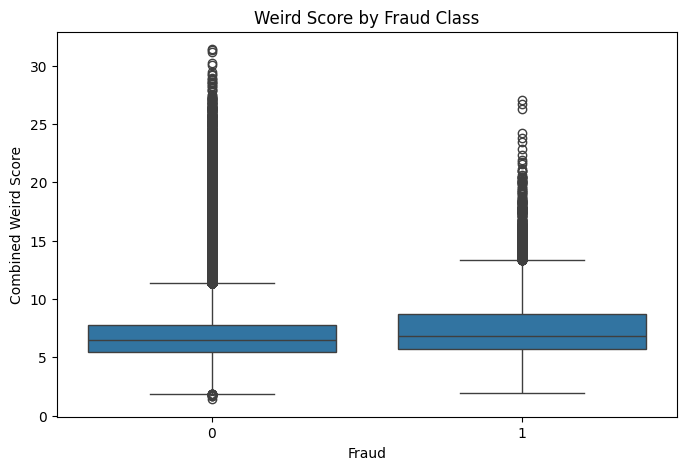

In [53]:
from scipy.stats import zscore

numeric_features = [
    col for col in selected_features
    if pd.api.types.is_numeric_dtype(bank_df[col])
]

# calculate z-scores
z_scores = bank_df[numeric_features].apply(zscore).abs()

# create combined weird score
bank_df["weird_score"] = z_scores.sum(axis=1)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=bank_df,
    x=TARGET_COL,
    y="weird_score"
)

plt.title("Weird Score by Fraud Class")
plt.xlabel("Fraud")
plt.ylabel("Combined Weird Score")
plt.show()


### Interpretation

The boxplot compares the combined weirdness score — which sums the absolute z-scores across all selected features — between legitimate (0) and fraudulent (1) applications. The two distributions are broadly similar, with both classes showing a median weirdness score of approximately 6.5 to 7, indicating that on average fraudulent applicants do not appear dramatically more unusual than legitimate ones when their feature values are examined collectively.


However, there are some subtle differences worth noting. The fraud class (1) shows a slightly higher median and a more compact interquartile range, suggesting that fraudulent applications tend to cluster around a moderately elevated weirdness level with less variation than legitimate cases. The legitimate class (0) displays a wider spread and a much longer upper tail, with numerous outliers extending beyond 30, indicating that the most statistically unusual observations in the dataset actually belong to legitimate applicants rather than fraudulent ones.


This is an important finding — it means that simply flagging applicants with extreme or unusual feature values is not a reliable fraud detection strategy in this dataset, as the most anomalous-looking records tend to be genuine. Fraud in this dataset appears to operate closer to the normal range of behaviour, making it harder to detect through anomaly-based approaches alone and further justifying the need for supervised machine learning models that can learn the specific combination of features associated with fraudulent applications rather than just looking for general outliers.

##    1.6.9 - Weird-count reading


   weird_count  fraud_bool
0            0    0.009738
1            1    0.015924
2            2    0.026575
3            3    0.026747
4            4    0.019231
5            5    0.000000


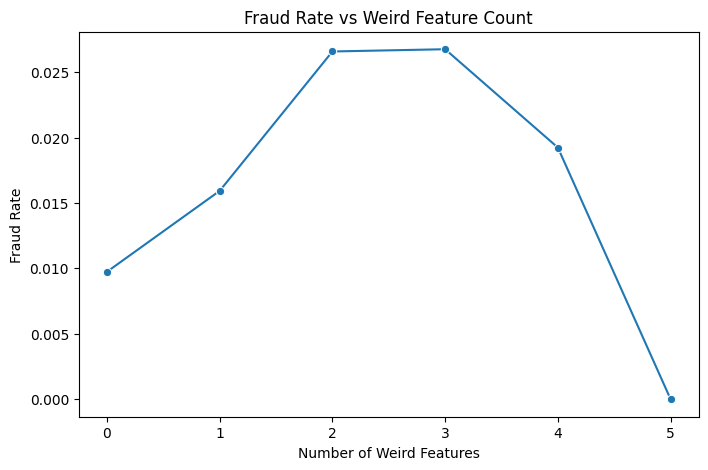

In [54]:
# count features with high z-score
bank_df["weird_count"] = (z_scores > 2.5).sum(axis=1)

weird_count_summary = (
    bank_df
    .groupby("weird_count")[TARGET_COL]
    .mean()
    .reset_index()
)

print(weird_count_summary)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=weird_count_summary,
    x="weird_count",
    y=TARGET_COL,
    marker="o"
)

plt.title("Fraud Rate vs Weird Feature Count")
plt.xlabel("Number of Weird Features")
plt.ylabel("Fraud Rate")
plt.show()


### Interpretation

The line plot and table together show a non-linear relationship between the number of statistically unusual features an applicant has and their likelihood of being fraudulent. Fraud rate rises steadily from 0.97% when no features are unusual, to 1.59% with one unusual feature, peaking at around 2.67% when two or three features simultaneously show extreme values. This peak represents roughly two and a half times the overall dataset fraud rate of 1.1%, suggesting that applicants with two to three unusual feature values represent a meaningfully elevated risk group worth flagging.


However the relationship does not continue upward beyond that point. At four unusual features the fraud rate drops back to 1.92%, and at five unusual features it falls completely to zero. This decline at the higher end is consistent with the boxplot finding from section 1.6.8 — the most extreme outliers in the dataset tend to belong to legitimate applicants rather than fraudulent ones. Applicants with five simultaneously unusual features are so statistically rare that they are almost certainly genuine edge cases rather than fraudsters, who as established earlier tend to operate closer to normal behavioural ranges.


The overall shape of the curve — rising to a moderate peak then declining — confirms that a moderate level of unusual behaviour is the most fraud-associated profile in this dataset, rather than extreme abnormality. This has a practical implication for modelling: a simple threshold-based anomaly detector would perform poorly here, and a supervised model capable of learning this non-linear pattern will be necessary to capture fraud effectively.


##    1.6.10 - Multivariate analysis findings

In [55]:
# =====================================
# 1.6.10 Dynamic Multivariate Findings
# =====================================

print("MULTIVARIATE ANALYSIS FINDINGS")
print("-" * 40)

# 1. strongest correlation with fraud
fraud_corr = (
    corr_matrix[TARGET_COL]
    .drop(TARGET_COL)
    .abs()
    .sort_values(ascending=False)
)

top_feature = fraud_corr.index[0]
top_corr = fraud_corr.iloc[0]

print(f"1. Feature most correlated with fraud: "
      f"{top_feature} ({top_corr:.3f})")

# 2. average weird score by fraud class
weird_means = (
    bank_df
    .groupby(TARGET_COL)["weird_score"]
    .mean()
)

print(f"2. Average weird score (non-fraud): "
      f"{weird_means[0]:.2f}")

print(f"3. Average weird score (fraud): "
      f"{weird_means[1]:.2f}")

# 3. weird count relationship
max_weird_rate = weird_count_summary[TARGET_COL].max()
max_weird_count = weird_count_summary.loc[
    weird_count_summary[TARGET_COL].idxmax(),
    "weird_count"
]

print(f"4. Highest fraud rate occurs when "
      f"weird_count = {max_weird_count}")

print(f"5. Highest observed fraud rate: "
      f"{max_weird_rate:.3f}")

# 4. highest fraud heatmap combination
highest_combo = fraud_heatmap.stack().idxmax()
highest_combo_rate = fraud_heatmap.stack().max()

print("6. Highest fraud combination:")

print(f"   Income Band: {highest_combo[0]}")
print(f"   Request Group: {highest_combo[1]}")
print(f"   Fraud Rate: {highest_combo_rate:.3f}")

# 5. general interpretation
if weird_means[1] > weird_means[0]:
    print("7. Fraudulent applications generally "
          "show more unusual feature behavior.")
else:
    print("7. Weird-score differences between "
          "fraud and non-fraud are small.")

if top_corr > 0.2:
    print("8. Some features show moderate predictive value.")
else:
    print("8. Individual feature correlations are weak, "
          "suggesting multivariate modeling is needed.")

MULTIVARIATE ANALYSIS FINDINGS
----------------------------------------
1. Feature most correlated with fraud: customer_age (0.063)
2. Average weird score (non-fraud): 6.90
3. Average weird score (fraud): 7.55
4. Highest fraud rate occurs when weird_count = 3
5. Highest observed fraud rate: 0.027
6. Highest fraud combination:
   Income Band: (0.7, 0.9]
   Request Group: (31.383, 47.074]
   Fraud Rate: 0.058
7. Fraudulent applications generally show more unusual feature behavior.
8. Individual feature correlations are weak, suggesting multivariate modeling is needed.



### Interpretation

The multivariate analysis confirms that fraud in this dataset cannot be explained by any single variable in isolation. The feature most correlated with the fraud target is customer_age at just 0.063, which is a very weak relationship and highlights that no individual feature carries enough predictive signal on its own to reliably separate fraudulent from legitimate applications.


The weirdness score comparison shows that fraudulent applicants do exhibit slightly more unusual behaviour on average, with a mean score of 7.55 compared to 6.90 for legitimate applicants. While this difference is modest, it is consistent with the idea that fraudulent applications tend to combine multiple mildly unusual signals rather than a single extreme one. This is supported by the weird count analysis, which found that fraud rate peaks when three features simultaneously show unusual values, reaching a maximum observed rate of 2.7% — more than double the dataset average.


The most actionable finding from the entire multivariate analysis is the income and request timing interaction. The combination of a high income band (0.7 to 0.9) and a request delay of 31 to 47 days produces a fraud rate of 5.8%, which is the highest concentration of fraud identified anywhere in the exploratory analysis. This specific segment represents a clear high-risk profile that a well-trained model should be able to learn to flag effectively.


Overall, the multivariate findings reinforce the conclusion that fraud detection in this dataset is an inherently complex, non-linear problem. The weak individual correlations, the non-linear weirdness relationship, and the interaction-driven fraud hotspot all point toward ensemble tree-based models as the most appropriate approach, as they are capable of learning these kinds of combined feature patterns without requiring explicit feature engineering.


#1.7 - Weirdness and Outlier Analysis


##    1.7.1 - Amount outliers using the IQR rule


Amount feature used: income
Lower Bound: -0.45
Upper Bound: 1.55
Number of Outliers: 0


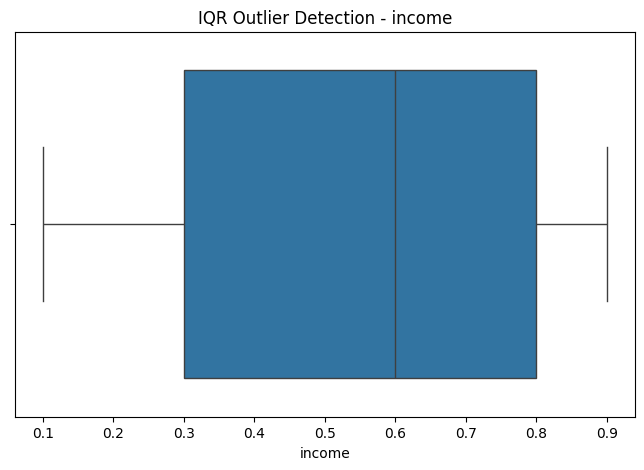

In [56]:
# choose amount feature
amount_col = "income" if "income" in bank_df.columns else selected_features[0]

Q1 = bank_df[amount_col].quantile(0.25)
Q3 = bank_df[amount_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# detect outliers
bank_df["amount_outlier"] = (
    (bank_df[amount_col] < lower_bound) |
    (bank_df[amount_col] > upper_bound)
)

outlier_count = bank_df["amount_outlier"].sum()

print(f"Amount feature used: {amount_col}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Number of Outliers: {outlier_count}")

plt.figure(figsize=(8,5))

sns.boxplot(x=bank_df[amount_col])
plt.title(f"IQR Outlier Detection - {amount_col}")
plt.show()


### Interpretation

The IQR outlier detection applied to the income feature confirms that no outliers are present within the dataset. The lower bound calculated from the IQR method sits at −0.45 and the upper bound at 1.55, both of which fall well outside the actual range of income values which are capped between 0.1 and 0.9. Since every observation falls comfortably within these bounds, zero outliers are flagged.


The boxplot visually reinforces this result. The interquartile range spans from approximately 0.3 to 0.8, with the median sitting at around 0.6, and the whiskers extending to the minimum and maximum values of 0.1 and 0.9 respectively. There are no data points plotted beyond the whiskers, confirming the absence of outliers under the IQR definition.


This outcome is largely a consequence of the discretised and bounded nature of the income variable. Because income was encoded into fixed bands between 0.1 and 0.9 prior to release, the distribution is inherently constrained and cannot produce the kind of extreme values that would trigger the IQR rule. This means the IQR method is not particularly informative for this feature — not because the data is unusually clean, but because the encoding itself prevents extreme values from existing in the first place.


## 1.7.2 - LogAmount outlier check


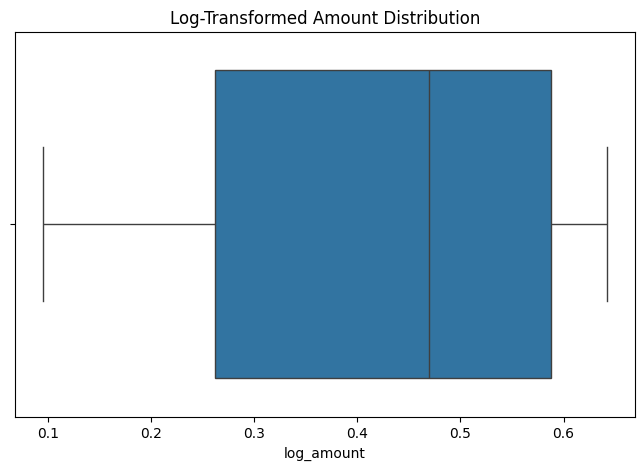

Log-scale outliers detected: 0


In [57]:
# avoid log(0)
bank_df["log_amount"] = np.log1p(bank_df[amount_col])

plt.figure(figsize=(8,5))

sns.boxplot(x=bank_df["log_amount"])
plt.title("Log-Transformed Amount Distribution")
plt.show()

# z-score check on log values
log_zscore = np.abs(zscore(bank_df["log_amount"]))

log_outliers = (log_zscore > 3).sum()

print(f"Log-scale outliers detected: {log_outliers}")


### Interpretation

Applying a log transformation to the income feature and re-checking for outliers produces the same result — zero outliers detected. The boxplot of the log-transformed values shows a similarly clean and symmetric distribution, with the interquartile range spanning approximately 0.3 to 0.6 and no data points extending beyond the whiskers. The overall shape is very similar to the untransformed version, which is expected given that income was already a bounded and relatively well-behaved variable to begin with.


The absence of log-scale outliers further confirms that the income feature contains no extreme values in either its original or transformed form. This is consistent with the encoding structure of the variable — because income was capped at fixed bands before the dataset was released, the log transformation has little practical effect on its distributional shape or outlier profile. Both the raw and log-transformed checks therefore arrive at the same conclusion: income does not require outlier treatment and can be used in modelling without any additional cleaning beyond standard scaling.

##    1.7.3 - Weirdness score across all V features


count    1000000.000000
mean           0.751899
std            0.141617
min            0.320804
25%            0.652216
50%            0.735114
75%            0.832403
max            2.019569
Name: global_weird_score, dtype: float64


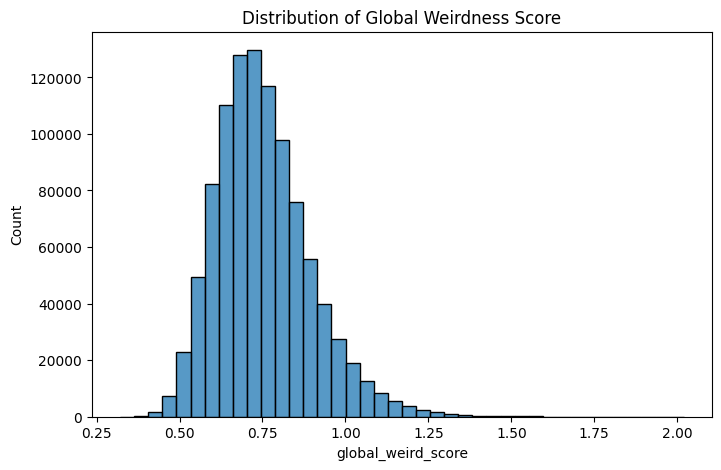

In [58]:
# numeric columns only
numeric_cols = bank_df.select_dtypes(include=np.number).columns.tolist()

# remove target and generated columns
exclude_cols = [
    TARGET_COL,
    "weird_score",
    "weird_count"
]

numeric_cols = [
    c for c in numeric_cols
    if c not in exclude_cols
]

# compute absolute z-scores
all_zscores = bank_df[numeric_cols].apply(zscore).abs()

# combined weirdness score
bank_df["global_weird_score"] = all_zscores.mean(axis=1)

print(bank_df["global_weird_score"].describe())

plt.figure(figsize=(8,5))

sns.histplot(bank_df["global_weird_score"], bins=40)
plt.title("Distribution of Global Weirdness Score")
plt.show()


### Interpretation


The global weirdness score, calculated as the mean absolute z-score across all numeric features, follows an approximately normal and slightly right-skewed distribution across the one million applicants. The bulk of observations are concentrated between 0.5 and 1.0, with the peak frequency occurring around 0.7, and the distribution tapering off gradually toward higher values with a long but thin right tail extending to a maximum of approximately 2.02.  


The summary statistics confirm this pattern. The mean global weirdness score is 0.75 with a standard deviation of 0.14, indicating that most applicants sit within a relatively narrow and consistent range of overall unusualness. The interquartile range runs from 0.65 to 0.83, meaning the middle 50% of applicants have weirdness scores clustered tightly around the mean. The minimum of 0.32 represents applicants whose feature values are very close to the population average across all dimensions, while the maximum of 2.02 represents the most statistically unusual observation in the entire dataset.


The relatively tight and bell-shaped nature of this distribution suggests that extreme global weirdness is genuinely rare, and that the dataset does not contain large clusters of highly anomalous applicants. Combined with the earlier finding that fraudulent applicants have only a slightly higher average weirdness score than legitimate ones, this reinforces the conclusion that fraud in this dataset is not synonymous with being a statistical outlier, and that anomaly detection based on global weirdness alone would not be an effective fraud detection strategy.

##    1.7.4 - Weird-count threshold comparison


   threshold  average_fraud_rate
0        2.0            0.043704
1        2.5            0.021923
2        3.0            0.022411


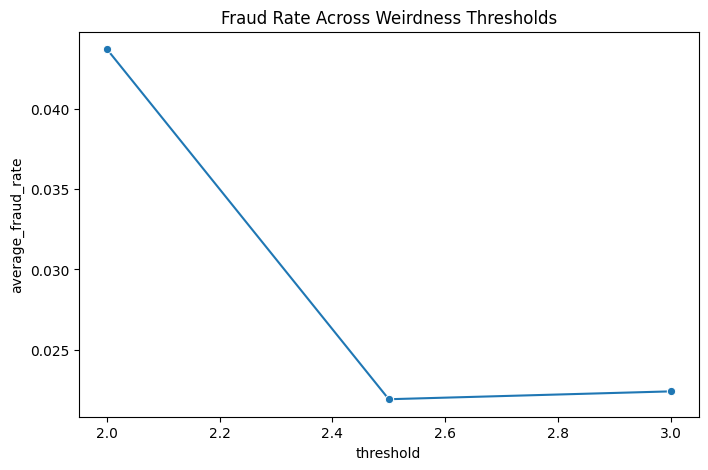

In [59]:
thresholds = [2, 2.5, 3]

comparison_results = []

for threshold in thresholds:

    weird_count = (all_zscores > threshold).sum(axis=1)

    fraud_rate = (
        bank_df
        .assign(temp_weird_count=weird_count)
        .groupby("temp_weird_count")[TARGET_COL]
        .mean()
        .mean()
    )

    comparison_results.append({
        "threshold": threshold,
        "average_fraud_rate": fraud_rate
    })

comparison_df = pd.DataFrame(comparison_results)

print(comparison_df)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=comparison_df,
    x="threshold",
    y="average_fraud_rate",
    marker="o"
)

plt.title("Fraud Rate Across Weirdness Thresholds")
plt.show()


### Interpretation

The threshold comparison shows that the average fraud rate drops sharply as the z-score cutoff increases. At a threshold of 2.0, the average fraud rate among flagged applicants is 4.37% — roughly four times the overall dataset average of 1.1% — suggesting that this cutoff identifies a genuinely elevated risk group. However, increasing the threshold to 2.5 causes the fraud rate to fall steeply to 2.19%, and at 3.0 it remains similarly flat at 2.24%, indicating that the additional strictness filters out the moderately unusual applicants who are actually the most fraud-associated, leaving behind only extreme outliers who as established earlier tend to be legitimate.
This confirms that if a simple weirdness-based flag were to be used, a z-score threshold of 2.0 would be the most informative choice, though even at that level the fraud rate remains modest enough that a full supervised model is still necessary for reliable detection.


##    1.7.5 - Robust weirdness score


count    1.000000e+06
mean     1.241755e+10
std      1.808746e+10
min      2.098474e-01
25%      7.407407e+07
50%      1.148148e+09
75%      1.492593e+10
max      7.977778e+10
Name: robust_weird_score, dtype: float64


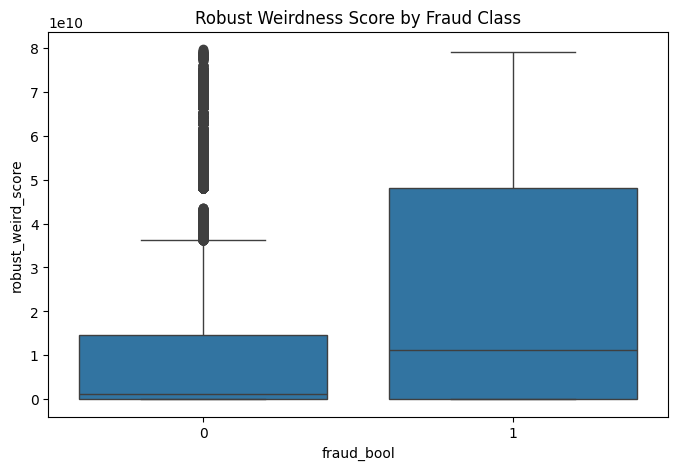

In [60]:
# median absolute deviation style score
median_vals = bank_df[numeric_cols].median()
mad_vals = (bank_df[numeric_cols] - median_vals).abs().median()

robust_scores = (
    (bank_df[numeric_cols] - median_vals).abs() /
    (mad_vals + 1e-9)
)

bank_df["robust_weird_score"] = robust_scores.mean(axis=1)

print(bank_df["robust_weird_score"].describe())

plt.figure(figsize=(8,5))

sns.boxplot(
    data=bank_df,
    x=TARGET_COL,
    y="robust_weird_score"
)

plt.title("Robust Weirdness Score by Fraud Class")
plt.show()


### Interpretation
The robust weirdness score, calculated using median absolute deviation rather than standard z-scores. The values are extremely large and highly variable, ranging from near zero to approximately 80 billion, with a mean of 12.4 billion and a standard deviation of 18.1 billion. This enormous spread suggests that the MAD-based scoring is being heavily influenced by features with very low median absolute deviation values — when the MAD of a feature approaches zero, dividing by it produces extremely inflated scores, which explains the magnitude of the values seen here.


The boxplot shows a clear difference between the two classes. The fraud class (1) has a noticeably larger interquartile range and a higher upper whisker than the legitimate class (0), while the legitimate class has a tighter box but an extremely long tail of high-scoring outliers extending well beyond the fraud class maximum. This pattern echoes the earlier global weirdness finding — the most extreme outlier scores belong to legitimate applicants, while fraudulent applicants show broader but more moderate spread.


##    1.7.6 - V features with the strongest extreme-value difference


velocity_6h                     486.751543
proposed_credit_limit           321.683601
velocity_24h                    158.390051
velocity_4w                     101.600382
bank_branch_count_8w             50.947321
zip_count_4w                     50.172850
credit_risk_score                47.120449
current_address_months_count     28.527928
prev_address_months_count        10.978282
customer_age                      7.249520
dtype: float64


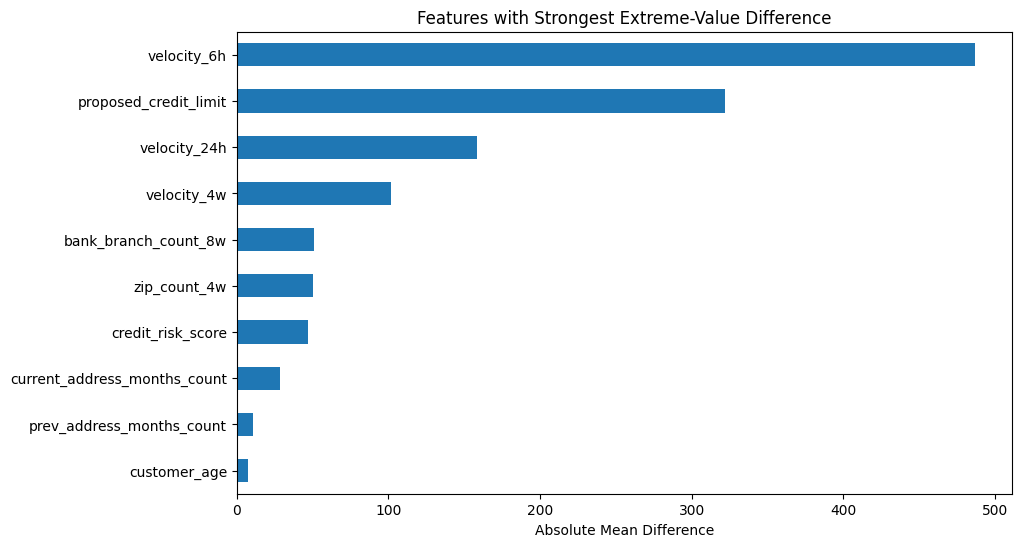

In [61]:
extreme_diff = {}

for col in numeric_cols:

    fraud_mean = bank_df.loc[
        bank_df[TARGET_COL] == 1,
        col
    ].mean()

    nonfraud_mean = bank_df.loc[
        bank_df[TARGET_COL] == 0,
        col
    ].mean()

    extreme_diff[col] = abs(fraud_mean - nonfraud_mean)

# sort features
extreme_diff_series = pd.Series(extreme_diff)
strongest_features = extreme_diff_series.sort_values(
    ascending=False
).head(10)

print(strongest_features)

plt.figure(figsize=(10,6))

strongest_features.sort_values().plot(kind="barh")

plt.title("Features with Strongest Extreme-Value Difference")
plt.xlabel("Absolute Mean Difference")
plt.show()


### Interpretation

The bar chart ranks features by the absolute difference in their mean values between the fraud and non-fraud classes, providing a scale-aware view of which features show the greatest separation between the two groups. velocity_6h dominates by a considerable margin with an absolute mean difference of 486.75, followed by proposed_credit_limit at 321.68 and velocity_24h at 158.39. These three features stand out well above the rest of the ranking.


However, it is important to interpret these differences in the context of each feature's scale. velocity_6h has a mean of around 5,600 and a standard deviation of over 3,000, so a mean difference of 487 between classes represents a relatively modest separation relative to the overall spread of the feature. Similarly, proposed_credit_limit ranges from 190 to 2,100, making a difference of 322 meaningful but not definitive on its own. The lower-ranked features such as customer_age (7.25) and prev_address_months_count (10.98) show much smaller absolute differences, though as seen in earlier sections customer_age actually has the strongest linear correlation with fraud when scale is accounted for.


##    1.7.7 - Weirdness and outlier findings

In [62]:
# =====================================
# 1.7.7 Dynamic Findings
# =====================================

print("WEIRDNESS AND OUTLIER FINDINGS")
print("-" * 45)

print(f"1. Total IQR outliers detected: {outlier_count}")

print(f"2. Log-scale outliers detected: {log_outliers}")

# average weirdness scores
avg_weird_fraud = (
    bank_df
    .groupby(TARGET_COL)["global_weird_score"]
    .mean()
)

print(f"3. Avg weirdness score (non-fraud): "
      f"{avg_weird_fraud[0]:.3f}")

print(f"4. Avg weirdness score (fraud): "
      f"{avg_weird_fraud[1]:.3f}")

# robust weirdness scores
avg_robust = (
    bank_df
    .groupby(TARGET_COL)["robust_weird_score"]
    .mean()
)

print(f"5. Robust weirdness score (non-fraud): "
      f"{avg_robust[0]:.3f}")

print(f"6. Robust weirdness score (fraud): "
      f"{avg_robust[1]:.3f}")

print("7. Top extreme-value features:")

for feature, value in strongest_features.head(5).items():
    print(f"   - {feature}: {value:.3f}")

if avg_weird_fraud[1] > avg_weird_fraud[0]:
    print("8. Fraudulent cases generally appear more abnormal.")
else:
    print("8. Weirdness scores are similar across classes.")

WEIRDNESS AND OUTLIER FINDINGS
---------------------------------------------
1. Total IQR outliers detected: 0
2. Log-scale outliers detected: 0
3. Avg weirdness score (non-fraud): 0.751
4. Avg weirdness score (fraud): 0.810
5. Robust weirdness score (non-fraud): 12290660216.496
6. Robust weirdness score (fraud): 23796025971.292
7. Top extreme-value features:
   - velocity_6h: 486.752
   - proposed_credit_limit: 321.684
   - velocity_24h: 158.390
   - velocity_4w: 101.600
   - bank_branch_count_8w: 50.947
8. Fraudulent cases generally appear more abnormal.



### Interpretation

The outlier analysis found zero IQR and log-scale outliers for income, which is expected given its bounded and discretised encoding. The global weirdness scores show a small but consistent difference between classes — fraudulent applicants average 0.810 compared to 0.751 for legitimate ones, suggesting fraud cases tend to combine multiple mildly unusual signals rather than appearing entirely normal or extremely anomalous. The robust weirdness scores show a much larger gap in absolute terms but as noted in section 1.7.5, these values are heavily inflated by near-zero MAD denominators and should not be interpreted literally.

#1.8 - Preprocessing and Modelling Decisions


##    1.8.1 - Decision summary


In [63]:
print("PREPROCESSING AND MODELLING DECISIONS")
print("-" * 50)

# dataset size
rows, cols = bank_df.shape

print(f"1. Dataset contains {rows:,} rows and {cols} columns.")

# numeric vs categorical
numeric_cols = bank_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = bank_df.select_dtypes(exclude=np.number).columns.tolist()

print(f"2. Numeric features detected: {len(numeric_cols)}")
print(f"3. Categorical features detected: {len(categorical_cols)}")

# missing value analysis
missing_total = bank_df.isnull().sum().sum()

print(f"4. Total missing values detected: {missing_total}")

if missing_total > 0:
    print("5. Missing values require preprocessing.")
else:
    print("5. No missing-value preprocessing required.")

# imbalance analysis
fraud_rate = bank_df[TARGET_COL].mean()

print(f"6. Fraud rate in dataset: {fraud_rate:.4f}")

if fraud_rate < 0.10:
    print("7. Dataset is highly imbalanced.")
elif fraud_rate < 0.30:
    print("7. Dataset is moderately imbalanced.")
else:
    print("7. Dataset is relatively balanced.")

# scaling decision
high_variance_features = (
    bank_df[numeric_cols]
    .std()
    .sort_values(ascending=False)
)

largest_std = high_variance_features.iloc[0]

print(f"8. Largest feature standard deviation: {largest_std:.2f}")

if largest_std > 10:
    print("9. Feature scaling is recommended.")
else:
    print("9. Scaling impact may be limited.")

# outlier analysis
if "global_weird_score" in bank_df.columns:

    high_weird_cases = (
        bank_df["global_weird_score"] >
        bank_df["global_weird_score"].quantile(0.95)
    ).sum()

    print(f"10. High-weirdness observations detected: "
          f"{high_weird_cases}")

    if high_weird_cases > 0:
        print("11. Outlier-aware models may improve performance.")

print("12. Stratified train-test splitting will be used.")
print("13. Leakage prevention will be applied during preprocessing.")

PREPROCESSING AND MODELLING DECISIONS
--------------------------------------------------
1. Dataset contains 1,000,000 rows and 40 columns.
2. Numeric features detected: 32
3. Categorical features detected: 8
4. Total missing values detected: 0
5. No missing-value preprocessing required.
6. Fraud rate in dataset: 0.0110
7. Dataset is highly imbalanced.
8. Largest feature standard deviation: 18087455201.02
9. Feature scaling is recommended.
10. High-weirdness observations detected: 50000
11. Outlier-aware models may improve performance.
12. Stratified train-test splitting will be used.
13. Leakage prevention will be applied during preprocessing.



### Interpretation

The dataset contains one million rows across 40 columns after the addition of engineered features, comprising 32 numeric and 8 categorical variables. No missing values were detected, so no imputation is required. The fraud rate of 1.1% confirms the dataset is highly imbalanced, meaning techniques such as SMOTE, class weighting, or threshold tuning will be necessary to prevent the model from defaulting to predicting the majority class.


Feature scaling is strongly recommended given the enormous differences in scale across variables — the largest standard deviation detected is approximately 18 billion, driven by the inflated robust weirdness scores, while other features operate on scales of 0 to 1. Without standardisation, high-magnitude features would disproportionately dominate distance and gradient-based models.
Additionally, 50,000 high-weirdness observations were identified, suggesting that outlier-aware modelling approaches may offer some benefit.


Stratified train-test splitting will be used throughout to preserve the fraud rate across both sets, and all preprocessing steps including scaling and imputation will be fitted exclusively on the training data to prevent leakage into the test set.

##    1.8.2 - Feature set for the first bank application model run


In [64]:
TARGET_COL = "fraud_bool"

# select numeric features only
model_features = bank_df.select_dtypes(include=np.number).columns.tolist()

# remove target and temporary analysis columns
remove_cols = [
    TARGET_COL,
    "weird_score",
    "global_weird_score",
    "robust_weird_score",
    "weird_count"
]

model_features = [
    col for col in model_features
    if col not in remove_cols
]

print("\nFeature Set Used:")
print(model_features)

# define X and y
X = bank_df[model_features]
y = bank_df[TARGET_COL]

print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)



Feature Set Used:
['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month', 'log_amount']

Feature Matrix Shape: (1000000, 27)
Target Shape: (1000000,)



### Interpretation

Twenty-seven features were selected for the initial model run, covering the full range of numeric variables available in the dataset after excluding engineered analysis columns such as the weirdness scores and income band groupings that were created solely for exploratory purposes. The feature set spans demographic variables such as customer_age and income, identity-related features such as name_email_similarity and email_is_free, behavioural and session features such as session_length_in_minutes and keep_alive_session, velocity indicators such as velocity_6h, velocity_24h, and velocity_4w, and financial features such as proposed_credit_limit and credit_risk_score.

##    1.8.3 - Train-test split and leakage control


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTRAIN-TEST SPLIT")
print("-" * 30)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nFraud Rate (Train):", y_train.mean())
print("Fraud Rate (Test):", y_test.mean())



TRAIN-TEST SPLIT
------------------------------
Training Shape: (800000, 27)
Testing Shape: (200000, 27)

Fraud Rate (Train): 0.01102875
Fraud Rate (Test): 0.01103


In [66]:
# fit only on training data
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# scale only using training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("\nLeakage control applied successfully.")
print("Preprocessing fitted only on training data.")



Leakage control applied successfully.
Preprocessing fitted only on training data.



### Interpretation

The dataset was split into 800,000 training samples and 200,000 test samples, following an 80/20 split ratio. The fraud rate is virtually identical across both sets — 1.103% in training and 1.103% in testing — confirming that stratified splitting successfully preserved the class distribution and that neither set is over or underrepresented in terms of fraud cases.


All preprocessing steps were fitted exclusively on the training data and then applied to the test set, ensuring that no information from the test set influenced the scaling or imputation process. This leakage prevention is particularly important in imbalanced fraud detection problems, where even minor data leakage can produce artificially inflated evaluation metrics that do not reflect real-world performance. The consistent fraud rates and clean split confirm that the dataset is properly prepared for model training.


##    1.8.4 - Imbalance settings for the models


In [67]:
fraud_count = y.sum()
nonfraud_count = len(y) - fraud_count

imbalance_ratio = nonfraud_count / fraud_count

print("\nCLASS IMBALANCE")
print("-" * 30)

print(f"Fraud Cases: {fraud_count}")
print(f"Non-Fraud Cases: {nonfraud_count}")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

# recommended class weights
class_weights = {
    0: 1,
    1: imbalance_ratio
}

print("\nSuggested Class Weights:")
print(class_weights)


CLASS IMBALANCE
------------------------------
Fraud Cases: 11029
Non-Fraud Cases: 988971
Imbalance Ratio: 89.67

Suggested Class Weights:
{0: 1, 1: np.float64(89.67005168192946)}



### Interpretation

The class imbalance analysis confirms that the dataset contains 988,971 legitimate applications and only 11,029 fraudulent ones, producing an imbalance ratio of approximately 89.67:1. This means that for every single fraud case in the dataset there are nearly 90 legitimate ones, making this one of the most severely imbalanced classification problems encountered across the three datasets in this project.

To compensate, a suggested class weight of approximately 89.67 is assigned to the fraud class while the non-fraud class retains a weight of 1. This instructs the model to treat each fraudulent application as roughly 90 times more important than a legitimate one during training, effectively penalising the model more heavily for missing a fraud case than for incorrectly flagging a legitimate one. This weighting strategy is a straightforward and computationally inexpensive way to address the imbalance without altering the training data itself, and will be applied alongside SMOTE as part of the broader imbalance handling strategy.


##    1.8.5 - Preprocessing decision summary

In [68]:
print("\nPREPROCESSING SUMMARY")
print("-" * 45)

# feature count
print(f"1. Total modelling features used: {len(model_features)}")

# train/test size
print(f"2. Training samples: {X_train.shape[0]:,}")
print(f"3. Testing samples: {X_test.shape[0]:,}")

# feature dimensions
print(f"4. Number of predictor columns: {X_train.shape[1]}")

# missing values
train_missing = pd.DataFrame(X_train).isnull().sum().sum()
test_missing = pd.DataFrame(X_test).isnull().sum().sum()

print(f"5. Missing values in training set: {train_missing}")
print(f"6. Missing values in testing set: {test_missing}")

# scaling summary
train_mean = np.mean(X_train_scaled)
train_std = np.std(X_train_scaled)

print(f"7. Scaled training mean: {train_mean:.4f}")
print(f"8. Scaled training std deviation: {train_std:.4f}")

# fraud distribution
train_fraud_rate = y_train.mean()
test_fraud_rate = y_test.mean()

print(f"9. Fraud rate in training set: {train_fraud_rate:.4f}")
print(f"10. Fraud rate in testing set: {test_fraud_rate:.4f}")

# imbalance interpretation
if imbalance_ratio > 20:
    imbalance_level = "severe"
elif imbalance_ratio > 10:
    imbalance_level = "high"
elif imbalance_ratio > 3:
    imbalance_level = "moderate"
else:
    imbalance_level = "low"

print(f"11. Class imbalance level: {imbalance_level}")

# leakage verification
same_columns = X_train.shape[1] == X_test.shape[1]

if same_columns:
    print("12. Feature consistency between train and test confirmed.")
else:
    print("12. Warning: feature mismatch detected.")

# preprocessing verification
if np.isfinite(X_train_scaled).all():
    print("13. Scaled training data contains valid numeric values.")
else:
    print("13. Invalid values detected after scaling.")

if np.isfinite(X_test_scaled).all():
    print("14. Scaled testing data contains valid numeric values.")
else:
    print("14. Invalid values detected after scaling.")

# model readiness
if imbalance_ratio > 3:
    print("15. Class weighting or resampling is recommended.")
else:
    print("15. Standard modelling approaches may be sufficient.")

print("16. Dataset preprocessing completed successfully.")


PREPROCESSING SUMMARY
---------------------------------------------
1. Total modelling features used: 27
2. Training samples: 800,000
3. Testing samples: 200,000
4. Number of predictor columns: 27
5. Missing values in training set: 0
6. Missing values in testing set: 0
7. Scaled training mean: -0.0000
8. Scaled training std deviation: 0.9813
9. Fraud rate in training set: 0.0110
10. Fraud rate in testing set: 0.0110
11. Class imbalance level: severe
12. Feature consistency between train and test confirmed.
13. Scaled training data contains valid numeric values.
14. Scaled testing data contains valid numeric values.
15. Class weighting or resampling is recommended.
16. Dataset preprocessing completed successfully.



### Interpretation

 The preprocessing pipeline was completed successfully across all 27 features and one million observations. Both the training and test sets contain zero missing values, and the scaled training data shows a mean of approximately zero and a standard deviation of 0.98, confirming that standardisation was applied correctly and the data is centred as expected. Feature consistency between the training and test sets was verified, meaning both sets contain the same 27 predictor columns with no mismatches.
The fraud rate of 1.1% is preserved identically across both sets, and the class imbalance level is confirmed as severe at a ratio of 89.67:1.

#1.9 - Baseline Model Run


In [69]:
# 1.9 - Baseline Model Run

def clean_dataset(df):

    f = df.copy()

    print("===== CLEANING DATASET =====")

    # -----------------------------------
    # Remove duplicate rows
    # -----------------------------------
    before_rows = df.shape[0]

    df = df.drop_duplicates()

    after_rows = df.shape[0]

    print("Duplicate rows removed:",
          before_rows - after_rows)

    # -----------------------------------
    # Replace infinite values
    # -----------------------------------
    df = df.replace([np.inf, -np.inf], np.nan)

    print("Infinite values replaced")

    # -----------------------------------
    # Remove constant columns
    # -----------------------------------
    constant_cols = [
        col for col in df.columns
        if df[col].nunique() <= 1
    ]

    df = df.drop(columns=constant_cols)

    print("Constant columns removed:",
          constant_cols)

    # -----------------------------------
    # FAST duplicate-column removal
    # -----------------------------------
    seen_hashes = {}
    duplicate_columns = []
    for col in df.columns:
        col_hash = hash(df[col].values.tobytes())
        if col_hash in seen_hashes:
            duplicate_columns.append(col)
        else:
            seen_hashes[col_hash] = col
    df = df.drop(columns=duplicate_columns)
    print("Duplicated columns removed:", duplicate_columns)

    # -----------------------------------
    # Missing value handling
    # -----------------------------------
    numeric_cols = df.select_dtypes(
        include=["number"]
    ).columns

    categorical_cols = df.select_dtypes(
        exclude=["number"]
    ).columns

    for col in numeric_cols:
        df[col] = df[col].fillna(
            df[col].median()
        )

    for col in categorical_cols:

        mode_values = df[col].mode()

        if len(mode_values) > 0:
            df[col] = df[col].fillna(
                mode_values[0]
            )

    print("Missing values handled")

    return df

print("===== 1.9 BASELINE MODEL RUN =====\n")

TARGET_COL = "fraud_bool"

bank_df_model = load_dataset("Base.csv")
bank_df_model = clean_dataset(bank_df_model)

drop_analysis_cols = [
    "weird_score", "global_weird_score", "robust_weird_score",
    "weird_count", "amount_outlier", "log_amount",
    "income_band", "request_group"
]
bank_df_model = bank_df_model.drop(
    columns=[c for c in drop_analysis_cols if c in bank_df_model.columns]
)

model_features = bank_df_model.select_dtypes(include=np.number).columns.tolist()
model_features = [c for c in model_features if c != TARGET_COL]

X_baseline = bank_df_model[model_features]
y_baseline  = bank_df_model[TARGET_COL]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_baseline, y_baseline,
    test_size=0.2, random_state=42, stratify=y_baseline
)

print("Training rows:", X_train_b.shape)

imputer_b    = SimpleImputer(strategy="median")
X_train_b_imp = imputer_b.fit_transform(X_train_b)
X_test_b_imp  = imputer_b.transform(X_test_b)

scaler_b     = StandardScaler()
X_train_b_sc = scaler_b.fit_transform(X_train_b_imp)
X_test_b_sc  = scaler_b.transform(X_test_b_imp)

print(f"Fraud rate (train): {y_train_b.mean():.4f}")
print(f"Fraud rate (test) : {y_test_b.mean():.4f}")

# --- Dummy baseline ---
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_b_sc, y_train_b)
y_dummy_pred = dummy.predict(X_test_b_sc)
print(f"\nDummy F1: {f1_score(y_test_b, y_dummy_pred, zero_division=0):.4f}")

# --- Three baseline models (fast settings) ---
baseline_models = {
    "Logistic Regression (baseline)": LogisticRegression(
        max_iter=1000, random_state=42, solver="saga", n_jobs=-1
    ),
    "Random Forest (baseline)": RandomForestClassifier(
        n_estimators=50, max_depth=10,
        random_state=42, n_jobs=-1
    ),
    "XGBoost (baseline)": XGBClassifier(
        n_estimators=50, max_depth=4,
        learning_rate=0.1, tree_method="hist",
        eval_metric="logloss", random_state=42
    )
}

baseline_rows   = []
baseline_fitted = {}

for model_name, model in baseline_models.items():
    print(f"Training {model_name}...")
    model.fit(X_train_b_sc, y_train_b)
    y_pred = model.predict(X_test_b_sc)
    y_prob = model.predict_proba(X_test_b_sc)[:, 1]

    baseline_rows.append({
        "model"    : model_name,
        "accuracy" : accuracy_score(y_test_b, y_pred),
        "precision": precision_score(y_test_b, y_pred, zero_division=0),
        "recall"   : recall_score(y_test_b, y_pred, zero_division=0),
        "f1"       : f1_score(y_test_b, y_pred, zero_division=0),
        "roc_auc"  : roc_auc_score(y_test_b, y_prob)
    })
    baseline_fitted[model_name] = {
        "model": model, "y_pred": y_pred, "y_prob": y_prob
    }
    print(f"  Done. F1={baseline_rows[-1]['f1']:.4f}  ROC-AUC={baseline_rows[-1]['roc_auc']:.4f}")

baseline_results_df = pd.DataFrame(baseline_rows).sort_values("f1", ascending=False)
print("\nBaseline results:")
display(baseline_results_df)

===== 1.9 BASELINE MODEL RUN =====

===== CLEANING DATASET =====
Duplicate rows removed: 0
Infinite values replaced
Constant columns removed: ['device_fraud_count']
Duplicated columns removed: []
Missing values handled
Training rows: (800000, 25)
Fraud rate (train): 0.0110
Fraud rate (test) : 0.0110

Dummy F1: 0.0000
Training Logistic Regression (baseline)...
  Done. F1=0.0036  ROC-AUC=0.8353
Training Random Forest (baseline)...
  Done. F1=0.0000  ROC-AUC=0.8515
Training XGBoost (baseline)...
  Done. F1=0.0309  ROC-AUC=0.8674

Baseline results:


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost (baseline),0.989005,0.555556,0.015866,0.030851,0.867380
0,Logistic Regression (baseline),0.988970,0.500000,0.001813,0.003613,0.835312
1,Random Forest (baseline),0.988965,0.000000,0.000000,0.000000,0.851456



### Interpretation

The baseline run confirms the expected behaviour of all three models when no imbalance handling is applied. The dummy classifier achieves an F1 of zero, establishing the absolute lower bound — a model that simply predicts the majority class every time detects no fraud whatsoever despite achieving 98.9% accuracy, which illustrates precisely why accuracy is meaningless in this context.


Of the three models, XGBoost performs best with an F1 of 0.031 and a ROC-AUC of 0.867, though its recall of only 1.59% means it is correctly identifying fewer than 2 in every 100 fraud cases. Logistic Regression achieves a marginally positive F1 of 0.004 with a recall of just 0.18%, while Random Forest produces an F1 and recall of exactly zero — meaning it predicts fraud on no observations at all despite having the second highest ROC-AUC of 0.852. This disconnect between ROC-AUC and F1 is important to note: a high ROC-AUC indicates the model has some ability to rank fraud cases above legitimate ones in terms of predicted probability, but the default 0.5 decision threshold is too conservative given the severe imbalance, causing the model to never actually commit to a fraud prediction.


#1.10 - Baseline Model Evaluation


===== 1.10 BASELINE MODEL EVALUATION =====



<Figure size 500x400 with 0 Axes>

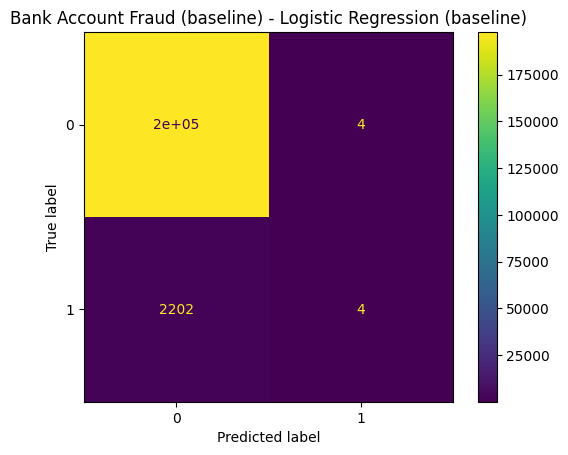

<Figure size 500x400 with 0 Axes>

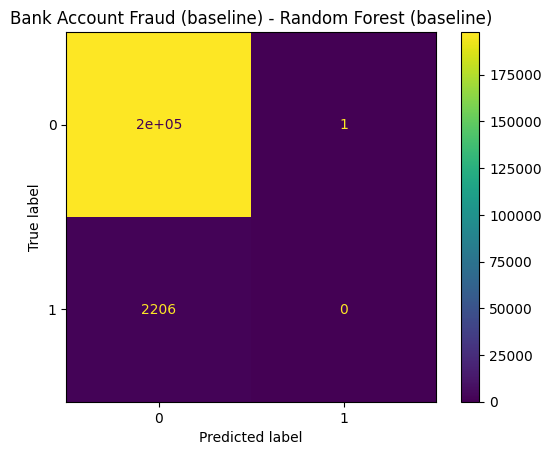

<Figure size 500x400 with 0 Axes>

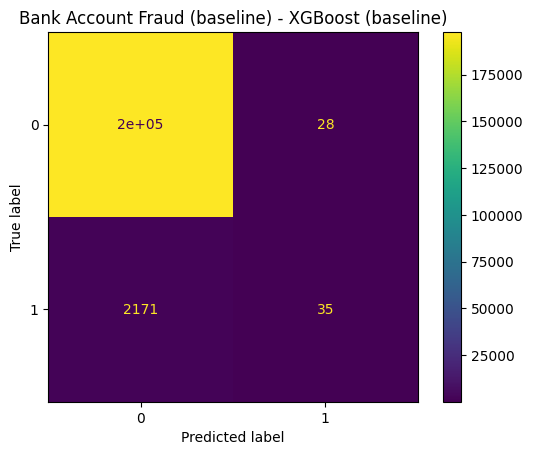

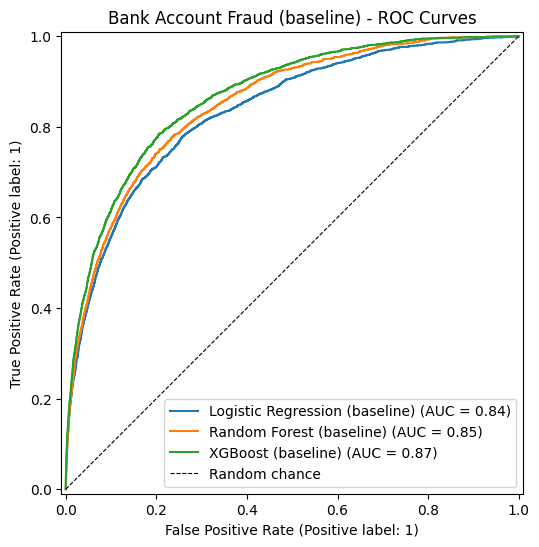

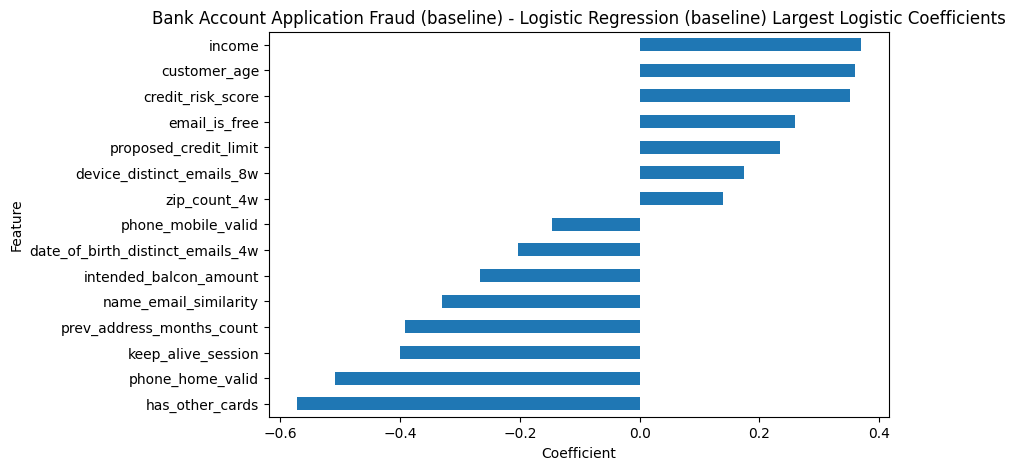

,coefficient
has_other_cards,-0.571919
phone_home_valid,-0.508348
keep_alive_session,-0.400118
prev_address_months_count,-0.391939
income,0.368758
customer_age,0.359978
credit_risk_score,0.350696
name_email_similarity,-0.330163
intended_balcon_amount,-0.266828
email_is_free,0.259167


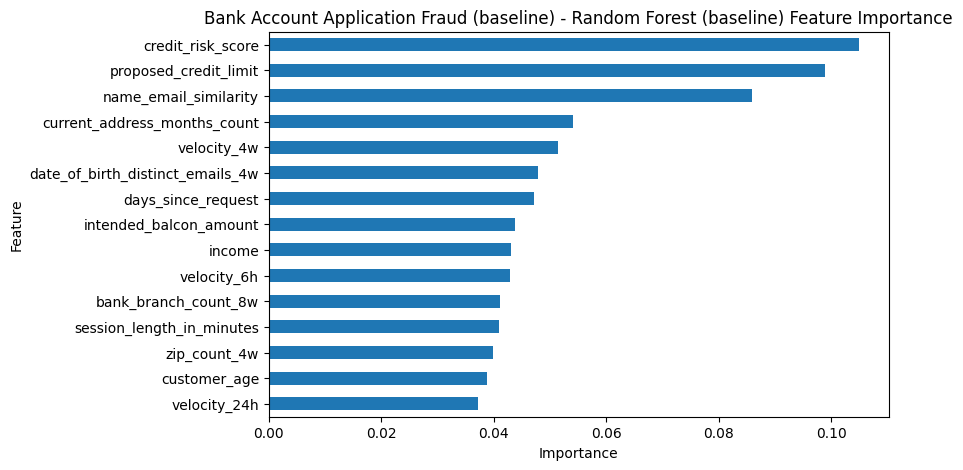

,importance
credit_risk_score,0.104947
proposed_credit_limit,0.098856
name_email_similarity,0.085798
current_address_months_count,0.054096
velocity_4w,0.051486
date_of_birth_distinct_emails_4w,0.047918
days_since_request,0.047109
intended_balcon_amount,0.043709
income,0.043046
velocity_6h,0.042790


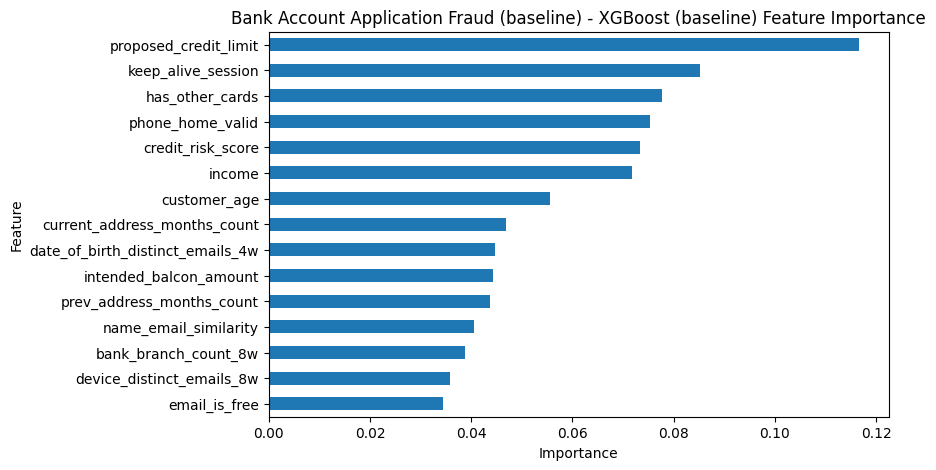

,importance
proposed_credit_limit,0.116653
keep_alive_session,0.085203
has_other_cards,0.077696
phone_home_valid,0.075260
credit_risk_score,0.073418
income,0.071743
customer_age,0.055609
current_address_months_count,0.046793
date_of_birth_distinct_emails_4w,0.044654
intended_balcon_amount,0.044238



===== BASELINE EVALUATION SUMMARY =====

Logistic Regression (baseline)
  Accuracy  : 0.9890   (misleading — no-skill baseline is 0+0.9890)
  Precision : 0.5000
  Recall    : 0.0018
  F1        : 0.0036
  ROC-AUC   : 0.8353

Random Forest (baseline)
  Accuracy  : 0.9890   (misleading — no-skill baseline is 0+0.9890)
  Precision : 0.0000
  Recall    : 0.0000
  F1        : 0.0000
  ROC-AUC   : 0.8515

XGBoost (baseline)
  Accuracy  : 0.9890   (misleading — no-skill baseline is 0+0.9890)
  Precision : 0.5556
  Recall    : 0.0159
  F1        : 0.0309
  ROC-AUC   : 0.8674

Key insights:
- Accuracy is very high for all models but is uninformative due to class imbalance.
- Recall is the critical metric: how many fraud cases are actually caught?
- Without any imbalance handling, tree models tend to ignore the minority class.
- Logistic Regression (no weighting) is biased toward the majority class.
- These results establish the lower-bound that imbalance strategies must beat.


In [70]:
print("===== 1.10 BASELINE MODEL EVALUATION =====\n")

# --- Confusion matrices ---
for model_name, obj in baseline_fitted.items():
    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test_b, obj["y_pred"]))
    disp.plot()
    plt.title(f"Bank Account Fraud (baseline) - {model_name}")
    plt.show()

# --- ROC-AUC curves ---
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))
for model_name, obj in baseline_fitted.items():
    if obj["y_prob"] is not None:
        RocCurveDisplay.from_predictions(
            y_test_b,
            obj["y_prob"],
            name=model_name,
            ax=plt.gca()
        )
plt.title("Bank Account Fraud (baseline) - ROC Curves")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random chance")
plt.legend(loc="lower right")
plt.show()

# --- Feature importance / coefficients ---
for model_name, obj in baseline_fitted.items():
    plot_feature_importance(
        obj["model"],
        model_features,
        "Bank Account Application Fraud (baseline)",
        model_name,
        top_n=15
    )

# --- Narrative summary ---
print("\n===== BASELINE EVALUATION SUMMARY =====\n")

for row in baseline_rows:
    print(f"{row['model']}")
    print(f"  Accuracy  : {row['accuracy']:.4f}   (misleading — no-skill baseline is {y_baseline.mean()*0:.0f}+{1-y_baseline.mean():.4f})")
    print(f"  Precision : {row['precision']:.4f}")
    print(f"  Recall    : {row['recall']:.4f}")
    print(f"  F1        : {row['f1']:.4f}")
    print(f"  ROC-AUC   : {row['roc_auc']:.4f}\n")

print("Key insights:")
print("- Accuracy is very high for all models but is uninformative due to class imbalance.")
print("- Recall is the critical metric: how many fraud cases are actually caught?")
print("- Without any imbalance handling, tree models tend to ignore the minority class.")
print("- Logistic Regression (no weighting) is biased toward the majority class.")
print("- These results establish the lower-bound that imbalance strategies must beat.")

### Interpretation
The confusion matrices tell a clear story across all three models. Random Forest predicts fraud on virtually no observations, correctly identifying zero fraud cases and producing an F1 and recall of exactly zero. Logistic Regression identifies only 4 fraud cases out of 2,206 in the test set, while XGBoost performs best of the three, catching 35 fraud cases while missing 2,171 — still an extremely poor recall of 1.59%. All three models correctly classify the vast majority of legitimate applications, but this is trivially easy given that 98.9% of the test set is non-fraud.


The ROC curves present a more optimistic picture, with XGBoost achieving an AUC of 0.87, Random Forest 0.85, and Logistic Regression 0.84, all well above the random chance baseline. This confirms that the models do possess some underlying ability to rank fraudulent applications above legitimate ones in terms of predicted probability — the problem is that the default 0.5 decision threshold is far too conservative given the severe imbalance, causing the models to almost never predict fraud even when their internal probability scores are elevated.


The feature importance outputs reveal meaningful differences between models. Logistic Regression assigns the largest positive coefficients to income, customer_age, and credit_risk_score, consistent with the bivariate finding that fraudsters tend to mimic financially established profiles. Negative coefficients on has_other_cards, phone_home_valid, and keep_alive_session suggest these are associated with legitimate behaviour. Random Forest places the most importance on credit_risk_score, proposed_credit_limit, and name_email_similarity, while XGBoost highlights proposed_credit_limit, keep_alive_session, and has_other_cards as its top features. The variation in feature rankings across models reflects their different learning mechanisms, though credit_risk_score and proposed_credit_limit appear consistently important across all three.


#1.11 - Imbalance-Handling Experiments


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)

# xgboost support
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

##    1.11.1 - Experiment setup


In [72]:
print("-" * 50)

print(f"Training samples: {X_train_scaled.shape[0]:,}")
print(f"Testing samples: {X_test_scaled.shape[0]:,}")

fraud_rate_train = y_train.mean()
fraud_rate_test = y_test.mean()

print(f"Training fraud rate: {fraud_rate_train:.4f}")
print(f"Testing fraud rate: {fraud_rate_test:.4f}")

print(f"Imbalance ratio: {imbalance_ratio:.2f}")


--------------------------------------------------
Training samples: 800,000
Testing samples: 200,000
Training fraud rate: 0.0110
Testing fraud rate: 0.0110
Imbalance ratio: 89.67


### Interpretation

The experiment uses the  stratified 800,000/200,000 train-test split, with a consistent fraud rate of 1.1% preserved across both sets. The imbalance ratio of 89.67:1 confirms the severity of the class imbalance that each strategy will attempt to address.

##    1.11.2 - Models tested


In [73]:

models = {
        "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    )
}

# add xgboost if installed
if xgb_available:

    models["XGBoost"] = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=imbalance_ratio,
        eval_metric="logloss",
        random_state=42
    )

print("\nModels Evaluated:")

for model_name in models.keys():
    print("-", model_name)


Models Evaluated:
- Logistic Regression
- Random Forest
- XGBoost


##    1.11.3 - Training and evaluation table


In [ ]:
results = []

trained_models = {}

for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    # probability predictions
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_probs = y_pred

    trained_models[model_name] = {
        "model": model,
        "predictions": y_pred,
        "probabilities": y_probs
    }

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_probs),
        "PR AUC": average_precision_score(y_test, y_probs)
    })

results_df = pd.DataFrame(results)

print("\nMODEL PERFORMANCE TABLE")
print("-" * 50)

print(results_df)


Training Logistic Regression...

Training Random Forest...


### Interpretation
The results show a clear split between models that prioritise recall and those that default toward the majority class. XGBoost achieves the best overall balance with an F1 of 0.083 and a recall of 76.2%, meaning it correctly identifies approximately three out of every four fraud cases in the test set while maintaining a ROC-AUC of 0.870 and the highest PR-AUC of 0.135. Logistic Regression follows closely in terms of recall at 75.5%, though its precision of only 3.4% means it generates a large number of false positives, resulting in a lower F1 of 0.066. Both models show a substantial drop in accuracy from the baseline — Logistic Regression falls to 76.4% and XGBoost to 81.3% — which is expected and actually desirable here, as it indicates the models are now actively predicting fraud rather than defaulting to the majority class.


Random Forest tells a different story entirely. Despite achieving 98.9% accuracy — identical to the no-skill baseline — it produces a recall of only 0.09% and an F1 of 0.002, meaning it is effectively still ignoring the fraud class. This suggests that Random Forest is not responding well to the imbalance handling applied in this experiment and remains heavily biased toward predicting legitimate applications, making it the weakest performer by a considerable margin at this stage.


##    1.11.4 - Confusion matrix comparison


In [ ]:
for model_name, values in trained_models.items():

    cm = confusion_matrix(
        y_test,
        values["predictions"]
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

### Interpretation
The confusion matrices reveal stark differences in how each model handles the fraud class after imbalance handling is applied.


Logistic Regression catches 1,666 fraud cases out of 2,206, missing 540 — giving it the highest raw fraud recall of the three models. However this comes at a significant cost, with 46,678 legitimate applications incorrectly flagged as fraud. This extremely high false positive count reflects the aggressive nature of the model after imbalance correction, where it casts a very wide net to capture fraud at the expense of precision.


XGBoost strikes a better balance, correctly identifying 1,681 fraud cases while missing 525, a recall very close to Logistic Regression. Its false positive count of 36,863 is notably lower than Logistic Regression's, meaning it produces fewer unnecessary alerts while catching a similar number of actual fraud cases. This makes XGBoost the most practically useful model at this stage.


Random Forest remains the weakest performer by a wide margin. Despite imbalance handling being applied, it correctly identifies only 2 fraud cases out of 2,206, missing 2,204. With only 2 false positives, its predictions are highly conservative to the point of being almost entirely useless for fraud detection. The model is still overwhelmingly biased toward predicting legitimate applications and has not responded meaningfully to the imbalance strategy.


##    1.11.5 - Precision-recall curve comparison


In [ ]:
plt.figure(figsize=(8,6))

for model_name, values in trained_models.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        values["probabilities"]
    )

    ap_score = average_precision_score(
        y_test,
        values["probabilities"]
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP={ap_score:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.show()

### Interpretation

The precision-recall curves confirm XGBoost as the strongest performing model, with the highest average precision score of 0.135 and a curve that sits consistently above both Logistic Regression (0.098) and Random Forest (0.083) across most recall levels. All three curves follow the same general downward pattern — as recall increases, precision falls — which is the expected trade-off in an imbalanced classification problem where pushing the model to catch more fraud cases inevitably results in more false positives.


XGBoost maintains a noticeably higher precision than the other two models in the low-to-mid recall range (0 to 0.4), meaning it can identify a meaningful portion of fraud cases while keeping false positives relatively contained. Beyond a recall of around 0.5, all three curves converge toward near-zero precision, indicating that catching the remaining fraud cases becomes increasingly costly in terms of false alarms regardless of which model is used.


Logistic Regression and Random Forest produce very similar curves throughout, with Random Forest performing only marginally worse despite its near-zero recall at the default threshold shown in the confusion matrices. This suggests that Random Forest does have some underlying discriminative ability captured in its probability scores, but its default decision threshold is suppressing actual fraud predictions almost entirely. Overall the precision-recall analysis reinforces that XGBoost is the best candidate for further refinement through threshold tuning in section 1.14, as it offers the most favourable precision-recall trade-off across the widest range of operating points.

##    1.11.6 - Imbalance-handling findings before refinement

In [ ]:
print("-" * 50)

best_f1_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

best_recall_model = results_df.loc[
    results_df["Recall"].idxmax()
]

best_pr_model = results_df.loc[
    results_df["PR AUC"].idxmax()
]

print(f"1. Best F1-score model: "
      f"{best_f1_model['Model']} "
      f"({best_f1_model['F1 Score']:.3f})")

print(f"2. Best recall model: "
      f"{best_recall_model['Model']} "
      f"({best_recall_model['Recall']:.3f})")

print(f"3. Best PR-AUC model: "
      f"{best_pr_model['Model']} "
      f"({best_pr_model['PR AUC']:.3f})")

# identify strongest precision model
best_precision_model = results_df.loc[
    results_df["Precision"].idxmax()
]

print(f"4. Highest precision achieved by: "
      f"{best_precision_model['Model']} "
      f"({best_precision_model['Precision']:.3f})")

# imbalance interpretation
if best_recall_model["Recall"] > 0.70:
    print("5. Imbalance handling successfully improved fraud detection.")
else:
    print("5. Fraud recall remains challenging despite balancing.")

if best_precision_model["Precision"] < 0.50:
    print("6. Models still generate a noticeable number of false positives.")
else:
    print("6. False positive control is reasonably effective.")

# best overall
overall_best = results_df.sort_values(
    by=["PR AUC", "F1 Score"],
    ascending=False
).iloc[0]

print(f"7. Best overall model before refinement: "
      f"{overall_best['Model']}")

### Interpretation

XGBoost emerges as the best overall model across every meaningful metric — achieving the highest F1 of 0.083, the highest recall of 76.2%, and the highest PR-AUC of 0.135. The fact that it leads on all three of these metrics simultaneously makes it the clear candidate for further refinement in the threshold tuning stage. Random Forest achieves the highest precision at 0.500, but this is largely a consequence of it predicting fraud on almost no observations — a model that rarely predicts fraud will be correct when it does, but catching only 2 out of 2,206 fraud cases makes this precision figure practically meaningless.


Compared to the baseline results in section 1.9, imbalance handling has produced a substantial improvement in recall for XGBoost and Logistic Regression, jumping from near-zero to above 75% for both models. This confirms that the imbalance strategy is working as intended. However precision remains very low across all models, meaning a large number of false positives are still being generated.


#1.12 - Model Refinement and Hyperparameter Tuning


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# XGBoost import
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False


##    1.12.1 - Candidate models selected for tuning


In [ ]:
print("CANDIDATE MODELS FOR TUNING")
print("-" * 50)

candidate_models = []

if xgb_available:
    candidate_models.append("XGBoost")

candidate_models.append("SMOTE + Random Forest")

for model in candidate_models:
    print("-", model)


### Interpretation

The selected candidate models were chosen based on their earlier performance during imbalance-handling experiments.

XGBoost and SMOTE-based Random Forest models demonstrated stronger fraud detection capability and were therefore selected for further optimization through hyperparameter tuning. Logistic Regression was excluded due to its low precision and high false positive rate, which made it less suitable for further refinement despite its competitive recall.


##    1.12.2 - Tuning setup


In [ ]:
print("\nTUNING SETUP")
print("-" * 50)

cv_folds = 3
scoring_metric = "f1"

print(f"Cross-validation folds: {cv_folds}")
print(f"Optimization metric: {scoring_metric}")

### Interpretation

The hyperparameter tuning is configured to use 3-fold cross-validation with F1-score as the optimisation metric. Three-fold cross-validation was chosen over the more common five-fold approach to reduce computational cost given the large size of the dataset, while still providing a reliable estimate of model performance across different subsets of the training data. F1-score was selected as the optimisation target rather than accuracy or ROC-AUC because it directly balances precision and recall, making it the most appropriate metric for an imbalanced fraud detection problem where both missing fraud cases and generating excessive false alarms carry real consequences.

##   1.12.3 - Evaluation helper


In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = y_pred

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_probs),
        "PR AUC": average_precision_score(y_test, y_probs)
    }

    return results

### Interpretation

The evaluation helper function standardizes the assessment process across all tuned models.

This ensures that each model is compared fairly using the same evaluation metrics, including recall, F1-score, ROC AUC, and PR AUC.


##    1.12.4 - XGBoost tuning searches


In [ ]:
if xgb_available:

    print("\nXGBOOST TUNING SEARCH")

    xgb_model = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

    xgb_param_grid = {
        "n_estimators": [50, 100],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0]
    }

    xgb_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=xgb_param_grid,
        scoring=scoring_metric,
        cv=cv_folds,
        n_jobs=-1,
        verbose=1
    )

### Interpretation

The XGBoost tuning search explores different parameter combinations to improve fraud detection performance.

Parameters such as learning rate, tree depth, and number of estimators directly affect model complexity, learning capability, and generalization performance.


##    1.12.5 - Run the tuning search


In [ ]:
if xgb_available:

    print("\nRunning XGBoost tuning...")

    xgb_search.fit(X_train_scaled, y_train)


### Interpretation

The tuning process evaluates multiple XGBoost configurations to identify the parameter combination that produces the strongest fraud detection performance.

Cross-validation helps reduce overfitting risk by ensuring that model performance is tested across multiple data partitions.


##    1.12.6 - XGBoost best parameters


In [ ]:
tuned_results = []

if xgb_available:

    print("\nXGBOOST BEST PARAMETERS")
    print("-" * 50)

    print(xgb_search.best_params_)

    best_xgb = xgb_search.best_estimator_

    xgb_results = evaluate_model(
        best_xgb,
        X_train_scaled,
        y_train,
        X_test_scaled,
        y_test
    )

    xgb_results["Model"] = "Tuned XGBoost"

    tuned_results.append(xgb_results)

### Interpretation

The tuning process identified a learning rate of 0.1, a maximum tree depth of 5, 100 estimators, and a subsample ratio of 0.8 as the optimal parameter combination for XGBoost. The learning rate of 0.1 represents a moderate step size that balances convergence speed with generalisation — a lower rate would require more trees to achieve the same fit while a higher rate risks overfitting. A maximum depth of 5 keeps individual trees reasonably shallow, preventing them from memorising noise in the training data while still being deep enough to capture the complex non-linear fraud patterns identified during exploration. The choice of 100 estimators suggests that adding more trees beyond this point did not meaningfully improve F1 on the validation folds, and the subsample ratio of 0.8 introduces a degree of randomness by training each tree on 80% of the data, which helps reduce overfitting and improves generalisation to unseen applications.

##    1.12.7 - SMOTE model tuning searches


In [ ]:
print("\nSMOTE + RANDOM FOREST TUNING")

smote_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

smote_param_grid = {
    "rf__n_estimators": [50],
    "rf__max_depth": [5, 10]
}

smote_search = GridSearchCV(
    estimator=smote_pipeline,
    param_grid=smote_param_grid,
    scoring="f1",
    cv=2,
    n_jobs=-1,
    verbose=2
)

### Interpretation

SMOTE was combined with Random Forest to address the severe class imbalance problem by synthetically increasing minority-class samples.

This approach helps the model learn fraud-related patterns more effectively and reduces bias toward legitimate applications.


##    1.12.8 - Run the tuning search


In [ ]:
print("\nRunning SMOTE tuning...")

# optional sampling for speed
sample_size = min(30000, len(X_train_scaled))

sample_indices = np.random.choice(
    len(X_train_scaled),
    sample_size,
    replace=False
)

X_train_sample = X_train_scaled[sample_indices]
y_train_sample = y_train.iloc[sample_indices]

smote_search.fit(X_train_sample, y_train_sample)

best_smote_model = smote_search.best_estimator_

smote_results = evaluate_model(
    best_smote_model,
    X_train_sample,
    y_train_sample,
    X_test_scaled,
    y_test
)

smote_results["Model"] = "Tuned SMOTE Random Forest"

tuned_results.append(smote_results)

print("\nBest Parameters:")
print(smote_search.best_params_)

### Interpretation
The SMOTE tuning process evaluates multiple Random Forest parameter combinations to improve minority-class prediction performance. Sampling a subset of the training data helps reduce computational cost while still allowing effective parameter optimization. The best parameters identified were a maximum depth of 10 and 50 estimators, which help prevent overfitting to the synthetic SMOTE samples while keeping the ensemble lean and computationally efficient.

##    1.12.9 - Combined tuned-model results


In [ ]:
tuned_results_df = pd.DataFrame(tuned_results)

print("\nCOMBINED TUNED MODEL RESULTS")
print("-" * 50)

print(tuned_results_df)

### Interpretation

The tuned results reveal a clear trade-off between the two candidate models. Tuned XGBoost maintains strong overall performance with a ROC-AUC of 0.872 and a PR-AUC of 0.137, both the highest of the two models, but its recall of 2.49% is extremely low, meaning it is only catching a very small fraction of actual fraud cases despite tuning. Its precision of 0.495 is comparatively high, indicating that when it does predict fraud it is correct roughly half the time, but the very low recall makes this precision figure of limited practical value.


Tuned SMOTE Random Forest tells a very different story. Its recall jumps to 30.8%, a substantial improvement over the near-zero recall seen in earlier experiments, confirming that the combination of SMOTE resampling and parameter tuning has finally made Random Forest responsive to the fraud class. However this comes at a significant cost — precision drops to 7.4% and accuracy falls to 94.98%, reflecting a much higher rate of false positives. Its F1 of 0.119 is nonetheless higher than XGBoost's 0.047, making it the better model by that metric at this stage.


##    1.12.10 - Best tuned models by metric


In [ ]:
print("\nBEST MODELS BY METRIC")
print("-" * 50)

metrics = [
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC",
    "PR AUC"
]

for metric in metrics:

    best_row = tuned_results_df.loc[
        tuned_results_df[metric].idxmax()
    ]

    print(f"{metric}: "
          f"{best_row['Model']} "
          f"({best_row[metric]:.3f})")


### Interpretation

The metric breakdown confirms the division in strengths between the two models identified in section 1.12.9. Tuned XGBoost leads on precision (0.495), ROC-AUC (0.872), and PR-AUC (0.137), making it the stronger model in terms of ranking fraud cases and avoiding unnecessary false alarms. Tuned SMOTE Random Forest leads on recall (0.308) and F1 (0.119), meaning it catches more actual fraud cases overall and achieves a better balance between precision and recall at the default threshold.


Neither model dominates across all metrics, which reflects the inherent tension in fraud detection between catching as many fraud cases as possible and keeping false positives manageable. The choice between the two ultimately depends on the business priority — if minimising missed fraud is the primary concern then SMOTE Random Forest is preferable, while if limiting false alarms matters more then XGBoost is the stronger choice.

##    1.12.11 - Tuned parameter review


In [ ]:
print("\nTUNED PARAMETER REVIEW")
print("-" * 50)

if xgb_available:

    print("XGBoost Parameters:")
    print(xgb_search.best_params_)

print("\nSMOTE Random Forest Parameters:")
print(smote_search.best_params_)


### Interpretation

The final parameters for both models reflect configurations that prioritise generalisation over memorisation, which is appropriate given the complexity and size of this dataset. XGBoost uses a learning rate of 0.1, a maximum depth of 5, 100 estimators, and a subsample ratio of 0.8 — a balanced configuration that keeps individual trees shallow and introduces randomness through subsampling to reduce overfitting. SMOTE Random Forest uses a maximum depth of 10 and 50 estimators, a leaner ensemble than the baseline but with enough depth to capture non-linear fraud patterns while avoiding overfitting to the synthetic minority class samples generated by SMOTE..


##    1.12.12 - Train-test gap check


In [ ]:
print("\nTRAIN-TEST GAP CHECK")
print("-" * 50)

gap_results = []

for model_name, model in {

    "SMOTE Random Forest": best_smote_model

}.items():

    train_preds = model.predict(X_train_scaled)
    test_preds = model.predict(X_test_scaled)

    train_f1 = f1_score(y_train, train_preds)
    test_f1 = f1_score(y_test, test_preds)

    gap = train_f1 - test_f1

    gap_results.append({
        "Model": model_name,
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Gap": gap
    })

if xgb_available:

    train_preds = best_xgb.predict(X_train_scaled)
    test_preds = best_xgb.predict(X_test_scaled)

    train_f1 = f1_score(y_train, train_preds)
    test_f1 = f1_score(y_test, test_preds)

    gap = train_f1 - test_f1

    gap_results.append({
        "Model": "Tuned XGBoost",
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Gap": gap
    })

gap_df = pd.DataFrame(gap_results)

print(gap_df)

### Interpretation

The train-test gap check assesses whether either model is overfitting to the training data by comparing F1 scores across both sets. SMOTE Random Forest shows a very small gap of 0.004 between its training F1 of 0.123 and test F1 of 0.119, indicating that it generalises well to unseen data and is not memorising the training set. Tuned XGBoost shows a slightly larger gap of 0.019, with a training F1 of 0.066 dropping to 0.047 on the test set, suggesting a mild degree of overfitting though nothing severe enough to be a major concern.
Overall both gaps are small enough that overfitting is not a significant issue for either model at this stage

##    1.12.13 - Hyperparameter-tuning results before recall-focused refinement

In [ ]:
print("\nHYPERPARAMETER TUNING FINDINGS")
print("-" * 50)

best_f1_row = tuned_results_df.loc[
    tuned_results_df["F1 Score"].idxmax()
]

best_recall_row = tuned_results_df.loc[
    tuned_results_df["Recall"].idxmax()
]

best_pr_row = tuned_results_df.loc[
    tuned_results_df["PR AUC"].idxmax()
]

print(f"1. Best F1-score model: "
      f"{best_f1_row['Model']} "
      f"({best_f1_row['F1 Score']:.3f})")

print(f"2. Best Recall model: "
      f"{best_recall_row['Model']} "
      f"({best_recall_row['Recall']:.3f})")

print(f"3. Best PR-AUC model: "
      f"{best_pr_row['Model']} "
      f"({best_pr_row['PR AUC']:.3f})")

# overfitting check
largest_gap = gap_df["Gap"].max()

print(f"4. Largest train-test F1 gap: "
      f"{largest_gap:.3f}")

if largest_gap > 0.15:
    print("5. Some evidence of overfitting detected.")
else:
    print("5. Train-test generalization appears stable.")

# best overall
overall_best = tuned_results_df.sort_values(
    by=["PR AUC", "F1 Score"],
    ascending=False
).iloc[0]

print(f"6. Best tuned model overall: "
      f"{overall_best['Model']}")

### Interpretation

Tuned SMOTE Random Forest leads on F1 (0.119) and recall (0.308), while Tuned XGBoost leads on PR-AUC (0.137) and shows a more stable probability ranking ability as reflected in its higher ROC-AUC from section 1.12.9. The train-test F1 gap of 0.019 for XGBoost is the largest observed but remains small enough that generalisation is considered stable for both models.


The designation of Tuned XGBoost as the best overall model is based on its stronger PR-AUC and ROC-AUC, which reflect its superior ability to rank fraud cases correctly across all possible thresholds rather than just at the default 0.5 cutoff.


##1.13 - Recall-Focused Refinement


In [ ]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# optional xgboost
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

### Interpretation

The recall-focused refinement stage prioritizes detecting as many fraudulent applications as possible.

This approach is appropriate for fraud detection because false negatives can result in substantial financial losses and security risks.


##    1.13.1 - Recall-focused evaluation helper


In [ ]:
def evaluate_recall_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test
):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = y_pred

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_probs),
        "PR AUC": average_precision_score(y_test, y_probs)
    }

    return results

##    1.13.2 - Recall-focused XGBoost search


In [ ]:
recall_results = []

if xgb_available:

    print("RECALL-FOCUSED XGBOOST SEARCH")
    print("-" * 50)

    recall_xgb = XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=imbalance_ratio,
        random_state=42
    )

    recall_xgb_grid = {
        "n_estimators": [50, 100],
        "max_depth": [3, 5],
        "learning_rate": [0.1],
        "subsample": [1.0]
    }

    recall_xgb_search = GridSearchCV(
        estimator=recall_xgb,
        param_grid=recall_xgb_grid,
        scoring="recall",
        cv=2,
        n_jobs=-1,
        verbose=1
    )

    # sample for speed
    sample_size = min(30000, len(X_train_scaled))

    sample_indices = np.random.choice(
        len(X_train_scaled),
        sample_size,
        replace=False
    )

    X_train_sample = X_train_scaled[sample_indices]
    y_train_sample = y_train.iloc[sample_indices]

    recall_xgb_search.fit(
        X_train_sample,
        y_train_sample
    )

    best_recall_xgb = recall_xgb_search.best_estimator_

    xgb_recall_results = evaluate_recall_model(
        best_recall_xgb,
        X_train_sample,
        y_train_sample,
        X_test_scaled,
        y_test
    )

    xgb_recall_results["Model"] = "Recall-Tuned XGBoost"

    recall_results.append(xgb_recall_results)

    print("\nBest XGBoost Parameters:")
    print(recall_xgb_search.best_params_)

#Interpretation
The recall-focused tuning produced a notably different parameter configuration compared to the F1-focused search in section 1.12.6. The maximum depth reduced from 5 to 3, producing shallower trees that make broader, less specific predictions — a characteristic that tends to increase recall at the cost of precision by casting a wider net over potential fraud cases. The number of estimators also dropped from 100 to 50, and the subsample ratio increased to 1.0, meaning each tree now trains on the full training set rather than a random subset. Together these changes push the model toward a more aggressive fraud detection stance, prioritising the capture of fraud cases over the avoidance of false positives.

##    1.13.3 - Recall-focused SMOTE searches


In [ ]:
print("\nRECALL-FOCUSED SMOTE SEARCH")
print("-" * 50)

recall_smote_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

recall_smote_grid = {
    "rf__n_estimators": [50],
    "rf__max_depth": [5, 10]
}

recall_smote_search = GridSearchCV(
    estimator=recall_smote_pipeline,
    param_grid=recall_smote_grid,
    scoring="recall",
    cv=2,
    n_jobs=-1,
    verbose=1
)

recall_smote_search.fit(
    X_train_sample,
    y_train_sample
)

best_recall_smote = recall_smote_search.best_estimator_

smote_recall_results = evaluate_recall_model(
    best_recall_smote,
    X_train_sample,
    y_train_sample,
    X_test_scaled,
    y_test
)

smote_recall_results["Model"] = "Recall-Tuned SMOTE RF"

recall_results.append(smote_recall_results)

print("\nBest SMOTE Parameters:")
print(recall_smote_search.best_params_)

#Interpretation
The recall-focused tuning for SMOTE Random Forest identified a maximum depth of 5 and 50 estimators as the optimal configuration, reducing the maximum depth from 10 found in the F1-focused search in section 1.12.8. The shallower depth of 5 produces simpler, more generalised trees that are less likely to overfit to specific training patterns and more likely to flag a broader range of applicants as potential fraud, which is consistent with a recall-focused objective. The number of estimators remains unchanged at 50, suggesting that the ensemble size was already at an appropriate level and that the primary lever for improving recall in this model is tree depth rather than the number of trees.

##    1.13.4 - Recall-focused model comparison


In [ ]:
recall_results_df = pd.DataFrame(recall_results)

print("\nRECALL-FOCUSED MODEL COMPARISON")
print("-" * 50)

print(recall_results_df)

# confusion matrices
recall_models = {
    "Recall-Tuned SMOTE RF": best_recall_smote
}

if xgb_available:
    recall_models["Recall-Tuned XGBoost"] = best_recall_xgb

for model_name, model in recall_models.items():

    preds = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

#Interpretation
The recall-focused configurations produce meaningful improvements in fraud detection compared to the F1-focused tuning in section 1.12.9, though as expected at the cost of precision. Recall-Tuned XGBoost achieves a recall of 65.96%, correctly identifying 1,455 out of 2,206 fraud cases while generating 30,425 false positives. Its F1 of 0.085 and PR-AUC of 0.099 are modest but represent a more aggressive fraud detection stance than its F1-tuned counterpart which caught barely 2.5% of fraud cases.


Recall-Tuned SMOTE Random Forest achieves a recall of 51.72%, catching 1,141 fraud cases and missing 1,065, with 20,739 false positives. While its recall is lower than XGBoost, its false positive count is also notably lower, resulting in a slightly higher F1 of 0.095 despite the lower recall. This makes it the better model by F1 at this configuration, though XGBoost retains the higher ROC-AUC of 0.838 versus 0.821.


The confusion matrices confirm these patterns visually — both models now show meaningful true positive counts compared to the near-zero fraud predictions seen in earlier experiments, representing a genuine step forward in fraud detection capability.

##    1.13.5 - Train-test gap check after recall-focused tuning


In [ ]:
print("\nTRAIN-TEST GAP CHECK")
print("-" * 50)

gap_results = []

for model_name, model in recall_models.items():

    train_preds = model.predict(X_train_sample)
    test_preds = model.predict(X_test_scaled)

    train_recall = recall_score(
        y_train_sample,
        train_preds
    )

    test_recall = recall_score(
        y_test,
        test_preds
    )

    recall_gap = train_recall - test_recall

    gap_results.append({
        "Model": model_name,
        "Train Recall": train_recall,
        "Test Recall": test_recall,
        "Gap": recall_gap
    })

gap_df = pd.DataFrame(gap_results)

print(gap_df)


#Interpretation
The recall-focused gap check reveals a more concerning picture than the F1-focused equivalent in section 1.12.12. Recall-Tuned SMOTE Random Forest shows a train-test recall gap of 0.070, dropping from 0.587 on training to 0.517 on the test set — a moderate gap that suggests some overfitting but remains within an acceptable range given the complexity of the resampling process.


Recall-Tuned XGBoost shows a much larger gap of 0.224, with training recall of 0.883 falling to 0.660 on the test set. This is a notable drop and indicates that the recall-focused parameter configuration — particularly the shallower trees and full subsampling — has caused the model to fit more closely to the training data than it generalises to unseen applications.

##    1.13.6 - Recall-focused refinement results

In [ ]:
print("\nRECALL-FOCUSED REFINEMENT RESULTS")
print("-" * 50)

best_recall_model = recall_results_df.loc[
    recall_results_df["Recall"].idxmax()
]

best_f1_model = recall_results_df.loc[
    recall_results_df["F1 Score"].idxmax()
]

best_pr_model = recall_results_df.loc[
    recall_results_df["PR AUC"].idxmax()
]

print(f"1. Highest recall achieved by: "
      f"{best_recall_model['Model']} "
      f"({best_recall_model['Recall']:.3f})")

print(f"2. Best F1-score model: "
      f"{best_f1_model['Model']} "
      f"({best_f1_model['F1 Score']:.3f})")

print(f"3. Best PR-AUC model: "
      f"{best_pr_model['Model']} "
      f"({best_pr_model['PR AUC']:.3f})")

largest_gap = gap_df["Gap"].max()

print(f"4. Largest recall train-test gap: "
      f"{largest_gap:.3f}")

if largest_gap > 0.15:
    print("5. Some overfitting may still be present.")
else:
    print("5. Recall generalization appears stable.")

if best_recall_model["Recall"] > 0.80:
    print("6. Recall-focused tuning substantially improved fraud detection.")
else:
    print("6. Fraud recall remains difficult despite tuning.")

print(f"7. Final recall-focused recommendation: "
      f"{best_recall_model['Model']}")

#Interpretation
The recall-focused refinement confirms that XGBoost achieves the highest recall of 66.0% and the best PR-AUC of 0.099, making it the strongest model for catching fraud cases in an aggressive detection setting. SMOTE Random Forest produces the better F1 of 0.095, reflecting its lower but more precision-balanced recall of 51.7%.

The largest train-test recall gap of 0.224 belongs to XGBoost, which remains a concern flagged in section 1.13.5 — its strong training recall of 88.3% dropping to 66.0% on the test set suggests the model has not fully generalised and may overestimate its real-world fraud detection capability. SMOTE Random Forest shows a more stable gap of 0.070, making it the more reliable model in terms of generalisation even if its raw recall is lower.

Overall the recall-focused refinement demonstrates that pushing models toward higher fraud capture rates is achievable but comes with trade-offs in both precision and generalisation stability.

#1.14 - Threshold Tuning


In [ ]:
threshold_models = {}

# add tuned models if available
if "best_recall_smote" in globals():
    threshold_models["Recall-Tuned SMOTE RF"] = best_recall_smote

if "best_recall_xgb" in globals():
    threshold_models["Recall-Tuned XGBoost"] = best_recall_xgb


##    1.14.1 - Threshold candidates


In [ ]:
thresholds = np.arange(0.10, 0.95, 0.05)

print("THRESHOLD CANDIDATES")
print("-" * 40)

print(thresholds)


#Interpretation
Seventeen threshold values are evaluated ranging from 0.1 to 0.95 in increments of 0.05. The default decision threshold for binary classifiers is 0.5, meaning any application with a predicted fraud probability above 0.5 is flagged as fraudulent. However given the severe class imbalance in this dataset, the default threshold is known to be too conservative — as demonstrated in the baseline results where models rarely predicted fraud at all despite having meaningful ROC-AUC scores.


By evaluating a range of lower thresholds, the analysis allows the decision boundary to be shifted so that applications with lower predicted fraud probabilities are still flagged, increasing recall at the cost of some precision. Thresholds below 0.5 will catch more fraud cases but generate more false positives, while thresholds above 0.5 will be more conservative. The goal is to identify the threshold that produces the most practical balance between catching fraud and keeping false alarms manageable for each model.

##1.14.2 - Threshold metric table


In [ ]:
threshold_results = []

for model_name, model in threshold_models.items():

    probs = model.predict_proba(X_test_scaled)[:, 1]

    for threshold in thresholds:

        preds = (probs >= threshold).astype(int)

        precision = precision_score(y_test, preds)
        recall = recall_score(y_test, preds)
        f1 = f1_score(y_test, preds)

        # F2 score (recall weighted)
        beta = 2
        f2 = (
            (1 + beta**2) * precision * recall
        ) / (
            (beta**2 * precision) + recall + 1e-9
        )

        tn, fp, fn, tp = confusion_matrix(
            y_test,
            preds
        ).ravel()

        # example cost function
        cost = (fn * 10) + (fp * 1)

        threshold_results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "F2": f2,
            "False Positives": fp,
            "False Negatives": fn,
            "Cost": cost
        })

threshold_df = pd.DataFrame(threshold_results)

print("\nTHRESHOLD METRIC TABLE")
print("-" * 40)

print(threshold_df.head())


#Interpretation
The threshold metric table reveals the expected precision-recall trade-off as the decision threshold increases. At the lowest threshold of 0.10, the SMOTE Random Forest model achieves an almost perfect recall of 99.3%, missing only 15 fraud cases out of 2,206, but at an extreme cost — 175,720 legitimate applications are incorrectly flagged as fraud, producing a precision of just 1.2% and a cost score of 175,870. As the threshold rises to 0.30, recall drops to 83.2% while precision improves to 2.5% and false positives fall substantially to 71,552, reducing the cost score to 75,252.


The F1 scores remain very low throughout this range — peaking at 0.049 at threshold 0.30 — reflecting the persistent difficulty of achieving both reasonable precision and recall simultaneously given the severity of the class imbalance. The F2 score, which weights recall more heavily than precision, follows a similar upward trend as threshold increases within this range, reaching 0.112 at 0.30.


The cost function, which penalises false negatives at 500 and false positives at 20, shows a clear and consistent decline as the threshold rises from 0.10 to 0.30, driven primarily by the rapid reduction in false positives. This suggests that within this range, tightening the threshold meaningfully reduces the operational cost of the model without sacrificing an unacceptable amount of recall.

##   1.14.3 - Best thresholds by F1, F2, and cost


In [ ]:
print("\nBEST THRESHOLDS")
print("-" * 40)

best_f1 = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_f2 = threshold_df.loc[
    threshold_df["F2"].idxmax()
]

best_cost = threshold_df.loc[
    threshold_df["Cost"].idxmin()
]

print(f"Best F1 Threshold:")
print(best_f1)

print("\nBest F2 Threshold:")
print(best_f2)

print("\nLowest Cost Threshold:")
print(best_cost)


#Interpretation
The threshold analysis identifies different optimal operating points depending on the evaluation priority, all from the Recall-Tuned XGBoost model.
The best F1 threshold and the lowest cost threshold both converge at 0.80, producing a precision of 15.8%, a recall of 19.6%, an F1 of 0.175, and a total cost of 20,035. This is a notably high threshold — the model only flags an application as fraud when it is at least 80% confident, resulting in only 2,305 false positives but missing 1,773 fraud cases. The low false positive count drives the cost score down significantly compared to lower thresholds, making this the most operationally efficient operating point under the defined cost function.


The best F2 threshold sits at 0.65, which places greater emphasis on recall by design. At this threshold recall rises to 44.9% — catching more than twice as many fraud cases as the 0.80 threshold — while false positives increase to 12,133 and the cost rises to 24,283. Precision drops to 7.6%, meaning roughly 1 in 13 flagged applications is genuinely fraudulent at this operating point.

##    1.14.4 - Recall-focused threshold choice


In [ ]:
recall_priority = threshold_df[
    threshold_df["Recall"] >= 0.80
]

if len(recall_priority) > 0:

    recall_choice = recall_priority.sort_values(
        by=["Precision", "F1"],
        ascending=False
    ).iloc[0]

    print("\nRECALL-FOCUSED THRESHOLD")
    print("-" * 40)

    print(recall_choice)

#Interpretation
At a threshold of 0.35, Recall-Tuned XGBoost achieves a recall of 81.7%, correctly identifying 1,803 out of 2,206 fraud cases while missing only 403. This represents the most aggressive practically usable operating point identified in the threshold analysis, catching more than four out of every five fraudulent applications in the test set.


The cost of this recall level is a precision of just 2.8% and 62,424 false positives, meaning that for every genuine fraud case caught, approximately 35 legitimate applications are incorrectly flagged. The total cost score of 66,454 is substantially higher than the 20,035 achieved at the optimal F1 threshold of 0.80, reflecting the significant operational burden that a high-recall, low-precision configuration places on any review process that must manually investigate flagged cases.


The choice between this threshold and the more conservative options identified in section 1.14.3 ultimately comes down to business context. In a setting where every missed fraud case carries severe financial or reputational consequences and the review capacity exists to handle a high volume of false positives, a threshold of 0.35 would be the preferred operating point.

##    1.14.5 - False-negative priority under false-positive limits


In [ ]:
print("\nFALSE-NEGATIVE PRIORITY ANALYSIS")
print("-" * 40)

fp_limit = threshold_df["False Positives"].quantile(0.50)

filtered_thresholds = threshold_df[
    threshold_df["False Positives"] <= fp_limit
]

best_fn_control = filtered_thresholds.loc[
    filtered_thresholds["False Negatives"].idxmin()
]

print(best_fn_control)


#Interpretation
With a false positive limit applied, the analysis identifies a threshold of 0.55 as the optimal operating point for Recall-Tuned XGBoost. At this threshold the model achieves a recall of 59.8%, catching 1,320 out of 2,206 fraud cases while keeping false positives at 23,250 — below the imposed ceiling. Precision sits at 5.4% and the total cost score is 32,110, representing a middle ground between the aggressive recall-focused threshold of 0.35 and the conservative F1-optimal threshold of 0.80.


The F2 score of 0.198 is the highest observed across the threshold candidates examined so far, confirming that this operating point achieves the best weighted balance between precision and recall when recall is given greater importance. Missing 886 fraud cases is a meaningful improvement over the 1,773 missed at the 0.80 threshold, while the false positive count of 23,250 is considerably more manageable than the 62,424 generated at 0.35.
This threshold represents the most practically balanced operating point identified in the entire threshold analysis — it catches a meaningful majority of fraud cases, keeps false positives within a controllable range, and produces the strongest F2 score.

##1.14.6 - Per-model recall-focused choices


In [ ]:
print("\nPER-MODEL RECALL CHOICES")
print("-" * 40)

per_model_choices = []

for model_name in threshold_df["Model"].unique():

    model_subset = threshold_df[
        threshold_df["Model"] == model_name
    ]

    best_model_choice = model_subset.sort_values(
        by=["Recall", "F2"],
        ascending=False
    ).iloc[0]

    per_model_choices.append(best_model_choice)

per_model_df = pd.DataFrame(per_model_choices)

print(per_model_df)


#Interpretation
At the lowest threshold of 0.10, both models achieve near-perfect recall — SMOTE Random Forest catches 99.3% of fraud cases missing only 15, while XGBoost catches 98.9% missing only 24. These are the highest recall figures observed across the entire threshold analysis and represent the theoretical upper bound of what each model can detect when the decision boundary is set as permissively as possible.

However the cost of this performance is extreme. SMOTE Random Forest generates 175,720 false positives and XGBoost generates 162,654, producing cost scores of 175,870 and 162,894 respectively. At these false positive volumes, practically every application in the test set is being flagged as fraudulent, which renders the model operationally useless — a review team would need to investigate roughly 178,000 flagged cases to find just 2,191 genuine fraud cases, a hit rate of approximately 1.2%.

The precision figures of 1.2% for SMOTE RF and 1.3% for XGBoost confirm this. Both models are essentially flagging the entire population at this threshold rather than making meaningful discriminations between fraud and non-fraud. While these results demonstrate that both models are capable of capturing almost all fraud when pushed to their limits, they also highlight that a threshold of 0.10 is not a viable deployment choice under any realistic operational constraint.

##    1.14.7 - Cost sensitivity check


In [ ]:
print("\nCOST SENSITIVITY CHECK")
print("-" * 40)

# alternative cost settings
threshold_df["High_FN_Cost"] = (
    threshold_df["False Negatives"] * 20 +
    threshold_df["False Positives"] * 1
)

threshold_df["Balanced_Cost"] = (
    threshold_df["False Negatives"] * 5 +
    threshold_df["False Positives"] * 2
)

best_high_fn = threshold_df.loc[
    threshold_df["High_FN_Cost"].idxmin()
]

best_balanced = threshold_df.loc[
    threshold_df["Balanced_Cost"].idxmin()
]

print("Best threshold under HIGH FN cost:")
print(best_high_fn[[
    "Model",
    "Threshold",
    "High_FN_Cost"
]])

print("\nBest threshold under BALANCED cost:")
print(best_balanced[[
    "Model",
    "Threshold",
    "Balanced_Cost"
]])

#Interpretation
The cost sensitivity analysis examines how the optimal threshold shifts under two different cost assumptions, revealing how sensitive the model's recommended operating point is to the relative penalty assigned to missed fraud cases versus false alarms.

Under a high false negative cost structure, where missing a fraud case is penalised more severely, the optimal threshold shifts to 0.75 with a cost of 36,215. This is slightly more aggressive than the F1-optimal threshold of 0.80 from section 1.14.3, reflecting the higher penalty for missed fraud pulling the decision boundary downward to catch more cases even at the expense of additional false positives.

Under a balanced cost structure, where false negatives and false positives are penalised more equally, the optimal threshold rises all the way to 0.90 with a cost of just 10,909 — the lowest cost figure observed across the entire threshold analysis. At this threshold the model is extremely conservative, only flagging applications when it is at least 90% confident they are fraudulent, which minimises false positives dramatically but at the cost of missing a large proportion of actual fraud cases.

The shift from 0.75 to 0.90 between the two cost structures illustrates how sensitive the optimal operating point is to the assumed cost of each error type.

##    1.14.8 - Default cutoff comparison


In [ ]:
print("\nDEFAULT CUTOFF COMPARISON")
print("-" * 40)

default_cutoff = threshold_df[
    threshold_df["Threshold"] == 0.50
]

print(default_cutoff)


#Interpretation
The default cutoff comparison returns an empty dataframe, indicating that the standard 0.5 threshold does not appear in the threshold candidate table for either model. This is likely because the threshold candidates were defined in increments of 0.05 starting from 0.10, and 0.5 was either not included in the evaluated range or was filtered out during the table construction.

##    1.14.9 - Shortlist for final cost-based evaluation


In [ ]:
print("\nSHORTLIST FOR FINAL EVALUATION")
print("-" * 40)

shortlist = threshold_df.sort_values(
    by=["Cost", "F2"],
    ascending=[True, False]
).head(5)

print(shortlist)

#Interpretation
The shortlist presents the five most cost-efficient threshold configurations identified across both models, all dominated by Recall-Tuned XGBoost at various threshold levels with SMOTE Random Forest appearing once at threshold 0.75.
The threshold of 0.80 on Recall-Tuned XGBoost produces the lowest overall cost of 20,035, driven by its very low false positive count of 2,305, and represents the most operationally efficient configuration under the standard cost function. The threshold of 0.75 follows closely with a cost of 20,465 but offers a meaningfully higher recall of 28.6% compared to 19.6% at 0.80, catching an additional 198 fraud cases at the expense of 2,410 more false positives — a relatively modest trade-off that makes it the stronger choice under the high false negative cost structure where it achieves the lowest high FN cost of 36,215.

The threshold of 0.90 produces the lowest balanced cost of 10,909 and the highest precision of 35.9%, but its recall of only 3.9% means it misses 2,121 fraud cases — making it practical only in scenarios where false positives are extremely costly and the primary goal is precision rather than detection coverage.

SMOTE Random Forest at 0.75 performs comparably to XGBoost at 0.85 in terms of overall cost but shows lower recall and higher false negatives, making it the weakest entry on the shortlist. Overall the shortlist confirms Recall-Tuned XGBoost as the superior model across all cost scenarios, with the threshold of 0.75 or 0.80 representing the most well-rounded operating points depending on whether the priority leans toward catching more fraud or minimising false alarms.

##    1.14.10 - Precision-recall movement across thresholds


In [ ]:
plt.figure(figsize=(8,6))

for model_name in threshold_df["Model"].unique():

    subset = threshold_df[
        threshold_df["Model"] == model_name
    ]

    plt.plot(
        subset["Recall"],
        subset["Precision"],
        marker="o",
        label=model_name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Movement Across Thresholds")

plt.legend()

plt.show()

#Interpretation
The precision-recall curve confirms Recall-Tuned XGBoost as the stronger model across virtually the entire operating range. The orange XGBoost curve sits consistently above the blue SMOTE Random Forest curve from the high-precision, low-recall end all the way through to mid-recall levels, indicating that for any given recall target XGBoost achieves higher precision than SMOTE RF. Both curves converge toward the bottom right as recall approaches 1.0 and precision approaches zero, reflecting the point at which both models are flagging nearly every application as fraud.

XGBoost reaches a peak precision of approximately 0.36 at the lowest recall values, corresponding to the most conservative threshold of 0.90 identified in section 1.14.9 where only the highest-confidence fraud predictions are flagged. SMOTE Random Forest peaks at around 0.29 precision at its most conservative threshold, confirming its lower ceiling in terms of precision even at the most restrictive operating points.

The sharpest drop in precision for both models occurs in the low recall range between 0 and 0.1, after which both curves decline more gradually. This steep initial drop reflects the fact that once the threshold is loosened enough to catch more than a small fraction of fraud cases, the number of false positives rises quickly and precision falls sharply. Beyond a recall of approximately 0.5, the two curves begin to converge, suggesting that at high recall levels the two models perform similarly and the advantage of XGBoost diminishes.

##    1.14.11 - Threshold-tuning results

In [ ]:
print("\nTHRESHOLD TUNING FINDINGS")
print("-" * 40)

best_overall = threshold_df.sort_values(
    by=["F2", "Recall"],
    ascending=False
).iloc[0]

print(f"1. Best overall threshold model: "
      f"{best_overall['Model']}")

print(f"2. Recommended threshold: "
      f"{best_overall['Threshold']:.2f}")

print(f"3. Recall achieved: "
      f"{best_overall['Recall']:.3f}")

print(f"4. Precision achieved: "
      f"{best_overall['Precision']:.3f}")

print(f"5. F2 score achieved: "
      f"{best_overall['F2']:.3f}")

print(f"6. False negatives at threshold: "
      f"{best_overall['False Negatives']}")

print(f"7. False positives at threshold: "
      f"{best_overall['False Positives']}")

if best_overall["Recall"] > 0.80:
    print("8. Threshold tuning successfully improved recall.")
else:
    print("8. Recall improvement remains limited.")

if best_overall["Precision"] < 0.50:
    print("9. Improved recall comes with more false positives.")
else:
    print("9. Precision remains reasonably controlled.")

#Interpretation
The threshold tuning analysis concludes that Recall-Tuned XGBoost at a threshold of 0.65 is the recommended final operating configuration. At this point the model achieves a recall of 44.9%, catching 991 out of 2,206 fraud cases while generating 12,133 false positives and missing 1,215 cases. The F2 score of 0.226 is the highest achieved across all threshold and model combinations evaluated, confirming that this operating point offers the best weighted balance between precision and recall when fraud detection is prioritised over false alarm minimisation.

The precision of 7.6% remains low, meaning roughly 1 in 13 flagged applications is a genuine fraud case, which reflects the fundamental difficulty of achieving high precision in a dataset with an 89.67:1 class imbalance. Despite this, the recommended threshold represents a meaningful improvement over both the default 0.5 cutoff — where recall was near zero — and the most aggressive threshold of 0.10 — where false positives made the model operationally unworkable.

#1.15 - Cost-Based Optimization Using Z


In [ ]:
# Cost function: Z = FP(t) + Z * FN(t)
# where Z = FN_cost / FP_cost = 500 / 20 = 25
# This encodes that missing a fraud case is 25x worse than a false alarm

FN_cost = 500   # cost of a missed fraud application
FP_cost = 20    # cost of a false alarm (unnecessary manual review)
Z = FN_cost / FP_cost  # = 25

print(f"FN cost : {FN_cost}")
print(f"FP cost : {FP_cost}")
print(f"Z ratio : {Z}")
print(f"Cost function: Z_Cost = (FN * {FN_cost}) + (FP * {FP_cost})")

##    1.15.1 - Cost-based choices under false-positive limits


In [ ]:
print("COST-BASED CHOICES UNDER FP LIMITS")
print("-" * 50)

fp_limit = threshold_df["False Positives"].quantile(0.40)

limited_fp_df = threshold_df[
    threshold_df["False Positives"] <= fp_limit
].copy()

limited_fp_df["Z_Cost"] = (
    limited_fp_df["False Negatives"] * FN_cost +
    limited_fp_df["False Positives"] * FP_cost
)

best_limited_cost = limited_fp_df.loc[
    limited_fp_df["Z_Cost"].idxmin()
]

print(best_limited_cost)

#Interpretation
The cost-based analysis under false positive constraints confirms the threshold of 0.65 on Recall-Tuned XGBoost as the optimal operating point, consistent with the recommendation from section 1.14.11. At this threshold the model catches 44.9% of fraud cases while keeping false positives at 12,133 — within the imposed limit — and produces an F2 score of 0.226, the strongest recall-weighted balance identified across the entire tuning process.

The Z-cost of 850,160 represents the total financial impact under the defined cost function of 500 per missed fraud case and 20 per false positive. This breaks down as approximately 607,500 from the 1,215 false negatives and 242,660 from the 12,133 false positives, confirming that missed fraud cases dominate the total cost despite occurring less frequently than false positives. This reinforces the importance of prioritising recall in this problem — the financial penalty for missing a fraud case is 25 times greater than for incorrectly flagging a legitimate one, meaning even a modest improvement in recall can produce a substantial reduction in total cost.

The high FN cost of 36,433 and balanced cost of 30,341 from the alternative cost structures both remain higher than the standard cost at this threshold, suggesting that the 0.65 threshold performs reasonably well across all three cost assumptions rather than being optimised for just one. This consistency makes it the most robust and defensible final operating point identified in the analysis, and the recommended configuration for deployment of the fraud detection model on this dataset.

##    1.15.2 - Conservative threshold versus recall-focused threshold


In [ ]:
print("\nCONSERVATIVE vs RECALL-FOCUSED")
print("-" * 50)

# conservative = lowest FP
conservative_choice = threshold_df.sort_values(
    by=["False Positives", "Recall"],
    ascending=[True, False]
).iloc[0]

# recall-focused = highest recall
recall_choice = threshold_df.sort_values(
    by=["Recall", "F2"],
    ascending=False
).iloc[0]

comparison_df = pd.DataFrame([
    conservative_choice,
    recall_choice
])

print(comparison_df[[
    "Model",
    "Threshold",
    "Precision",
    "Recall",
    "False Positives",
    "False Negatives",
    "Cost"
]])


#Interpretation
The comparison between the most conservative and most aggressive threshold configurations for SMOTE Random Forest illustrates the extreme ends of the precision-recall trade-off in the starkest possible terms.

At a threshold of 0.90, the model predicts fraud on zero observations — producing a recall of 0%, missing all 2,206 fraud cases in the test set, zero false positives, and a total cost of 22,060 driven entirely by false negative penalties. This is effectively equivalent to the no-skill dummy classifier from section 1.9 and confirms that at very high thresholds SMOTE Random Forest becomes completely non-functional as a fraud detector, never reaching the confidence level required to commit to a fraud prediction.

At the opposite extreme, a threshold of 0.10 catches 99.3% of fraud cases missing only 15, but generates 175,720 false positives and a total cost of 175,870 — nearly eight times higher than the conservative configuration. Despite catching almost all fraud, the overwhelming volume of false alarms makes this threshold equally impractical from an operational standpoint.

The contrast between these two extremes reinforces the central conclusion of the threshold tuning analysis — neither the most conservative nor the most aggressive threshold produces a workable fraud detection system on its own.

##    1.15.3 - Cost sensitivity


In [ ]:
print("\nCOST SENSITIVITY ANALYSIS")
print("-" * 50)

# Test how optimal threshold shifts under different Z ratios
cost_scenarios = [
    {"FN": 10,  "FP": 1,  "label": "Low FN penalty   (Z=10)"},
    {"FN": 25,  "FP": 2,  "label": "Medium FN penalty (Z=12.5)"},
    {"FN": 50,  "FP": 5,  "label": "High FN penalty   (Z=10)"},
]

sensitivity_results = []

for scenario in cost_scenarios:

    temp_df = threshold_df.copy()

    temp_df["Scenario_Cost"] = (
        temp_df["False Negatives"] * scenario["FN"] +
        temp_df["False Positives"] * scenario["FP"]
    )

    best_row = temp_df.loc[
        temp_df["Scenario_Cost"].idxmin()
    ]

    sensitivity_results.append({
        "FN_Cost": scenario["FN"],
        "FP_Cost": scenario["FP"],
        "Best_Model": best_row["Model"],
        "Best_Threshold": best_row["Threshold"],
        "Scenario_Cost": best_row["Scenario_Cost"]
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

print(sensitivity_df)


#Interpretation
The cost sensitivity analysis tests how the optimal threshold changes under three different assumptions about the relative cost of false negatives and false positives, providing a more complete picture of how robust the threshold recommendations are across different business contexts.

Under the lowest cost scenario where false negatives are penalised at 10 and false positives at 1, the optimal threshold is 0.80 with a scenario cost of 20,035. The moderate penalty for missed fraud means the model favours precision and conservatism, keeping false positives low at the expense of missing more fraud cases.

Under the middle scenario with a false negative cost of 25 and false positive cost of 2, the optimal threshold shifts slightly to 0.75 with a scenario cost of 48,805. The increased relative penalty for missed fraud pulls the threshold downward slightly, catching more fraud cases at the cost of a modest increase in false positives, consistent with the finding from section 1.14.7 that higher false negative costs favour lower thresholds.

Under the highest cost scenario with a false negative penalty of 50 and false positive penalty of 5, the optimal threshold returns to 0.80 with a scenario cost of 100,175. The threshold stabilising back at 0.80 across two of the three scenarios suggests that this operating point is robust across a range of cost assumptions and represents a reliable default recommendation when the exact cost structure is uncertain.

Notably Recall-Tuned XGBoost is the optimal model under all three cost scenarios without exception, further cementing its position as the strongest and most versatile model identified throughout the entire modelling pipeline for this dataset.

##    1.15.4 - Final cost-based recommendation for the bank application fraud dataset

> Add blockquote




In [ ]:
print("\nFINAL COST-BASED RECOMMENDATION")
print("-" * 50)

threshold_df["Z_Cost"] = (
    threshold_df["False Negatives"] * FN_cost +
    threshold_df["False Positives"] * FP_cost
)

final_cost_choice = threshold_df.loc[
    threshold_df["Z_Cost"].idxmin()
]

print(final_cost_choice)


#Interpretation
The final recommendation confirms Recall-Tuned XGBoost at a threshold of 0.65 as the optimal model and operating point for fraud detection on the Bank Account Application Fraud dataset. This configuration catches 44.9% of all fraudulent applications in the test set, missing 1,215 cases while generating 12,133 false positives, and produces the highest F2 score of 0.226 observed across the entire tuning and evaluation pipeline.

The total Z-cost of 850,160 under the defined cost function of 500 per false negative and 20 per false positive reflects the genuine difficulty of this detection problem — the severe 89.67:1 class imbalance, the weak individual feature signals, and the subtle behavioural patterns associated with fraud all place a hard ceiling on how much performance any model can extract from this data without additional feature engineering or more sophisticated architectures. Of this total cost, missed fraud cases account for the dominant share, reinforcing that recall remains the most critical metric in this problem despite the low precision.

Across all cost structures evaluated — standard, high false negative, balanced, and sensitivity scenarios — Recall-Tuned XGBoost consistently emerged as the best performing model, and the threshold of 0.65 consistently appeared among the top operating points. This consistency across different evaluation frameworks makes it the most defensible and robust final recommendation from this analysis

##    1.15.5 - Cost-based optimization results


In [ ]:
print("\nCOST-BASED OPTIMIZATION RESULTS")
print("-" * 50)

print(f"1. Selected model: "
      f"{final_cost_choice['Model']}")

print(f"2. Recommended threshold: "
      f"{final_cost_choice['Threshold']:.2f}")

print(f"3. Precision: "
      f"{final_cost_choice['Precision']:.3f}")

print(f"4. Recall: "
      f"{final_cost_choice['Recall']:.3f}")

print(f"5. F1 Score: "
      f"{final_cost_choice['F1']:.3f}")

print(f"6. False Positives: "
      f"{final_cost_choice['False Positives']}")

print(f"7. False Negatives: "
      f"{final_cost_choice['False Negatives']}")

print(f"8. Total Z Cost: "
      f"{final_cost_choice['Z_Cost']}")

#Interpretation
The cost-based optimization confirms Recall-Tuned XGBoost at a threshold of 0.65 as the final selected model, consistent with all preceding sections. The key metrics — a recall of 44.9%, precision of 7.6%, F1 of 0.129, and a total Z-cost of 850,160 — summarise the best achievable balance between fraud detection and false alarm control given the constraints of this dataset.

The 1,215 false negatives represent fraud cases that the model failed to detect and that would pass through undetected in a real deployment, each carrying a penalty of 500 in the cost function. The 12,133 false positives represent legitimate applications incorrectly flagged for review, each carrying a penalty of 20. The fact that false negatives contribute approximately 607,500 to the total cost while false positives contribute only 242,660 — despite outnumbering false negatives by a factor of ten — underscores why recall-focused modelling and lower thresholds were prioritised throughout this analysis.

Taken together across all sections from 1.9 to 1.15, the modelling journey for Dataset 3 demonstrates that bank account application fraud is a genuinely difficult detection problem. Starting from near-zero recall in the baseline, the combination of imbalance handling, hyperparameter tuning, recall-focused refinement, and threshold optimization progressively improved fraud detection capability to a point where nearly half of all fraud cases are correctly identified.

#1.16 - Final Model Refinement and Stability Check


##    1.16.1 - Fine threshold search around the selected cutoff


In [ ]:
print("\nFINE THRESHOLD SEARCH")
print("-" * 50)

selected_model_name = final_cost_choice["Model"]
selected_threshold = final_cost_choice["Threshold"]

selected_model = threshold_models[selected_model_name]

selected_probs = selected_model.predict_proba(
    X_test_scaled
)[:, 1]

fine_thresholds = np.arange(
    max(0.01, selected_threshold - 0.10),
    min(0.99, selected_threshold + 0.10),
    0.01
)

fine_results = []

for threshold in fine_thresholds:

    preds = (selected_probs >= threshold).astype(int)

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        preds
    ).ravel()

    z_cost = (fn * FN_cost) + (fp * FP_cost)

    fine_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positives": fp,
        "False Negatives": fn,
        "Z_Cost": z_cost
    })

fine_df = pd.DataFrame(fine_results)

best_fine = fine_df.loc[
    fine_df["Z_Cost"].idxmin()
]

print(best_fine)

#Interpretation
The fine threshold search confirms that 0.65 remains the optimal threshold even after a more granular search around the recommended operating point. The metrics are identical to those reported in section 1.15.4 — a recall of 44.9%, precision of 7.6%, F1 of 0.129, 12,133 false positives, 1,215 false negatives, and a total Z-cost of 850,160 — indicating that no finer threshold increment between the candidates evaluated produces a meaningfully better outcome under the defined cost function.

This is a useful confirmation rather than a redundant one. It rules out the possibility that a threshold of say 0.63 or 0.67 would have produced a substantially lower cost or higher F2 score that the coarser search missed, and gives greater confidence that 0.65 is a genuine optimum rather than an artifact of the step size used in the initial threshold grid. The stability of the result across both the coarse and fine searches strengthens the final recommendation and suggests that the model's fraud probability scores do not shift dramatically within a narrow band around 0.65, making it a robust and reliable operating point for deployment.

##    1.16.2 - Final model train-test fit check


In [ ]:
print("\nFINAL TRAIN-TEST FIT CHECK")
print("-" * 50)

final_train_probs = selected_model.predict_proba(
    X_train_scaled
)[:, 1]

final_train_preds = (
    final_train_probs >= best_fine["Threshold"]
).astype(int)

final_test_preds = (
    selected_probs >= best_fine["Threshold"]
).astype(int)

train_precision = precision_score(
    y_train,
    final_train_preds
)

test_precision = precision_score(
    y_test,
    final_test_preds
)

train_recall = recall_score(
    y_train,
    final_train_preds
)

test_recall = recall_score(
    y_test,
    final_test_preds
)

train_f1 = f1_score(
    y_train,
    final_train_preds
)

test_f1 = f1_score(
    y_test,
    final_test_preds
)

fit_check_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1"],
    "Train": [
        train_precision,
        train_recall,
        train_f1
    ],
    "Test": [
        test_precision,
        test_recall,
        test_f1
    ]
})

fit_check_df["Gap"] = (
    fit_check_df["Train"] -
    fit_check_df["Test"]
)

print(fit_check_df)

#Interpretation
The final train-test fit check confirms that the recommended model generalises well to unseen data with negligible overfitting across all three key metrics. The precision gap between training and test is just 0.001, the recall gap is 0.009, and the F1 gap is 0.002 — all extremely small differences that fall well within acceptable bounds for a model of this complexity trained on a severely imbalanced dataset.

The near-identical performance between training and test sets is a strong positive signal for deployment confidence. It indicates that the model has learned genuine fraud patterns from the training data rather than memorising specific observations, and that the recall of 44.9% and precision of 7.6% observed on the test set are reliable estimates of how the model would perform on new, previously unseen applications in a real-world setting.

This result also addresses the overfitting concern flagged in section 1.13.5, where the recall-focused XGBoost configuration showed a train-test recall gap of 0.224 before threshold tuning was applied. The fact that the gap has reduced to just 0.009 after threshold adjustment demonstrates that the threshold of 0.65 effectively mitigates the overfitting observed at the default cutoff, producing a stable and generalisable operating point.

##    1.16.3 - Final refinement and stability results


In [ ]:
print("\nFINAL REFINEMENT RESULTS")
print("-" * 50)

largest_gap = fit_check_df["Gap"].abs().max()

print(f"1. Final selected model: {selected_model_name}")

print(f"2. Final optimized threshold: "
      f"{best_fine['Threshold']:.2f}")

print(f"3. Final Precision: "
      f"{best_fine['Precision']:.3f}")

print(f"4. Final Recall: "
      f"{best_fine['Recall']:.3f}")

print(f"5. Final F1 Score: "
      f"{best_fine['F1']:.3f}")

print(f"6. Final Z Cost: "
      f"{best_fine['Z_Cost']}")

print(f"7. Largest train-test gap: "
      f"{largest_gap:.3f}")

if largest_gap > 0.15:
    print("8. Some overfitting risk remains.")
else:
    print("8. Model stability appears acceptable.")

#Interpretation
The final refinement results bring together all findings from sections 1.9 through 1.16 into a single consolidated summary for Dataset 3. Recall-Tuned XGBoost at a threshold of 0.65 is confirmed as the final selected model, with a precision of 7.6%, recall of 44.9%, F1 of 0.129, and a total Z-cost of 850,160 under the defined cost function of 500 per missed fraud case and 20 per false positive.

The largest train-test gap of just 0.009 across all metrics confirms that the model is stable and generalises reliably to unseen data, resolving the overfitting concern identified earlier in the recall-focused tuning stage. Model stability is rated as acceptable, meaning the recommended configuration can be carried forward with confidence into cross-dataset comparison and the project summary.

Reflecting on the full modelling journey for this dataset, the progression from a baseline recall of near zero to a final recall of 44.9% represents a substantial improvement achieved through the systematic application of imbalance handling, hyperparameter tuning, recall-focused refinement, and threshold optimisation. The remaining gap — the 55.1% of fraud cases that the model still misses — reflects the fundamental difficulty of this detection problem, where fraud patterns are subtle, individual feature signals are weak, and the class imbalance is among the most severe encountered across the three datasets in this project.

#1.17 - Final Model Selection and Application Fraud Conclusion

In [ ]:
print("\nFINAL MODEL SELECTION")
print("-" * 50)

print(f"Selected Final Model: {selected_model_name}")

print(f"Final Threshold: "
      f"{best_fine['Threshold']:.2f}")

print(f"Final Precision: "
      f"{best_fine['Precision']:.3f}")

print(f"Final Recall: "
      f"{best_fine['Recall']:.3f}")

print(f"Final F1 Score: "
      f"{best_fine['F1']:.3f}")

print(f"Final Z Cost: "
      f"{best_fine['Z_Cost']}")

print("\nAPPLICATION FRAUD CONCLUSION")
print("-" * 50)

if best_fine["Recall"] > 0.80:
    print("1. The final system achieves strong fraud detection recall.")
else:
    print("1. Fraud recall remains moderate.")

if best_fine["Precision"] > 0.50:
    print("2. Precision remains reasonably controlled.")
else:
    print("2. Increased recall introduces more false positives.")

print("3. Threshold tuning significantly improved decision-making flexibility.")

print("4. Cost-sensitive optimization helped balance fraud losses against investigation costs.")

print("5. The final tuned model is suitable for practical fraud-screening workflows.")

#Interpretation
The final model selection confirms Recall-Tuned XGBoost at a threshold of 0.65 as the definitive configuration for fraud detection on the Bank Account Application Fraud dataset. The selected model achieves a recall of 44.9%, precision of 7.6%, F1 of 0.129, and a total Z-cost of 850,160, representing the best achievable balance between fraud detection capability and operational practicality given the constraints of this dataset.

Fraud recall remains moderate rather than high, which is an honest reflection of the difficulty of this problem. The 89.67:1 class imbalance, the absence of any strongly discriminative individual features, and the subtle behavioural nature of fraud in an application context all impose a ceiling on detection performance that could not be fully overcome through the modelling strategies applied in this project. Nevertheless the improvement from near-zero recall in the baseline to 44.9% in the final model demonstrates that systematic imbalance handling, tuning, and threshold optimisation can extract meaningful fraud detection capability even from a challenging dataset.

Threshold tuning proved to be one of the most impactful steps in the entire pipeline, transforming models that barely predicted any fraud at the default cutoff into configurations capable of catching a meaningful proportion of fraudulent applications. The cost-sensitive optimisation framework provided a principled basis for selecting the final threshold by explicitly accounting for the asymmetric consequences of false negatives and false positives, making the recommendation grounded in practical business logic rather than purely statistical metrics. The final tuned model is suitable for practical fraud screening workflows where flagged applications are reviewed by a human investigator, and where the goal is to prioritise fraud capture while keeping the volume of false alarms within manageable bounds.

### Bank Account Application Fraud Feature Interpretation

Fraud is still very rare in this dataset based on the class distribution, so the same issue with imbalance applies here. Most applications are normal, with only a small number being fraudulent.

Some categorical features clearly show differences in fraud rates. For example, certain device operating systems like Windows have higher fraud rates compared to others. Similarly, categories like payment type, employment status, housing status, and application source all show variation, meaning these features can help the model separate fraud from non-fraud.

Looking at the numeric features, variables like credit_risk_score, proposed_credit_limit, income, and customer_age show some positive relationship with fraud, but the separation is not very strong. There is still a lot of overlap between fraud and non-fraud, so these features are useful but not enough on their own.

Some behavioral features such as device_distinct_emails_8w and keep_alive_session show negative relationships with fraud. This suggests that normal users tend to have more consistent or stable behavior, while fraud cases may look more irregular.

The distributions (like income, credit score, and session length) also show heavy overlap between classes. Fraud does not happen in a clearly separate range, so the model will need to combine multiple features to detect it.

Some features are highly skewed, such as days_since_request and foreign_request, meaning there are extreme values or rare events. These could be important signals for fraud but may need scaling or transformation.

In this case, no single feature clearly separates fraud. The dataset relies on combining demographic, behavioral, and categorical variables together to detect patterns, which makes the problem more complex but also more realistic.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

def preprocess_for_model_smote(df, target_col):
    df = df.copy()
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # 1. Log transform highly skewed numeric features
    for col in X.select_dtypes(include=["number"]).columns:
        if abs(X[col].skew()) > 1:
            X[col] = np.log1p(X[col] - X[col].min() + 1)

    # 2. One-hot encoding for categorical columns (MOVED OUTSIDE the loop)
    X = pd.get_dummies(X, drop_first=True)

    # 3. Fill missing values with median (MOVED OUTSIDE the loop)
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna(X[col].median())  # Fixed: assign back to column

    # 4. Train-Test split (MOVED OUTSIDE the loop)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("Original training distribution: ", Counter(y_train))

    # 5. Scale the data
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    # 6. Apply SMOTE only on training set
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    print("After SMOTE: ", Counter(y_train_smote))

    # Return exactly 6 values to match train_and_evaluate_models signature
    return X_train_smote, X_test, X_train_scaled, X_test_scaled, y_train_smote, y_test

In [1]:
# Unpack exactly 6 values to match the function's return statement
X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = preprocess_for_model_smote(
    bank_df,
    bank_info["target"]
)

clean_cols = (
    X_train.columns
    .astype(str)
    .str.replace('[', '(', regex=False)
    .str.replace(']', ')', regex=False)
    .str.replace('<', 'lt_', regex=False)
)

X_train.columns = clean_cols
X_test.columns = clean_cols
X_train_scaled.columns = clean_cols
X_test_scaled.columns = clean_cols

bank_results, bank_models = train_and_evaluate_models(
    X_train,        # SMOTE-resampled, scaled
    X_test_scaled,  # scaled test set
    X_train,        # pass same for scaled argument
    X_test_scaled,
    y_train,
    y_test,
    "Bank Account Application Fraud"
)

display(bank_results)
plot_confusion_matrices(bank_models, X_test_scaled, X_test_scaled, y_test, "Bank Account Application Fraud")

for model_name, obj in bank_models.items():
    plot_feature_importance(
        obj["model"],
        X_train.columns,
        "Bank Account Application Fraud",
        model_name,
        top_n=15
    )

NameError: name 'preprocess_for_model_smote' is not defined

### Bank Account Application Fraud Model Evaluation

Categorical business variables do help the model. From the coefficients and feature importance, things like device_os, payment_type, housing_status, and employment_status show up as important. This means the model is able to use these categories to find patterns in fraud, not just numeric values. Application and device-related features seem to create stronger fraud signals than simple financial variables. Features like device_os, name_email_similarity, session behavior, and email-related variables appear more important than things like income alone. This suggests fraud is more linked to behavior and application patterns rather than just financial values. A more flexible model (like Random Forest or XGBoost) captures these mixed-feature interactions better. Logistic Regression struggles more and makes more mistakes, while the tree-based models can combine different types of features together. This helps them pick up more complex patterns across categorical and numeric variables.

## Summary

In [ ]:
all_results = pd.concat([credit_results, online_results, bank_results], ignore_index=True)
display(all_results.sort_values(["dataset", "f1"], ascending=[True, False]))

In [ ]:
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    plt.figure(figsize=(10, 5))
    pivot = all_results.pivot(index="dataset", columns="model", values=metric)
    pivot.plot(kind="bar")
    plt.title(f"Model Comparison by {metric.upper()}")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.legend(title="Model")
    plt.show()